# MASTER NOTEBOOK

# Imports

In [376]:
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch, Ellipse, Rectangle
import importlib
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances, silhouette_score
from scipy import optimize, stats, special
import warnings
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import networkx as nx

#This block only important for running as script
# script_dir = os.path.dirname(os.path.abspath(__file__))
# mariposa_dir = os.path.dirname(script_dir)
# utils_dir = os.path.join(mariposa_dir, 'utils')
# sys.path.append(utils_dir)
# sys.path.append(mariposa_dir)

from scipy.spatial.distance import euclidean, mahalanobis, cityblock

#import utils
from utils import analysis, plot, metadata

importlib.reload(analysis)
importlib.reload(plot)

<module 'utils.plot' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/plot.py'>

In [372]:
config_paths=["/Users/snewbank/Behavior/MARIPOSA_test/240827_BSOID-test/config_PS2.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS2.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240901_KPMS-full/config_PS2.yaml"]

save_paths=["/Users/snewbank/Desktop/committeemtg/pose/bsoid/",
            "/Users/snewbank/Desktop/committeemtg/pose/vame/",
            "/Users/snewbank/Desktop/committeemtg/pose/kpms/"]

dset=0
config_path=config_paths[dset]
save_path=save_paths[dset]
save=True

#Load config
config = metadata.load_project(config_path)

# Dose-response

In [75]:
# labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
# BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
# plot.BORIS_to_pose_matrix_plot(config, BORIS_to_pose_mat_normalized, figW=4, figH=2, cmap="Greens",outline_top_match=True)
# if save:
#     plt.savefig(save_path+"boris.png",dpi=500)

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-07-08_15

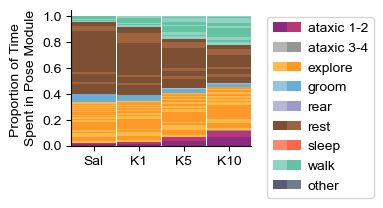

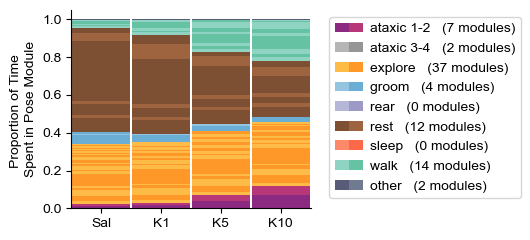

In [233]:
labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
analysis.make_remappings_from_BORIS(config,BORIS_to_pose_mat=BORIS_to_pose_mat)
module_usage = analysis.get_module_usage(config, labels_df)
plot.plot_module_usage(config, module_usage,figH=2,figW=4,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=["Sal","K1","K5","K10"])
if save:
    plt.savefig(save_path+"dose_pose_density_stacked.png",dpi=500)

plot.plot_module_usage(config, module_usage,figH=2.5,figW=5.5,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=["Sal","K1","K5","K10"],long_legend=True)
if save:
    plt.savefig(save_path+"dose_pose_density_stacked_LEGEND.png",dpi=500)

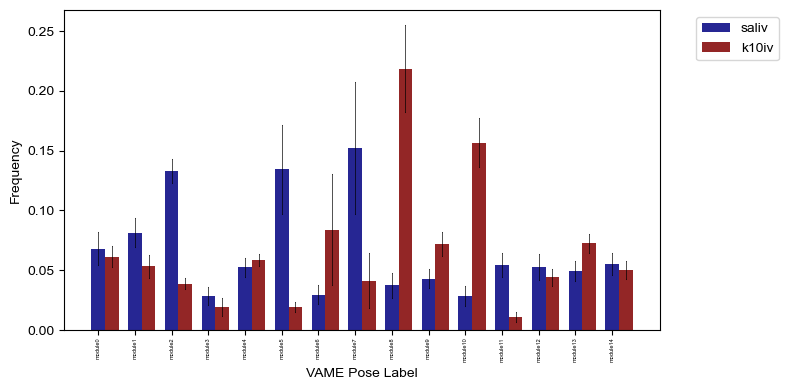

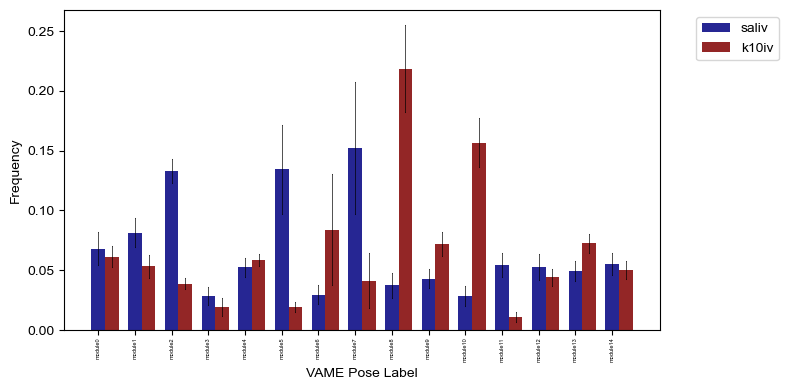

In [284]:
plot.plot_module_usage(config, module_usage,figH=4,figW=8,style="bar_error",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=["Sal","K1","K5","K10"])

Getting module usage
Getting module transitions
Getting module usage
Getting module transitions
Getting module usage
Getting module transitions


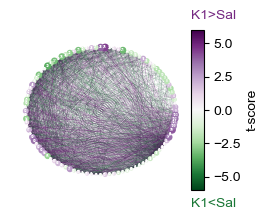

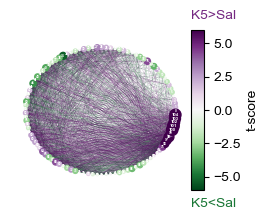

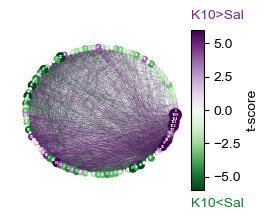

In [375]:


scaling=1
cmap="bwr"
include_labels=True

labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = ["saliv","k10iv"])

figW=2.5
figH=2
labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = ["saliv","k1iv"])
plot.network_plot(config, labels_df,cmap="PRGn_r",figW=figW,figH=figH,alt_labels={"saliv":"Sal","k1iv":"K1"})
if save:
    plt.savefig(save_path+"network_salk1.png",dpi=500,bbox_inches='tight')

labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = ["saliv","k5iv"])
plot.network_plot(config, labels_df,cmap="PRGn_r",figW=figW,figH=figH,alt_labels={"saliv":"Sal","k5iv":"K5"})
if save:
    plt.savefig(save_path+"network_salk5.png",dpi=500,bbox_inches='tight')
    
labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = ["saliv","k10iv"])
plot.network_plot(config, labels_df,cmap="PRGn_r",figW=figW,figH=figH,alt_labels={"saliv":"Sal","k10iv":"K10"})
if save:
    plt.savefig(save_path+"network_salk10.png",dpi=500,bbox_inches='tight')

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_cocDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalketDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5ivDLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25DLC_resnet101_all_pose_vidsJul17shuffle1_500000.csv']
done with ['BINARY_2023-07-08_15

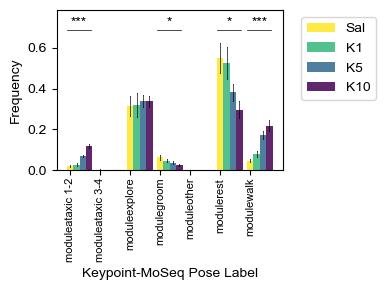

In [230]:
alt_labels={'saliv': "Sal", 'k1iv': "K1", 'k5iv': "K5", 'k10iv': "K10"}

labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
analysis.make_remappings_from_BORIS(config,BORIS_to_pose_mat=BORIS_to_pose_mat)
labels_df = analysis.make_remappings_from_BORIS(config,labels_df = labels_df, BORIS_to_pose_mat=BORIS_to_pose_mat, force_no_numeric=True)
module_usage = analysis.get_module_usage(config, labels_df)
plot.plot_module_usage(config, module_usage,figH=3,figW=4,style="bar_error",cmap="viridis_r",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,
                       alt_labels=alt_labels,plot_stats=True)
if save:
    plt.savefig(save_path+"dose_pose_usage_bar.png",dpi=500)

In [326]:
method_acc = {}
method_cmat = {}

labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
module_usage = analysis.get_module_usage(config, labels_df)
module_usage = module_usage.scale()
module_transitions = analysis.get_module_transitions(config, labels_df)
module_transitions = module_transitions.scale()

for method in ["LogisticRegression","LDA","MLP","NaiveBayes","KNN","RandomForest"]:
    print(method)
    method_acc[method+" usage"], method_cmat[method+" usage"] = analysis.loocv(module_usage,method=method)
    clf = analysis.classify(module_usage,method=method)
    method_acc[method+" tx"], method_cmat[method+" tx"] = analysis.loocv(module_transitions,method=method)
    clf = analysis.classify(module_transitions,method=method)

/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/opt/anaconda3/envs/mariposa/lib/python3.8/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


KeyboardInterrupt: 

In [ ]:
xticks=[]
xticklabels=[]
jet = plt.get_cmap("jet")
colors=[jet([i]) for i in np.arange(0,1,0.15)]
plt.figure(figsize=(4,4),dpi=500)
for k,key in enumerate(list(method_acc.keys())):
    if " usage" in key:
        alpha=0.5
        plt.bar(k,method_acc[key],color=colors[int(np.trunc(k/2))])
    else:
        plt.bar(k,method_acc[key],edgecolor=colors[int(np.trunc(k/2))],color="none",hatch="//////")
    xticks.append(k)
    xticklabels.append(key)
plt.xticks(xticks,labels=xticklabels,rotation=90)
plt.ylabel("Accuracy")
plt.ylim([0,1])
plt.tight_layout()
if save:
    plt.savefig(save_path+"clf.png")

In [ ]:
xticks=[]
xticklabels=[]
fig, ax = plt.subplots(2,6,figsize=(9,4),dpi=500)
for k,key in enumerate(list(method_acc.keys())):
    ax[int(k%2),int(k/2)].imshow(method_cmat[key],cmap="Greens")
    for i in range(method_cmat[key].shape[0]):
        for j in range(method_cmat[key].shape[1]):
            text = ax[int(k%2),int(k/2)].text(j, i, f"{int(method_cmat[key][i, j])}",
                           ha="center", va="center", color="white")
    ax[int(k%2),int(k/2)].set_xticks([i[1] for i in list(module_usage.group_dict.items())],
                                     [0,1,5,10],rotation=90)
    ax[int(k%2),int(k/2)].set_yticks([i[1] for i in list(module_usage.group_dict.items())],
                                     [0,1,5,10])
    ax[int(k%2),int(k/2)].set_title("\n".join(key.split(" ")))
    ax[int(k%2),int(k/2)].set_xlabel("True Dose")
    ax[int(k%2),int(k/2)].set_ylabel("Predicted Dose")
plt.tight_layout()
if save:
    plt.savefig(save_path+"confmat.png")

In [20]:
module_usage = analysis.get_module_usage(config, labels_df)
module_transitions = analysis.get_module_transitions(config, labels_df)

Labels LinearRegression, alpha 1 RMSE: 2.55
Labels Lasso, alpha 1 RMSE: 2.33
Labels Lasso, alpha 0.5 RMSE: 2.04
Labels Lasso, alpha 0.1 RMSE: 1.82
Labels Ridge, alpha 1 RMSE: 1.95
Labels Ridge, alpha 0.5 RMSE: 2.11
Labels Ridge, alpha 0.1 RMSE: 2.40
Transitions LinearRegression, alpha 1 RMSE: 2.27
Transitions Lasso, alpha 1 RMSE: 3.06
Transitions Lasso, alpha 0.5 RMSE: 2.34
Transitions Lasso, alpha 0.1 RMSE: 2.08
Transitions Ridge, alpha 1 RMSE: 2.10
Transitions Ridge, alpha 0.5 RMSE: 2.17
Transitions Ridge, alpha 0.1 RMSE: 2.25


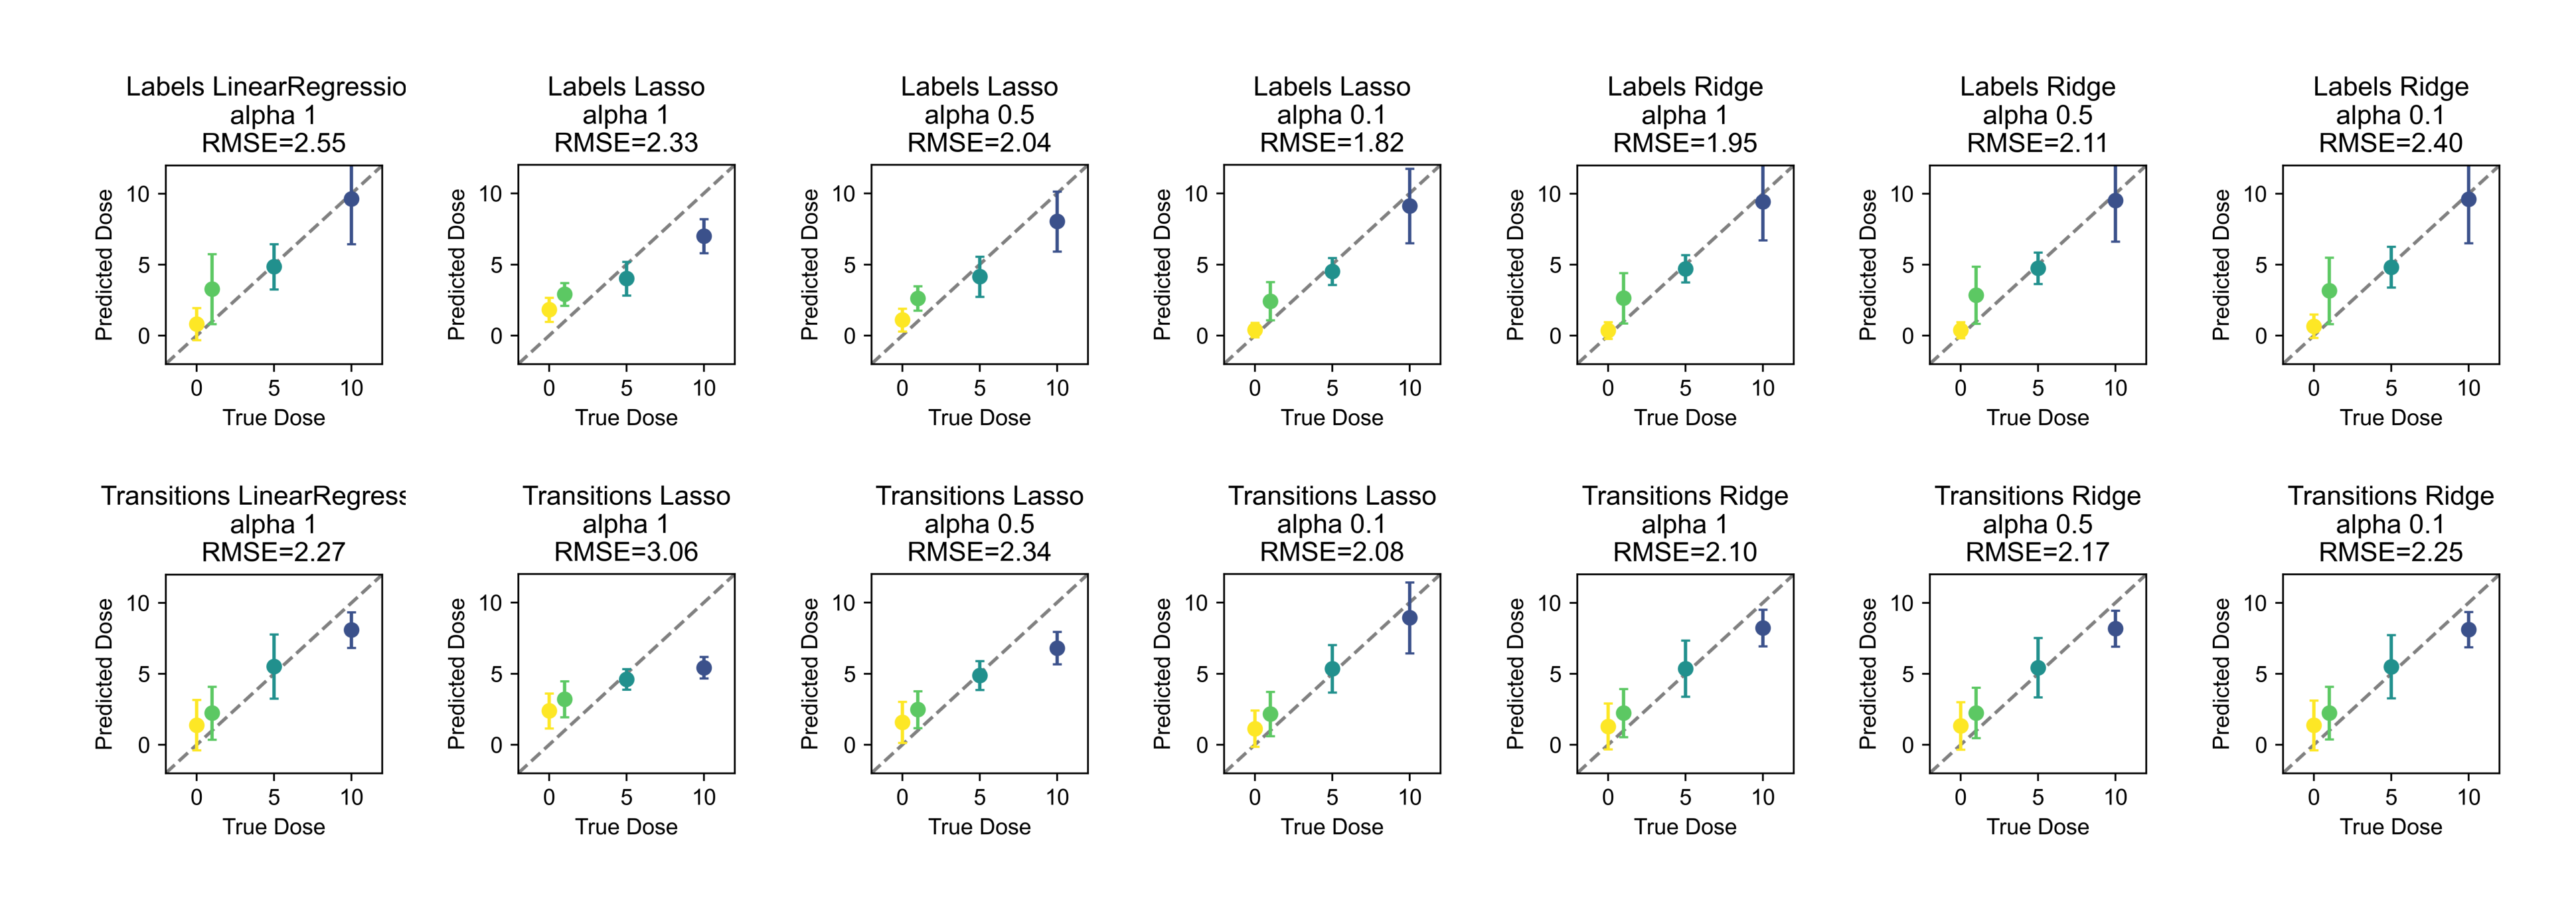

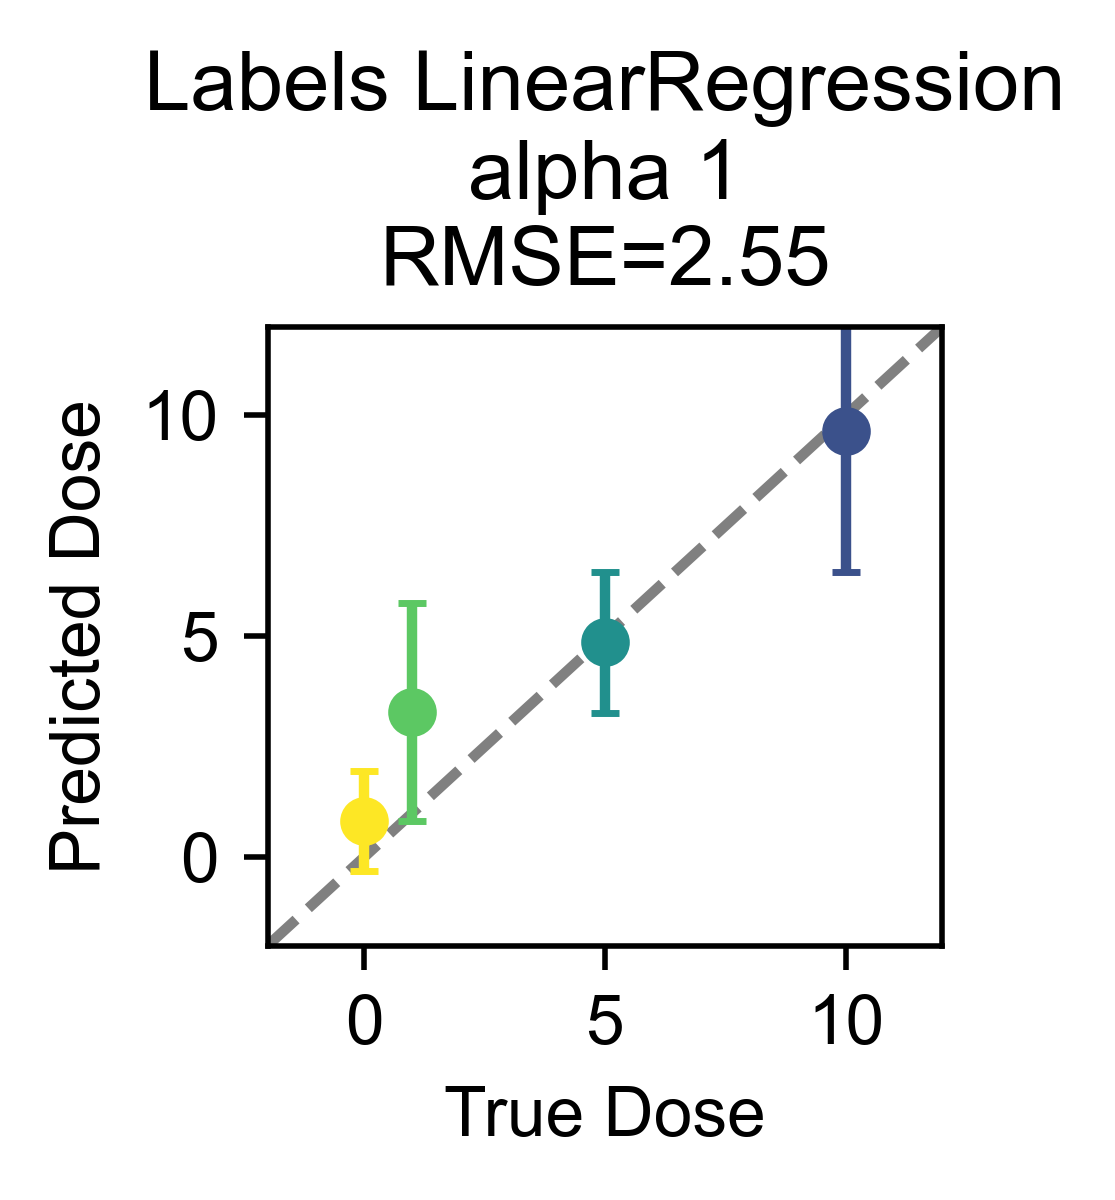

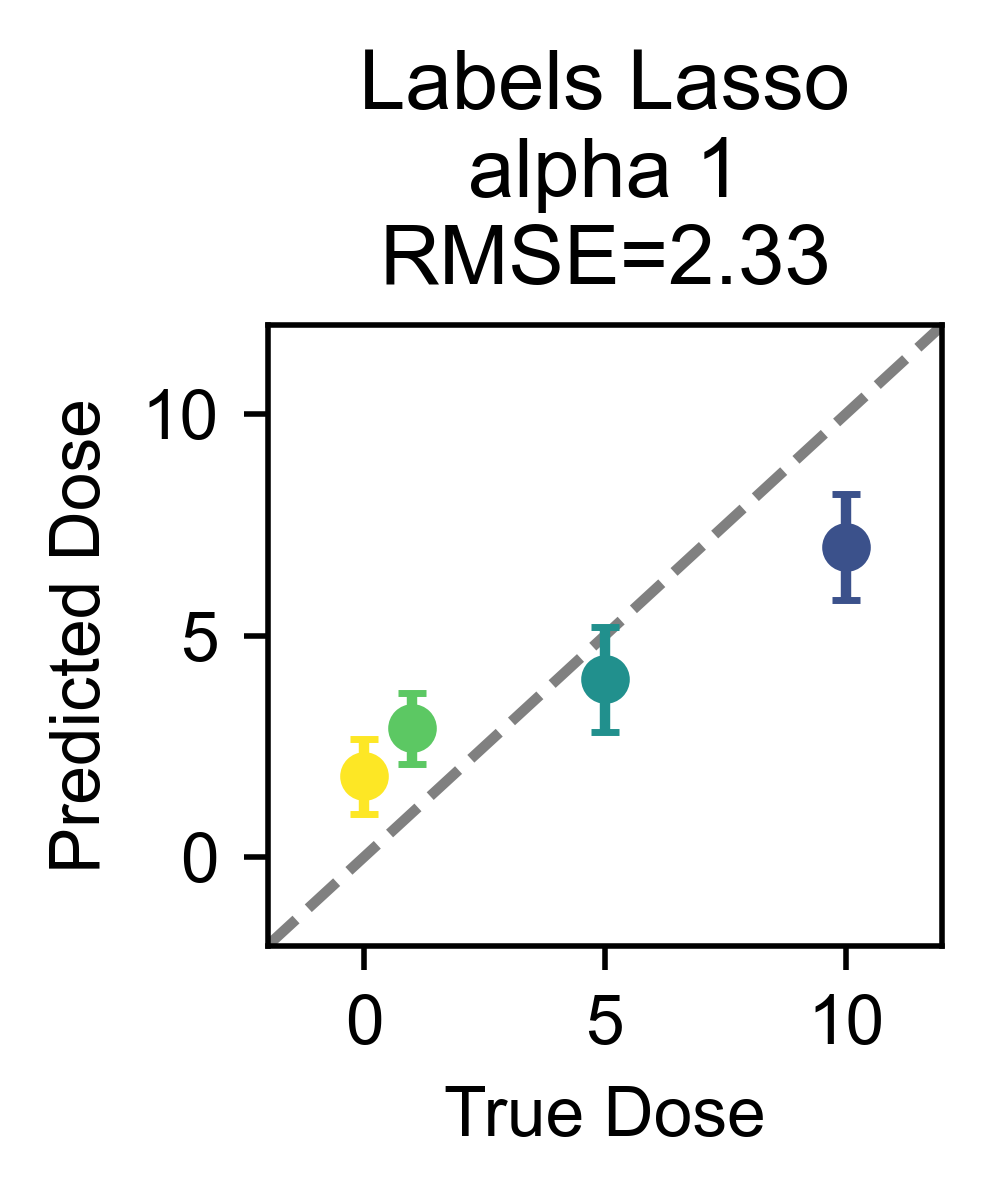

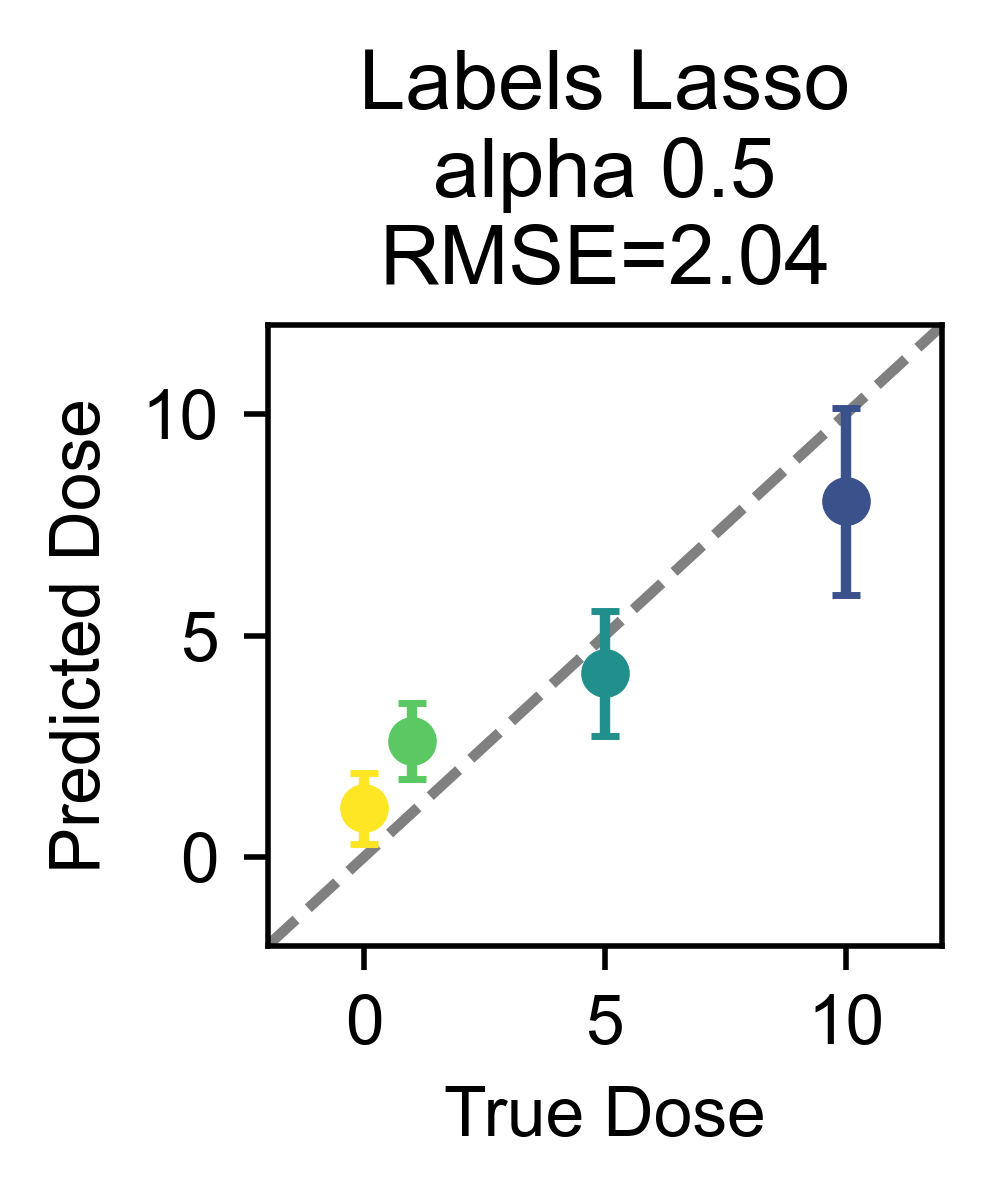

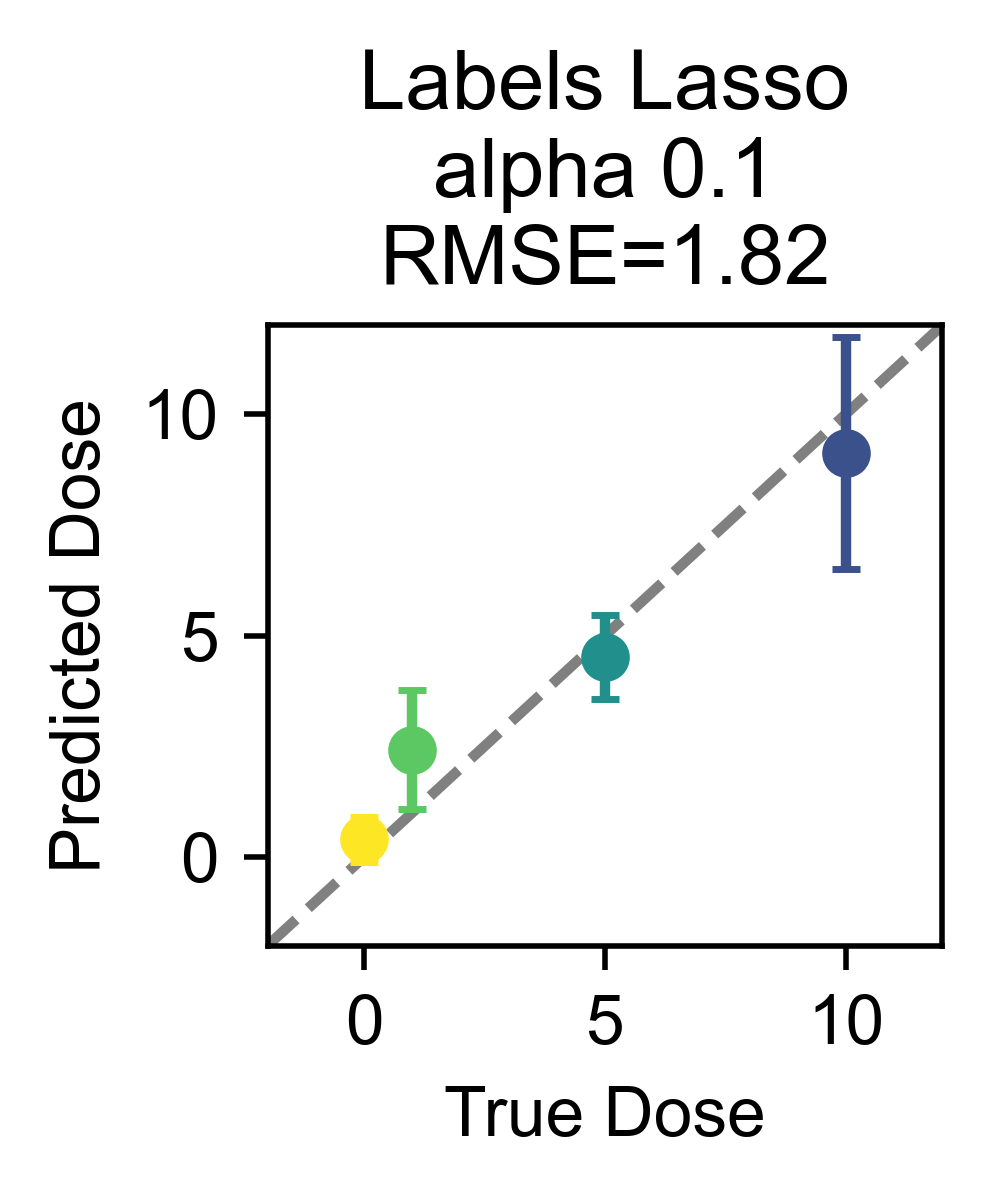

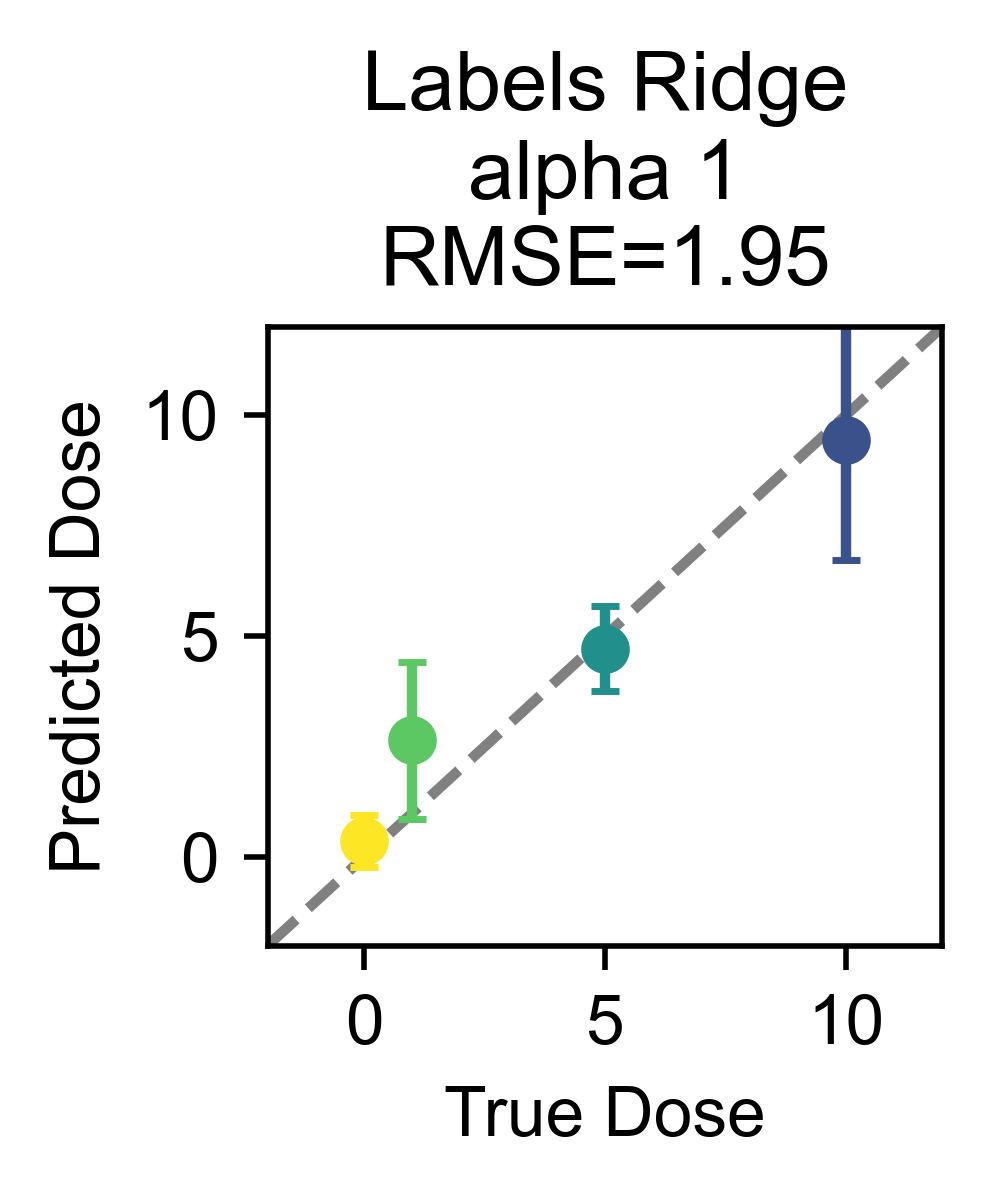

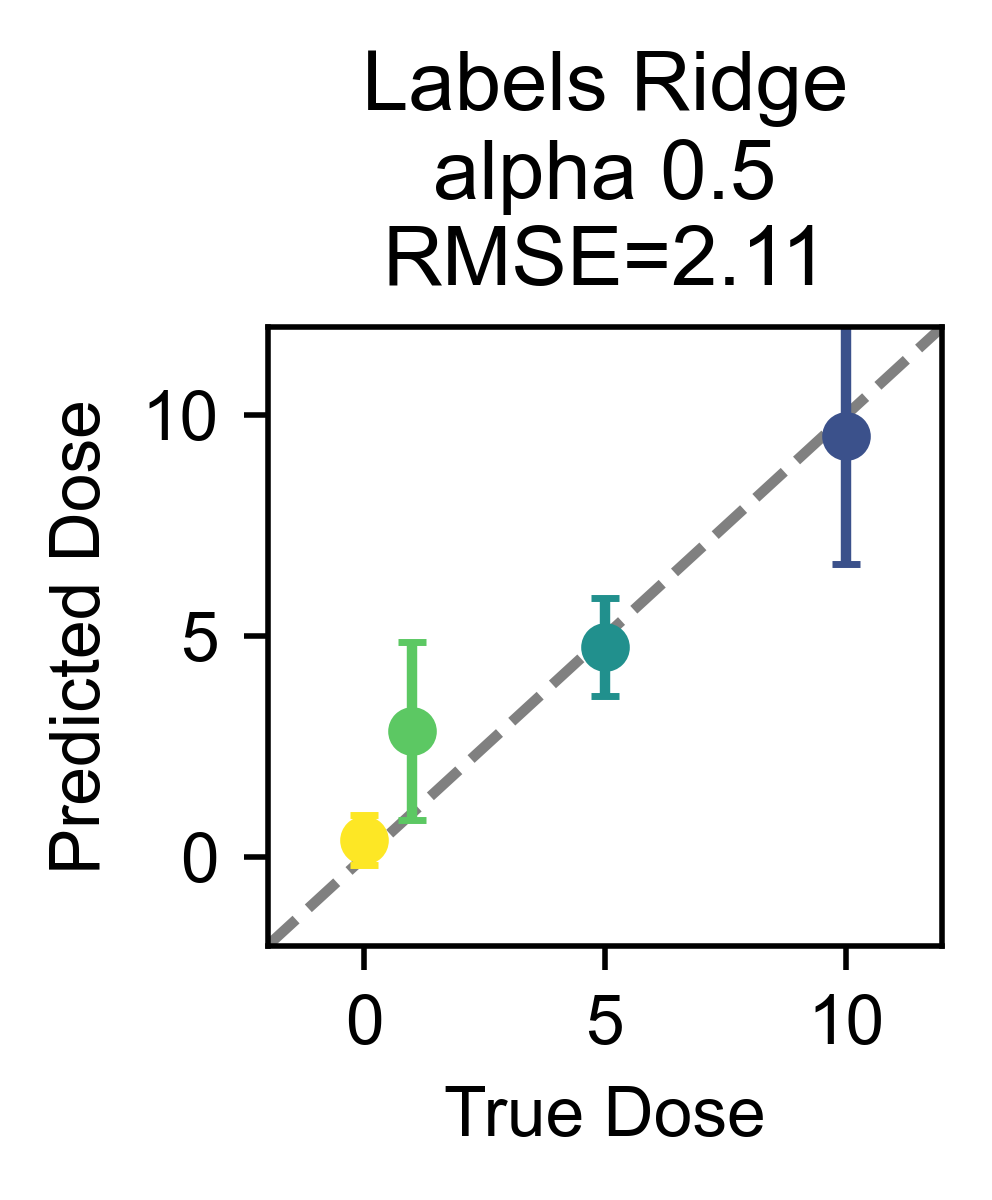

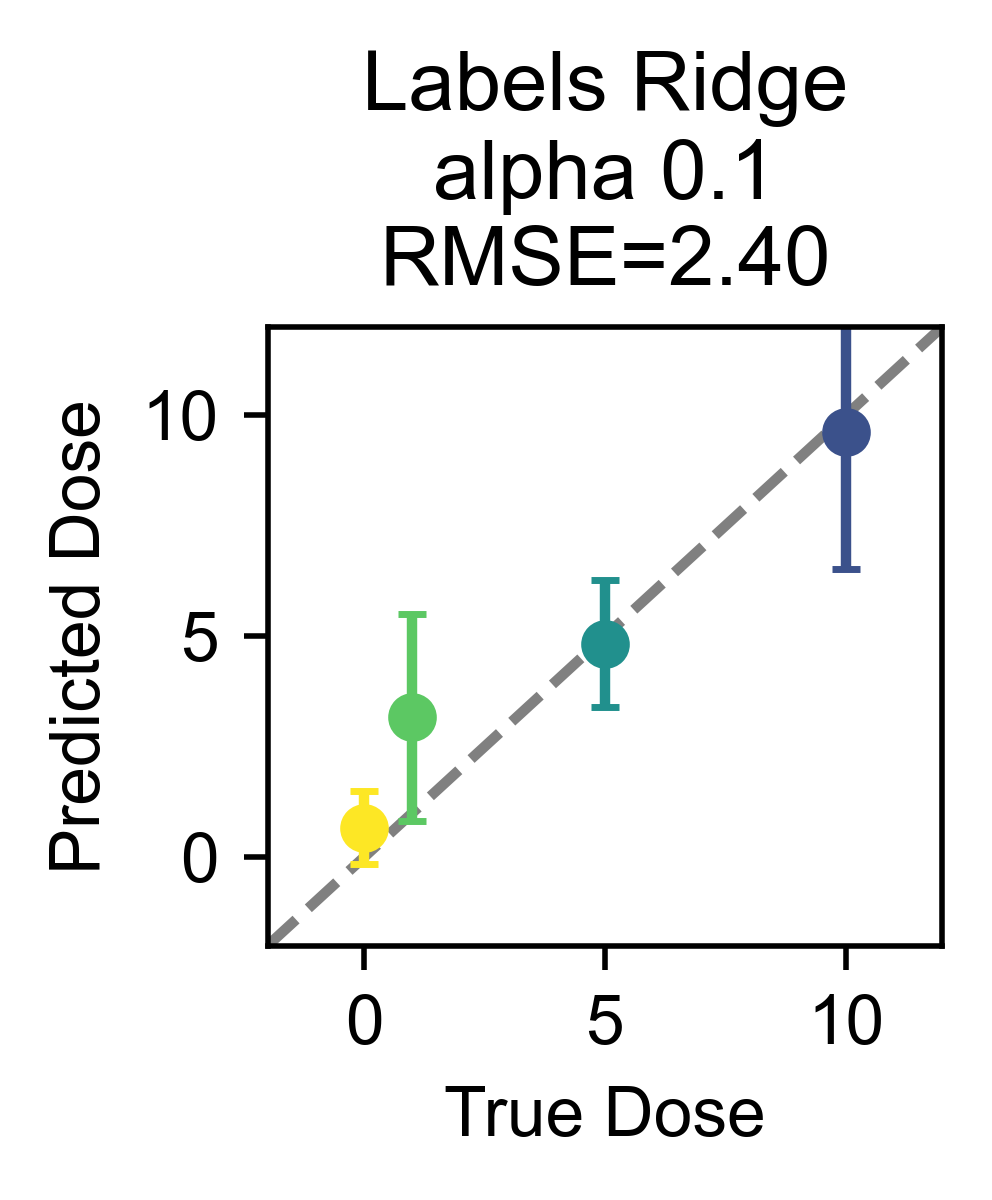

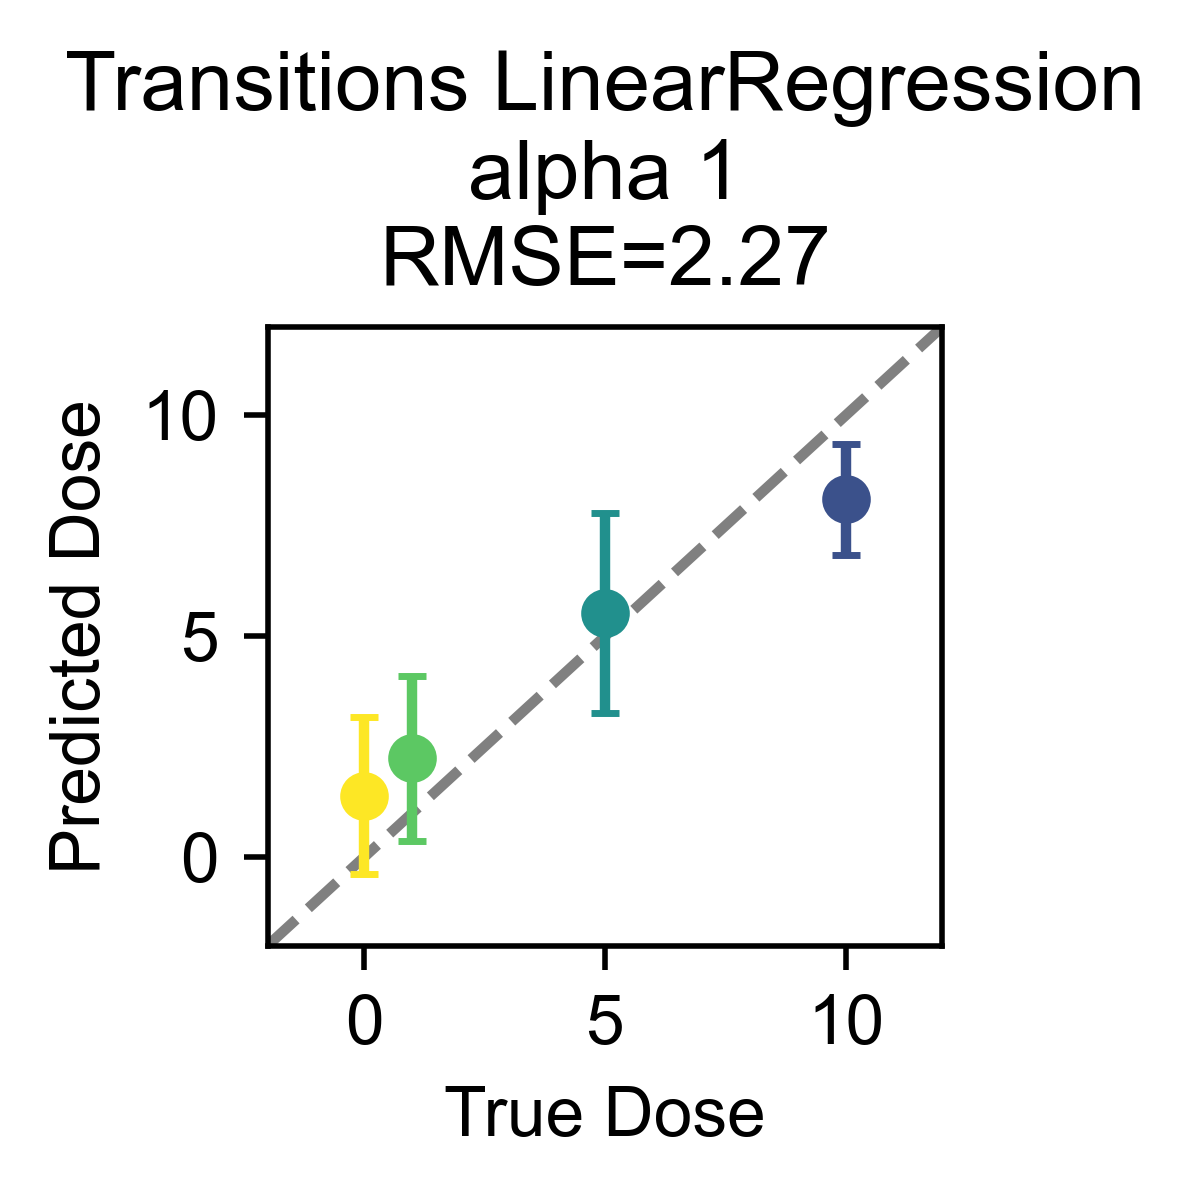

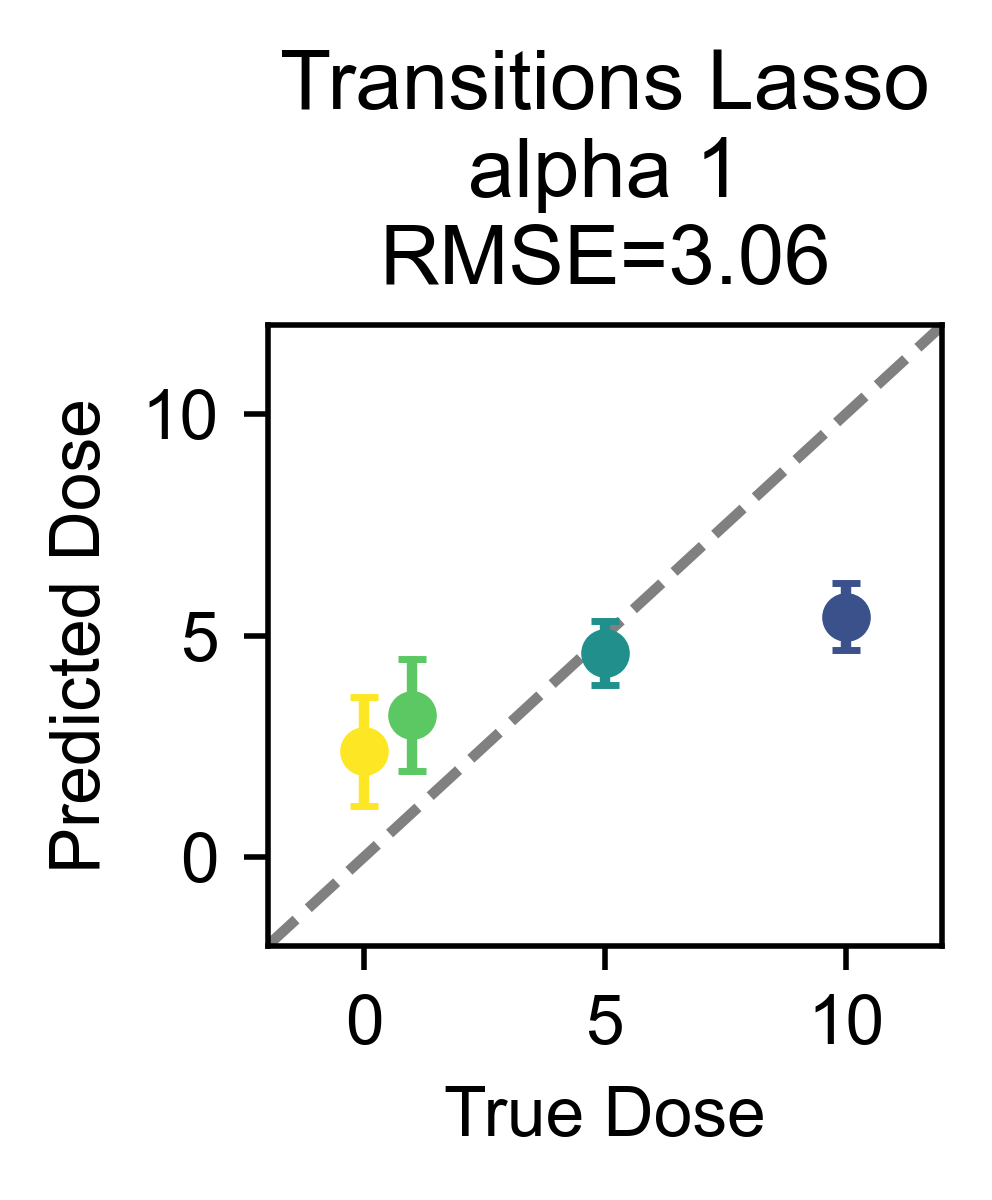

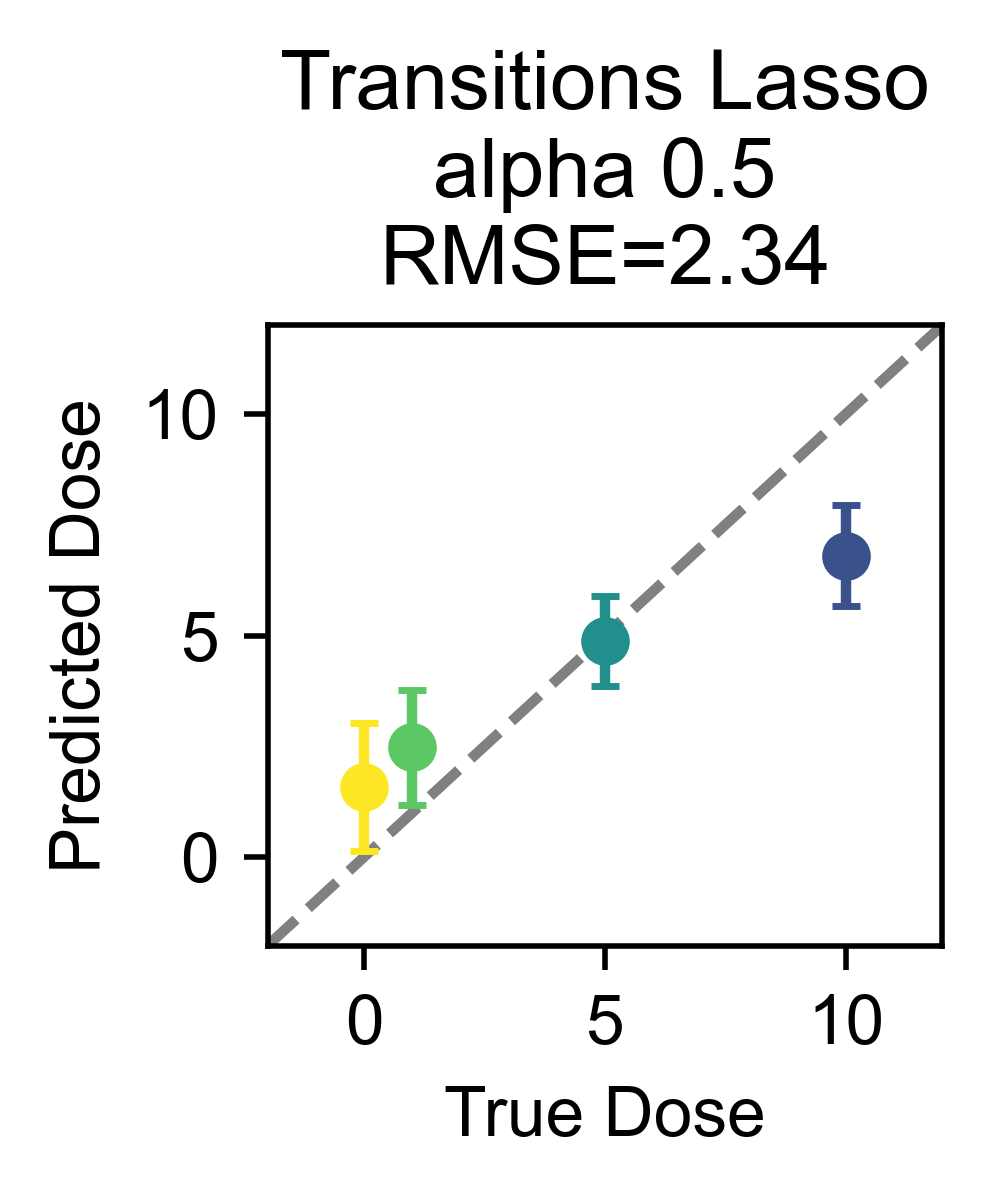

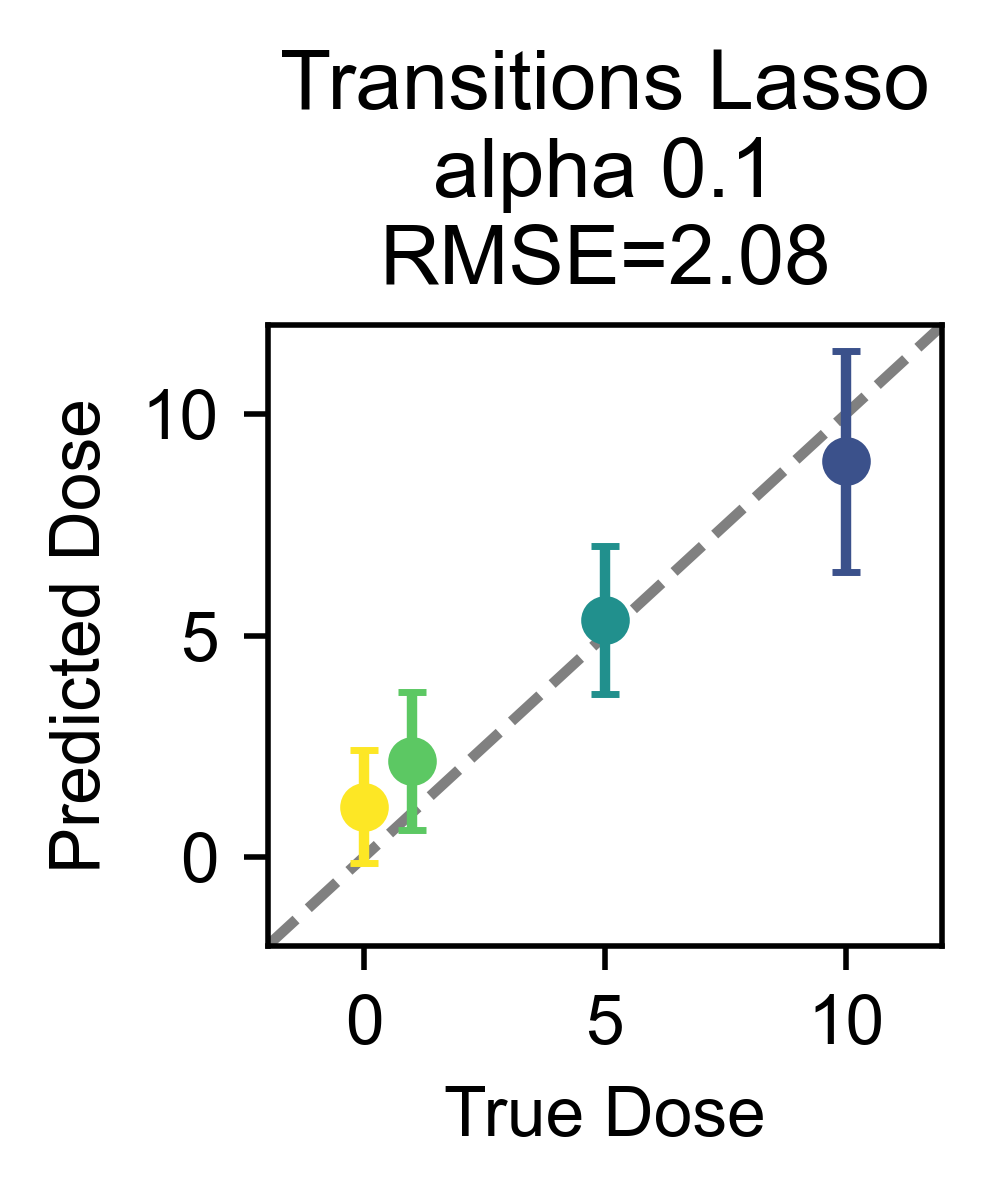

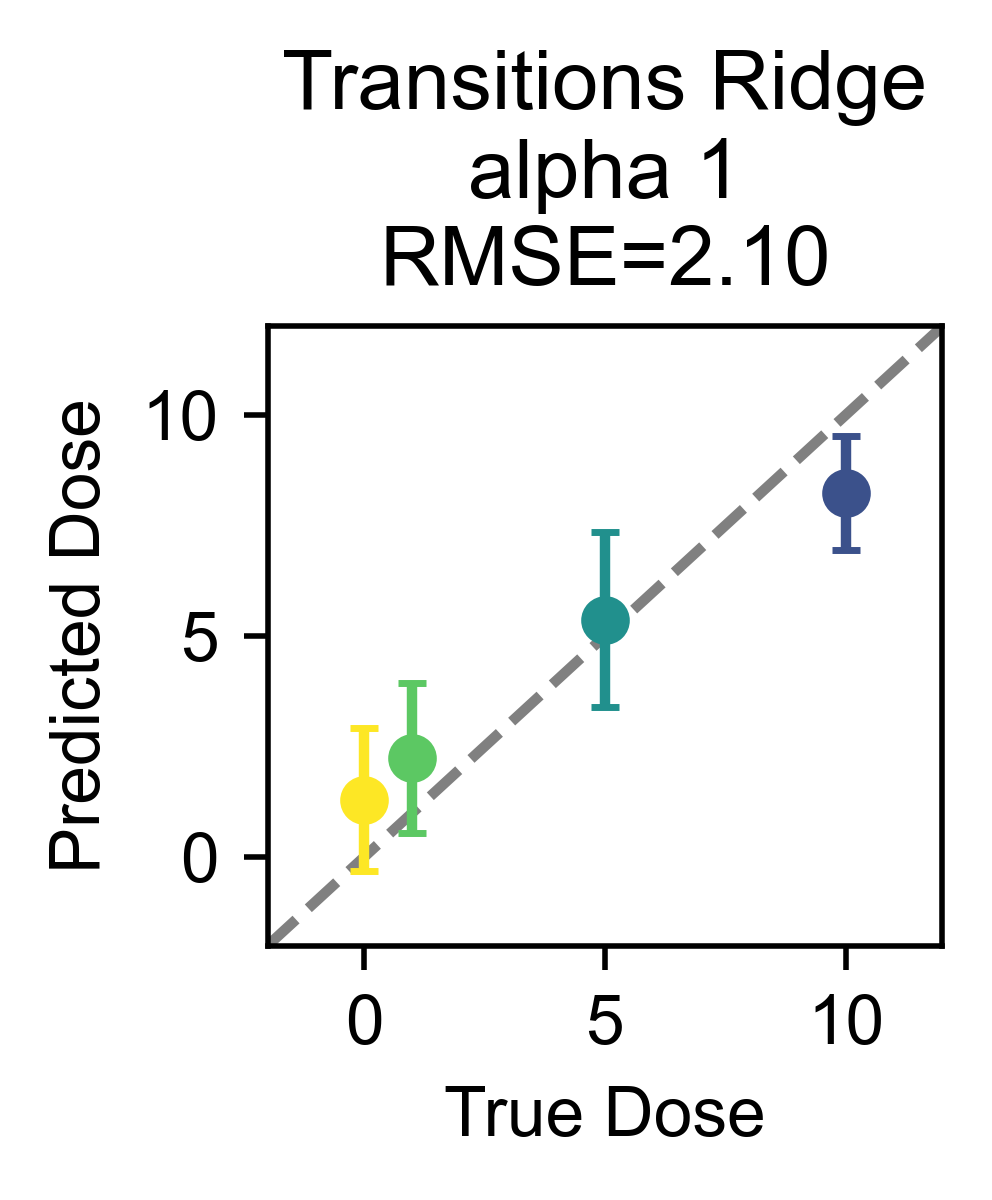

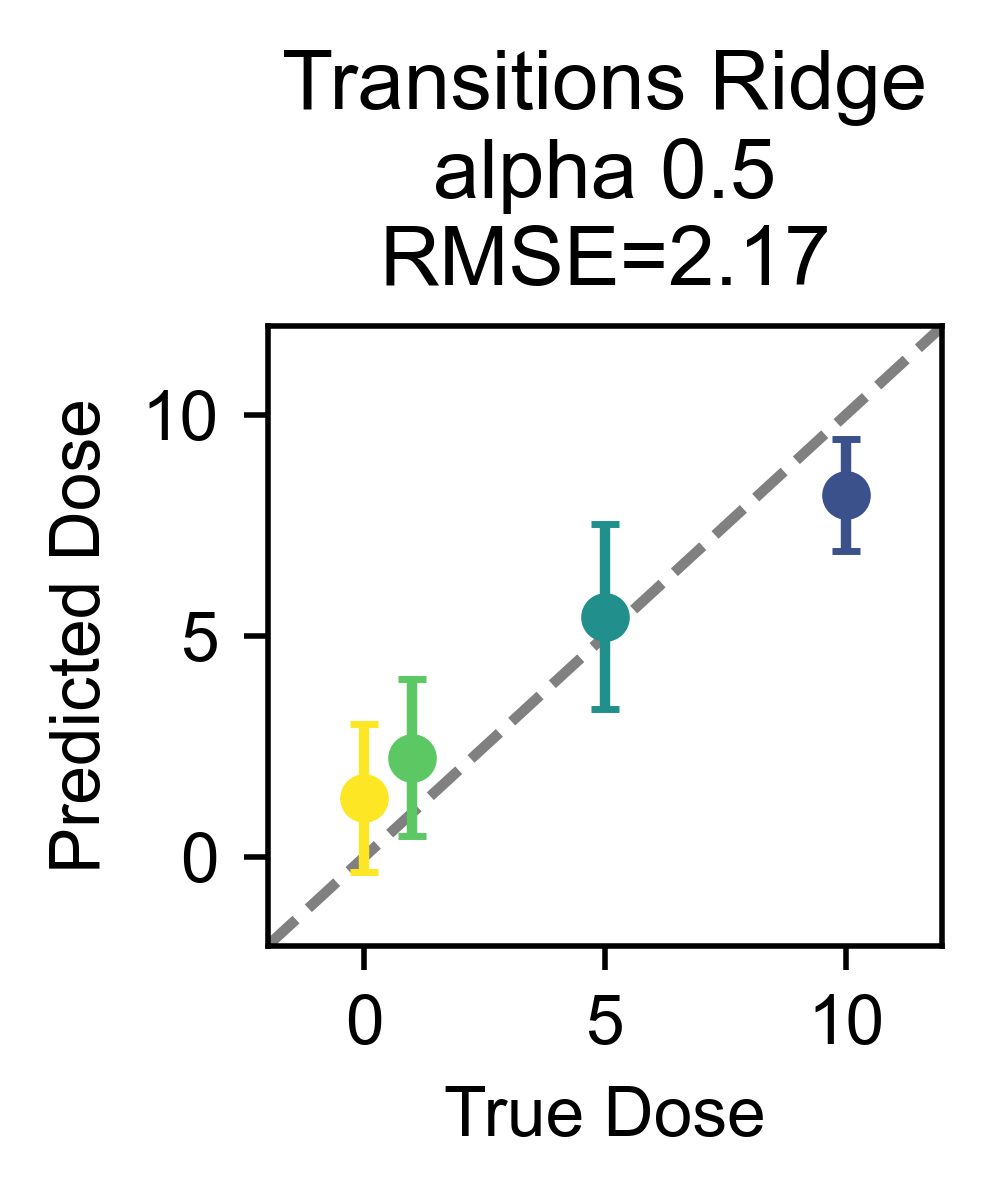

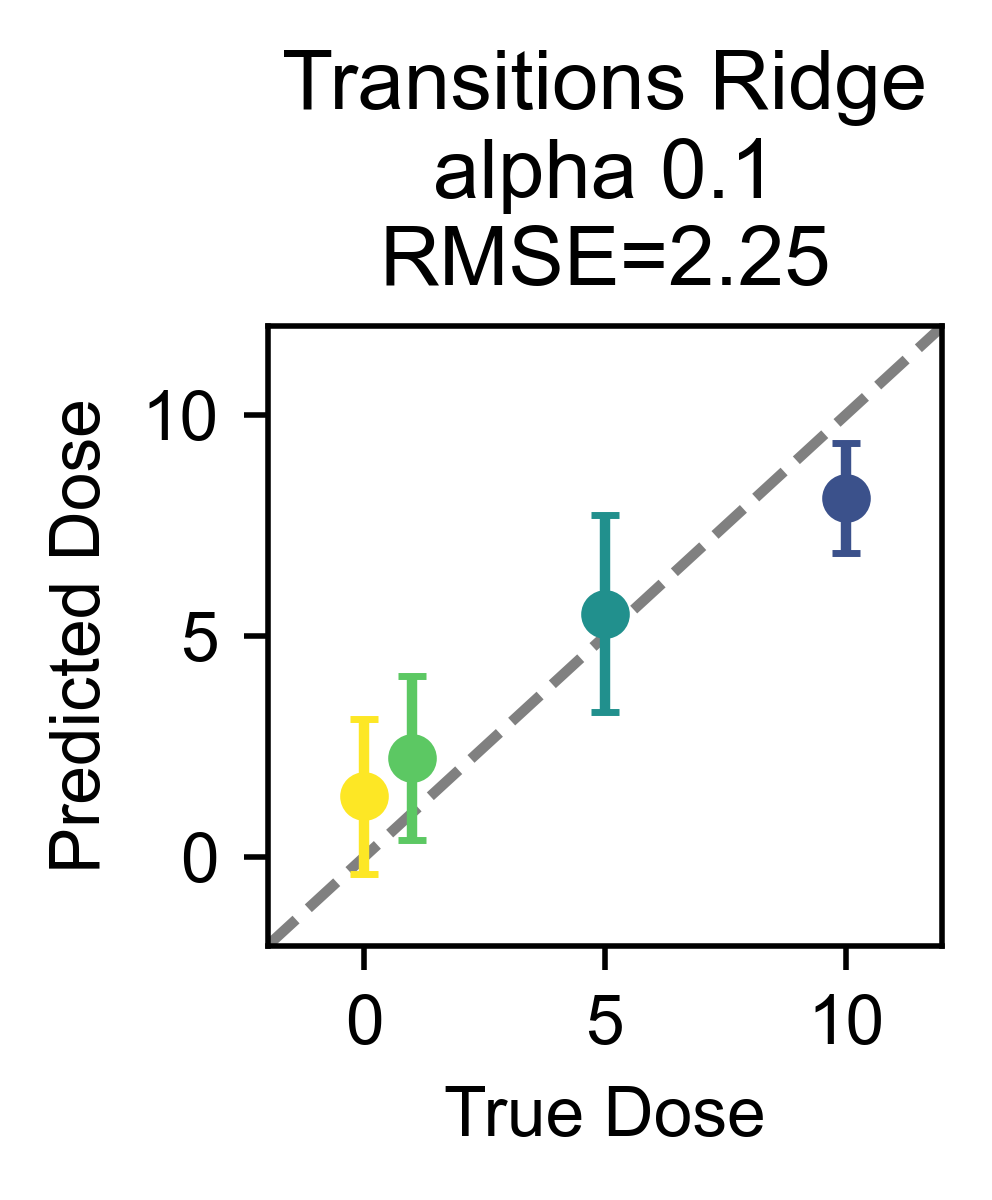

In [21]:
module_usage.label_counts
dose_dict={'saliv': 0, 'k1iv': 1, 'k5iv': 5, 'k10iv': 10}

module_usage_scaled = module_usage.scale()
module_transitions_scaled = module_transitions.scale()

cmap=jet = plt.get_cmap("viridis_r")

ims=[]
fig_main, main_axes = plt.subplots(2,7, figsize=(6,2),dpi=800)
plt.subplots_adjust(wspace=0, hspace=0)

for m,method in enumerate([["LinearRegression",1],["Lasso",1],["Lasso",0.5],["Lasso",0.1],["Ridge",1],["Ridge",0.5],["Ridge",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(module_usage_scaled,dose_dict,method=method[0],alpha=method[1])
    y_hat = reg.predict(module_usage_scaled.label_counts)
    loocv_preds, sq_err = analysis.loocv_regression(module_usage_scaled,dose_dict,method=method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Labels {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Labels {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()
    im = plot.fig_to_array(fig)
    main_axes[0,m].imshow(im)
    main_axes[0,m].axis('off')
    main_axes[0,m].set_xticklabels([])
    main_axes[0,m].set_yticklabels([])


for m,method in enumerate([["LinearRegression",1],["Lasso",1],["Lasso",0.5],["Lasso",0.1],["Ridge",1],["Ridge",0.5],["Ridge",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(module_transitions_scaled,dose_dict,method = method[0],alpha=method[1])
    y_hat = reg.predict(module_transitions_scaled.transition_counts)
    loocv_preds, sq_err = analysis.loocv_regression(module_transitions_scaled,dose_dict,method = method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Transitions {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Transitions {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()
    im = plot.fig_to_array(fig)
    main_axes[1,m].imshow(im)
    main_axes[1,m].axis('off')
    main_axes[1,m].set_xticklabels([])
    main_axes[1,m].set_yticklabels([])

if save:
    fig_main.savefig(save_path+"regr.png",dpi=800)

Ellipse only drawn for embeddings_object of class LDA, not <class 'sklearn.decomposition._pca.PCA'>
Ellipse only drawn for embeddings_object of class LDA, not <class 'sklearn.decomposition._pca.PCA'>


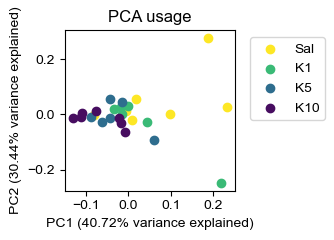

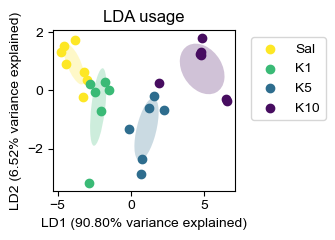

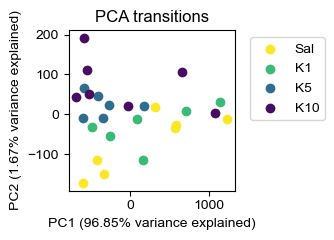

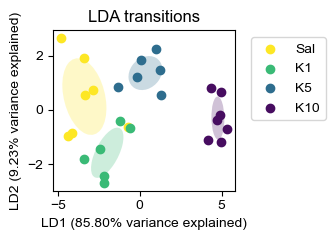

In [303]:
labels_df = analysis.get_module_labels(config, 0, 1200, subgroups = "all")
module_usage = analysis.get_module_usage(config, labels_df)

alt_legend={"saliv":"Sal","k1iv":"K1","k5iv":"K5","k10iv":"K10"}

emb = analysis.embed(module_usage,method="PCA",n_components=2)
plot.plot_embeddings(module_usage, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="PCA usage",legend=True,alt_legend=alt_legend)
    
emb = analysis.embed(module_usage,method="LDA",n_components=2)
fig = plot.plot_embeddings(module_usage, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="LDA usage",legend=True,draw_ellipse=True,alt_legend=alt_legend)
if save:
    plt.savefig(save_path+"lda_usage.png",dpi=500)
    
emb = analysis.embed(module_transitions,method="PCA",n_components=2)
plot.plot_embeddings(module_transitions, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="PCA transitions",legend=True,alt_legend=alt_legend)
    
emb = analysis.embed(module_transitions,method="LDA",n_components=2)
plot.plot_embeddings(module_transitions, emb, figW=3.5, figH=2.5, cmap="viridis_r", title="LDA transitions",legend=True,draw_ellipse=True,alt_legend=alt_legend)
if save:
    plt.savefig(save_path+"lda_transitions.png",dpi=500)

In [22]:
# group="k10iv"
# labels_df = analysis.get_module_labels(config,0,60*50,subgroups=[group])
# fig = plot.SandPlotClusterFrequency_OverTime(config, labels_df[group],0, 30, 100)

In [23]:
# modules = sorted(np.unique([int(i.split("module")[1].split("_")[0]) for i in list(df.columns) if "module" in i]))
# start_times = [int(col.split("_t")[1].split("-")[0]) for col in list(df.columns) if f"module{modules[0]}_" in col]
# subjs = list(df.index)
# data = []
# for subj in subjs:
#     new_df = pd.DataFrame(columns=start_times,index=modules)
#     for module in modules:
#         new_df.loc[module] = np.array(df.filter(like=f"module{module}_", axis=1).loc[subj])
#     data.append(new_df)

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_coc']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalket']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5iv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25']
done with ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25']
done with ['BINARY_bf01_k5.csv', '2023-06-20_16-46-29_bf01_k5']
done with ['BINARY_2023-12-27_14-40-30_bf15_d16.csv', '2023-12-27_14-40-30_bf15_d16']
VAME modules map onto scored behaviors with 'loss' of 0.4585485775567791


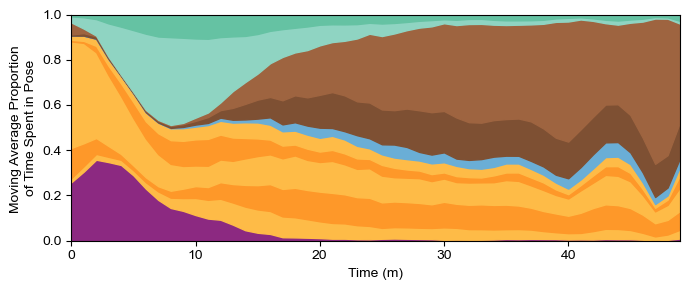

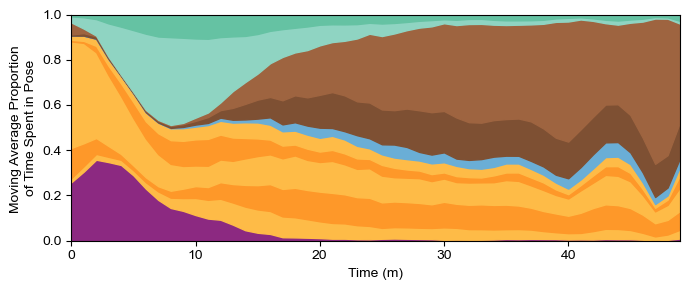

In [217]:
group="k10iv"
labels_df = analysis.get_module_labels(config,0,60*50,subgroups=[group])
module_usage = analysis.get_module_usage(config, labels_df,binsize=60)
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
analysis.make_remappings_from_BORIS(config,BORIS_to_pose_mat=BORIS_to_pose_mat)

plot.module_usage_sandplot(config, module_usage, BORIS_to_pose_mat = BORIS_to_pose_mat_normalized, convolve=True, long_legend=True)

Labels LinearRegression, alpha 0.1 RMSE: 2.55


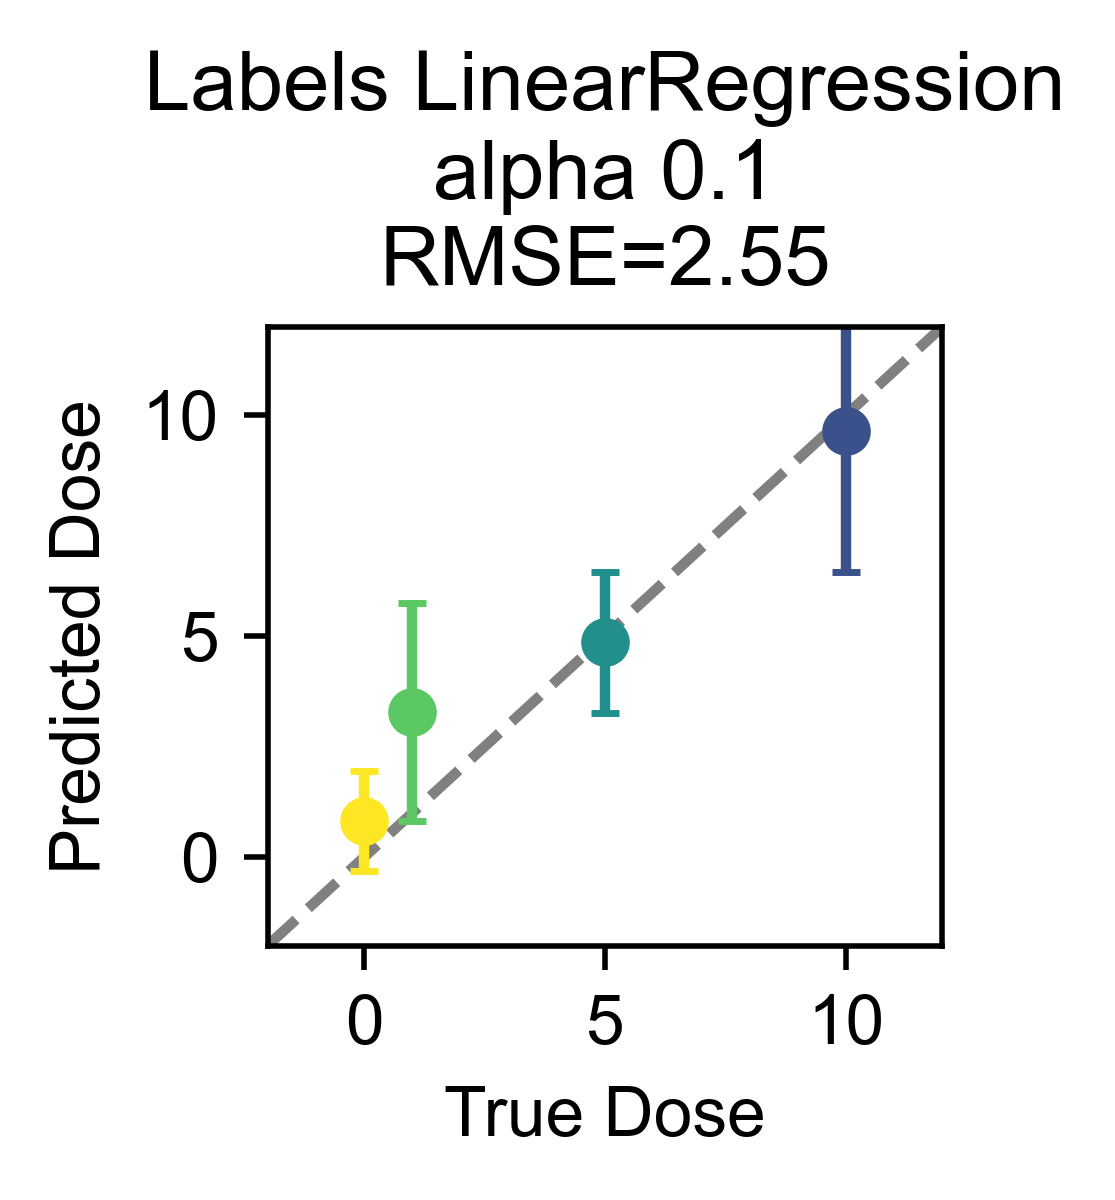

In [218]:
labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)

cmap = plt.get_cmap("viridis_r")
for m,method in enumerate([["LinearRegression",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    y_hat = reg.predict(all_module_usage.label_counts)
    loocv_preds, sq_err = analysis.loocv_regression(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Labels {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Labels {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()

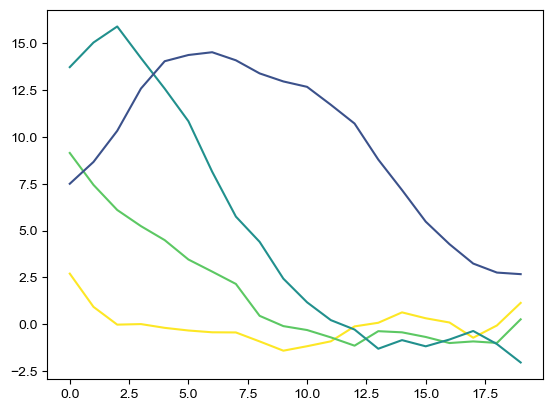

In [219]:
cmap = plt.get_cmap("viridis_r")
colors = [cmap([i]) for i in np.arange(0,1,1/4)]


labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)
all_modules = [int(i.split("module")[1]) for i in all_module_usage.to_df().columns if "module" in i]

for g,group in enumerate(["saliv","k1iv","k5iv","k10iv"]):
    labels_df = analysis.get_module_labels(config,0,60*20,subgroups=[group])
    module_usage = analysis.get_module_usage(config, labels_df,binsize=60)
    usage_density = module_usage.usage_density(convolve=True,window=5)
    dropped = [i for i in all_modules if i not in usage_density[0].index]
    for d in usage_density:
        for drop in dropped:
            d.loc[drop] = np.zeros(usage_density[0].shape[1])
    x = []
    for item in usage_density:
        x.append(reg.predict(np.array(item,dtype=float).T))
    
    plt.plot(np.mean(x,axis=0),color=colors[g])

Labels Lasso, alpha 0.1 RMSE: 1.82


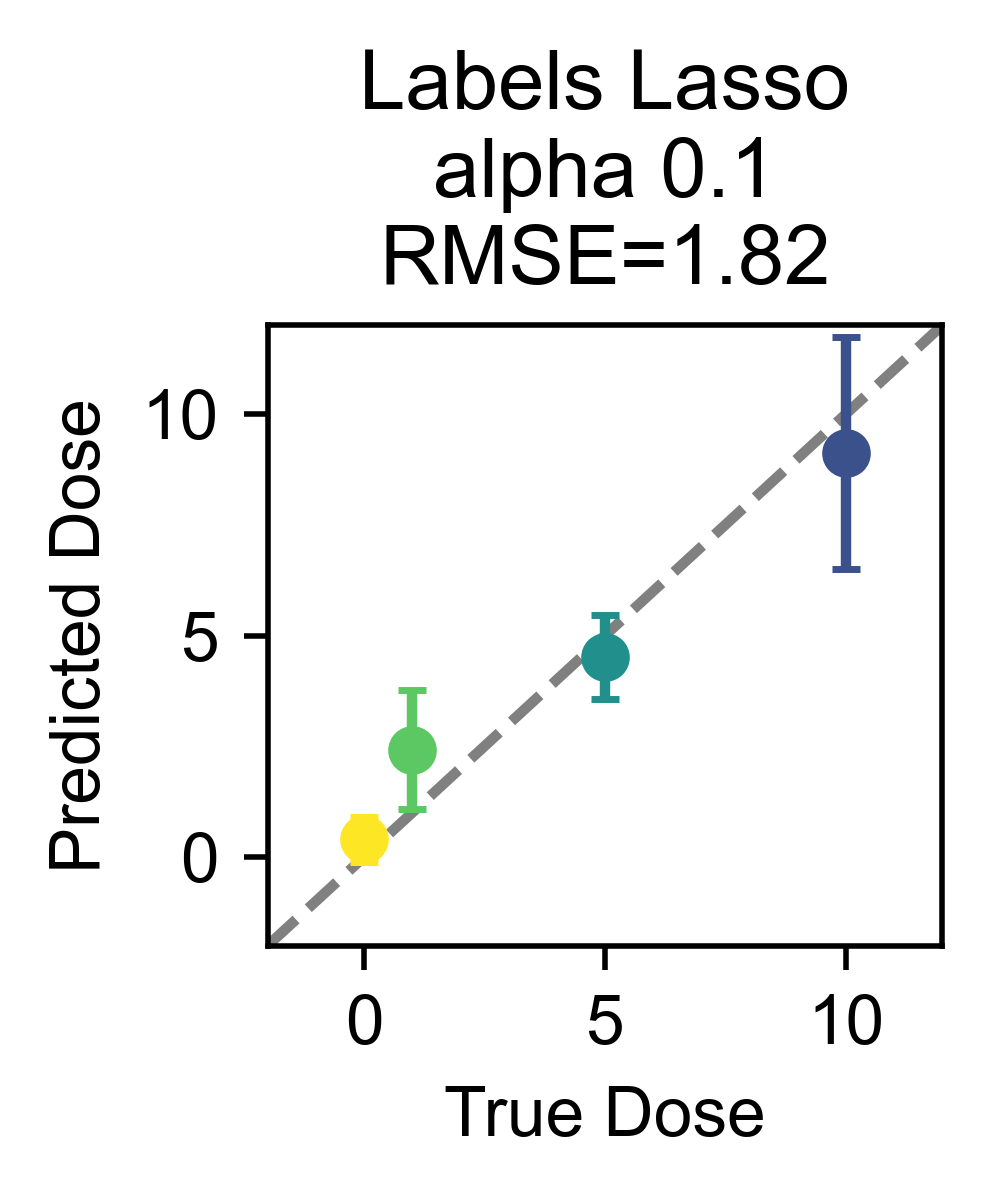

In [220]:
labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)
all_module_usage = all_module_usage.scale()

cmap = plt.get_cmap("viridis_r")
for m,method in enumerate([["Lasso",0.1]]):
    fig = plt.figure(figsize=(2.2,2.5),dpi=500)
    plt.xlabel("True Dose")
    plt.ylabel("Predicted Dose")
    plt.ylim([-2,12])
    plt.xlim([-2,12])
    plt.axline([0,0],[1,1],linestyle="dashed",color="gray")
    reg, dose_labels = analysis.regress(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    y_hat = reg.predict(all_module_usage.label_counts)
    loocv_preds, sq_err = analysis.loocv_regression(all_module_usage,dose_dict,method=method[0],alpha=method[1])
    dose_cats = np.unique(dose_labels)
    colors = [cmap([i]) for i in np.arange(0,1,1/len(dose_cats))]
    for d, do in enumerate(dose_cats):
        y_d_hat = loocv_preds[dose_labels==do]
        plt.errorbar(do,np.mean(y_d_hat),yerr=np.std(y_d_hat),marker="o",capsize=2,color=colors[d])
    rmse=np.sqrt(np.mean(sq_err))
    plt.title(f'Labels {method[0]}\nalpha {method[1]}\nRMSE={rmse:.2f}')
    print(f'Labels {method[0]}, alpha {method[1]} RMSE: {rmse:.2f}')
    plt.tight_layout()

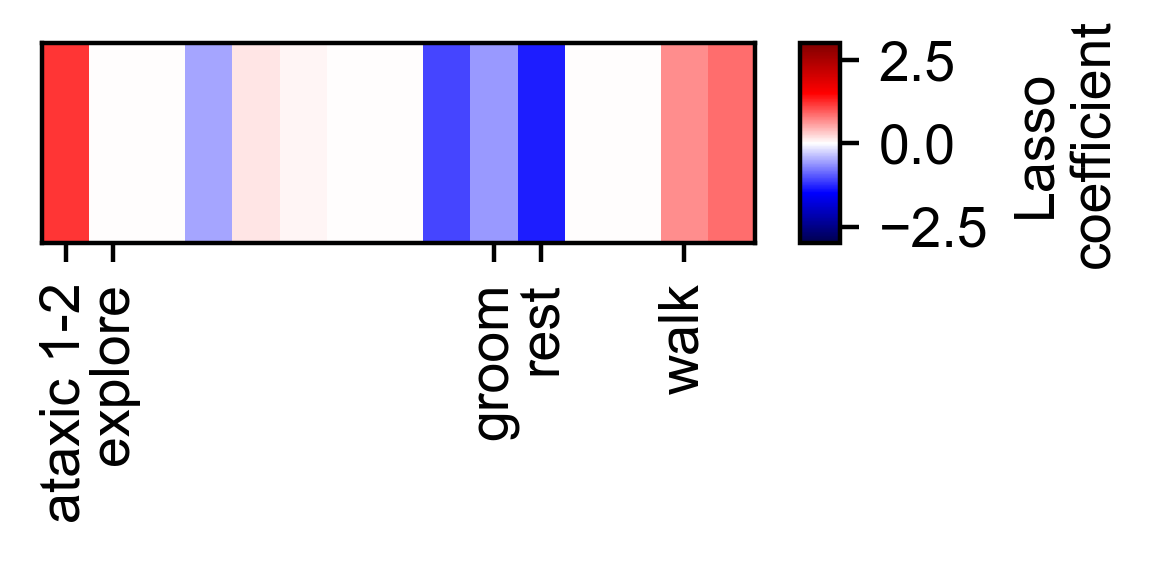

In [221]:
beh = list(BORIS_to_pose_mat.index)+["other"]
modules_rearr=[]
module_beh=[]
for b in beh:
    for r,rm in enumerate(config["remappings"]):
        if rm[1]==b:
            if r<len(reg.coef_):
                modules_rearr.append(r)
                module_beh.append(rm[1])

modules_rearr=np.array(modules_rearr,dtype=int).T
coeff_rearr = reg.coef_[modules_rearr]

# xticks = np.arange(coeff_rearr.shape[1])
# xticklabels = [f'{module_beh[i]} ({modules_rearr[0][i]})' for i in xticks]

xticks = []
xticklabels = []
for index, entry in enumerate(module_beh):
    if entry not in xticklabels:
        xticks.append(index)
        xticklabels.append(entry)
        
plt.figure(figsize=(3,1.5),dpi=400)
plt.imshow(coeff_rearr[np.newaxis,:],cmap="seismic",vmax=3,vmin=-3,aspect="auto")
plt.xticks(ticks=xticks,labels=xticklabels,rotation=90,)
plt.yticks([])
plt.colorbar(aspect=5,label="Lasso\ncoefficient")
plt.tight_layout()
if save:
    plt.savefig(save_path+"lasso_coeff.png")

# Pharmacokinetics

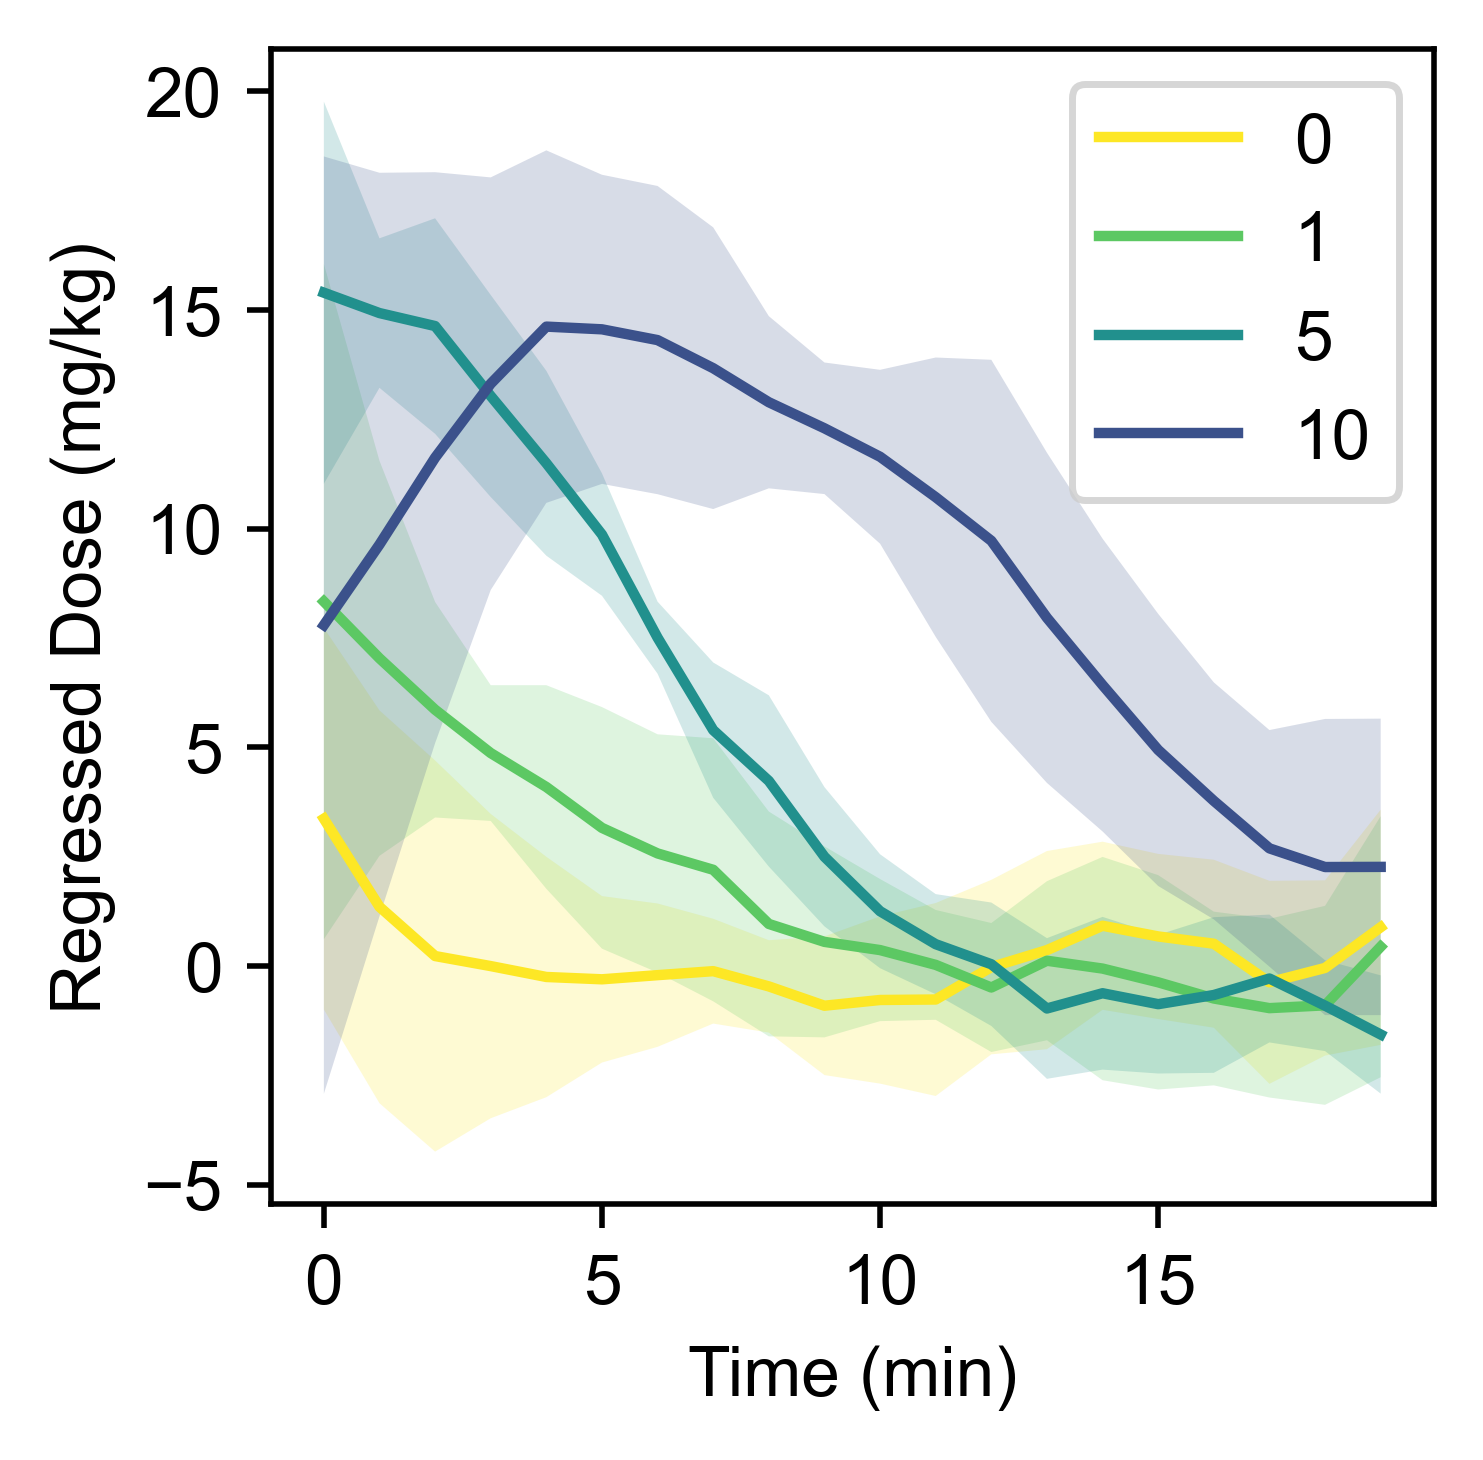

In [72]:
`cmap = plt.get_cmap("viridis_r")
colors = [cmap([i]) for i in np.arange(0,1,1/4)]


labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)
all_module_usage = all_module_usage.scale()
all_modules = [int(i.split("module")[1]) for i in all_module_usage.to_df().columns if "module" in i]

plt.figure(figsize=(3,3),dpi=500)
group_names = {"saliv": 0,"k1iv": 1,"k5iv": 5,"k10iv": 10}
for g,group in enumerate(["saliv","k1iv","k5iv","k10iv"]):
    labels_df = analysis.get_module_labels(config,0,60*20,subgroups=[group])
    module_usage = analysis.get_module_usage(config, labels_df,binsize=60)
    usage_density = module_usage.usage_density(convolve=True,window=5)
    dropped = [i for i in all_modules if i not in usage_density[0].index]
    usage_density_scaled = []
    for d in usage_density:
        for drop in dropped:
            d.loc[drop] = np.zeros(usage_density[0].shape[1])
        usage_density_scaled.append(pd.DataFrame(all_module_usage.scaler.transform(d.T).T))
    x = []
    for item in usage_density_scaled:
        x.append(reg.predict(np.array(item,dtype=float).T))
    
    plt.plot(np.array(usage_density[0].columns)/60,np.mean(x,axis=0),color=colors[g],label=group_names[group])
    plt.fill_between(np.array(usage_density[0].columns)/60,np.mean(x,axis=0)-np.std(x,axis=0),np.mean(x,axis=0)+np.std(x,axis=0),color=colors[g],alpha=0.2,edgecolor="none")
plt.xlabel("Time (min)")
plt.ylabel("Regressed Dose (mg/kg)")
plt.legend()

(0.0, 10.0)

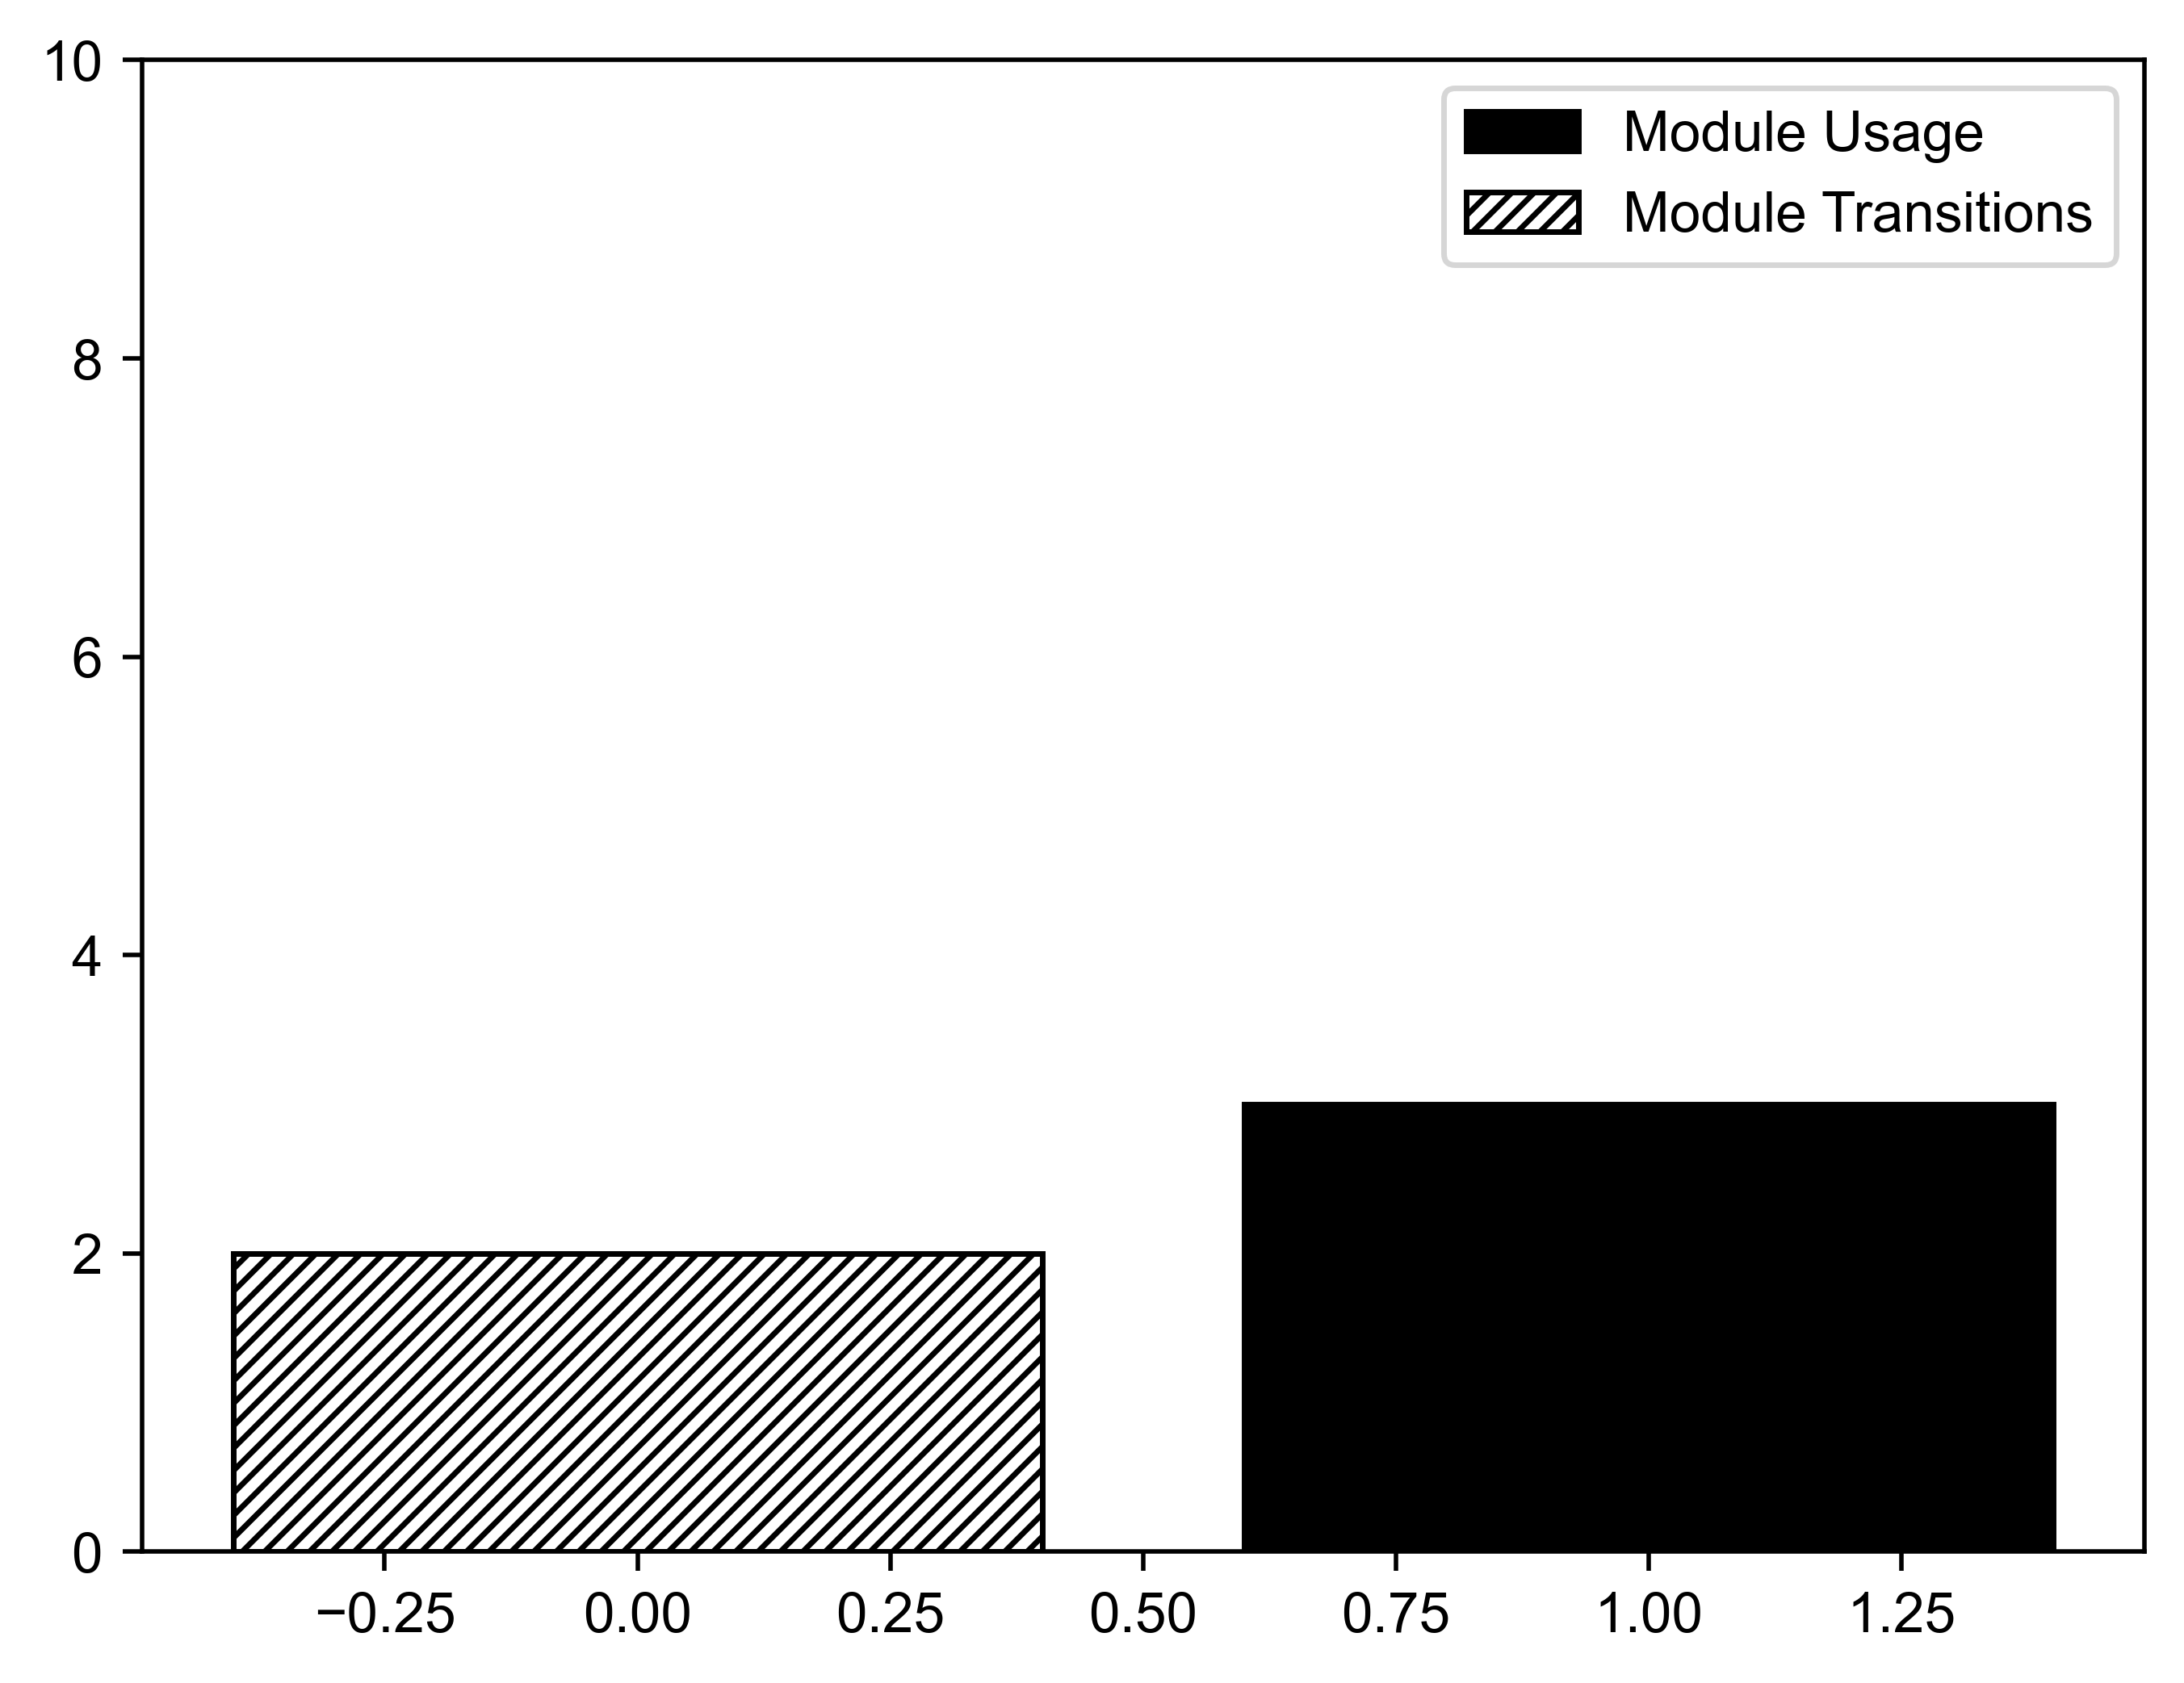

In [29]:
plt.figure(dpi=500)
plt.bar(1,height=3,color="black",edgecolor="black",label="Module Usage")
plt.bar(0,height=2,hatch="//////",color="none",edgecolor="black",label="Module Transitions")
#plt.ylim([0,10])
plt.legend()
plt.ylim(0,10)

In [222]:
pk_config_paths=["/Users/snewbank/Behavior/MARIPOSA_test/240827_BSOID-test/config_PS_pk.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS_pk.yaml",
              "/Users/snewbank/Behavior/MARIPOSA_test/240901_KPMS-full/config_PS_pk.yaml"]

pk_config_path=pk_config_paths[dset]

#Load config
pk_config = metadata.load_project(pk_config_path)

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_coc']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalket']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5iv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25']
done with ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25']
done with ['BINARY_bf01_k5.csv', '2023-06-20_16-46-29_bf01_k5']
done with ['BINARY_2023-12-27_14-40-30_bf15_d16.csv', '2023-12-27_14-40-30_bf15_d16']
VAME modules map onto scored behaviors with 'loss' of 0.4585485775567791
done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_

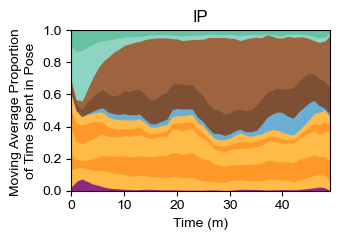

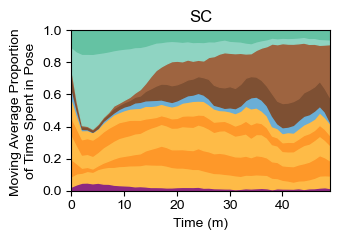

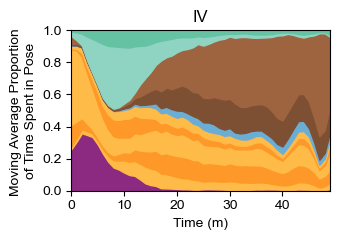

In [223]:
group_names = {"k10iv": "IV", "k10ip":"IP","k10sc":"SC"}
for group in ["k10ip","k10sc","k10iv"]:
    labels_df = analysis.get_module_labels(pk_config,0,60*50,subgroups=[group])
    module_usage = analysis.get_module_usage(pk_config, labels_df,binsize=60)
    BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
    analysis.make_remappings_from_BORIS(pk_config,BORIS_to_pose_mat=BORIS_to_pose_mat)
    plot.module_usage_sandplot(pk_config, module_usage, BORIS_to_pose_mat = BORIS_to_pose_mat_normalized, figW=3.5, figH=2.5, convolve=True, long_legend=True,title=group_names[group])
    if save:
        plt.savefig(save_path+f"sandplot_{group_names[group]}.png",dpi=800)

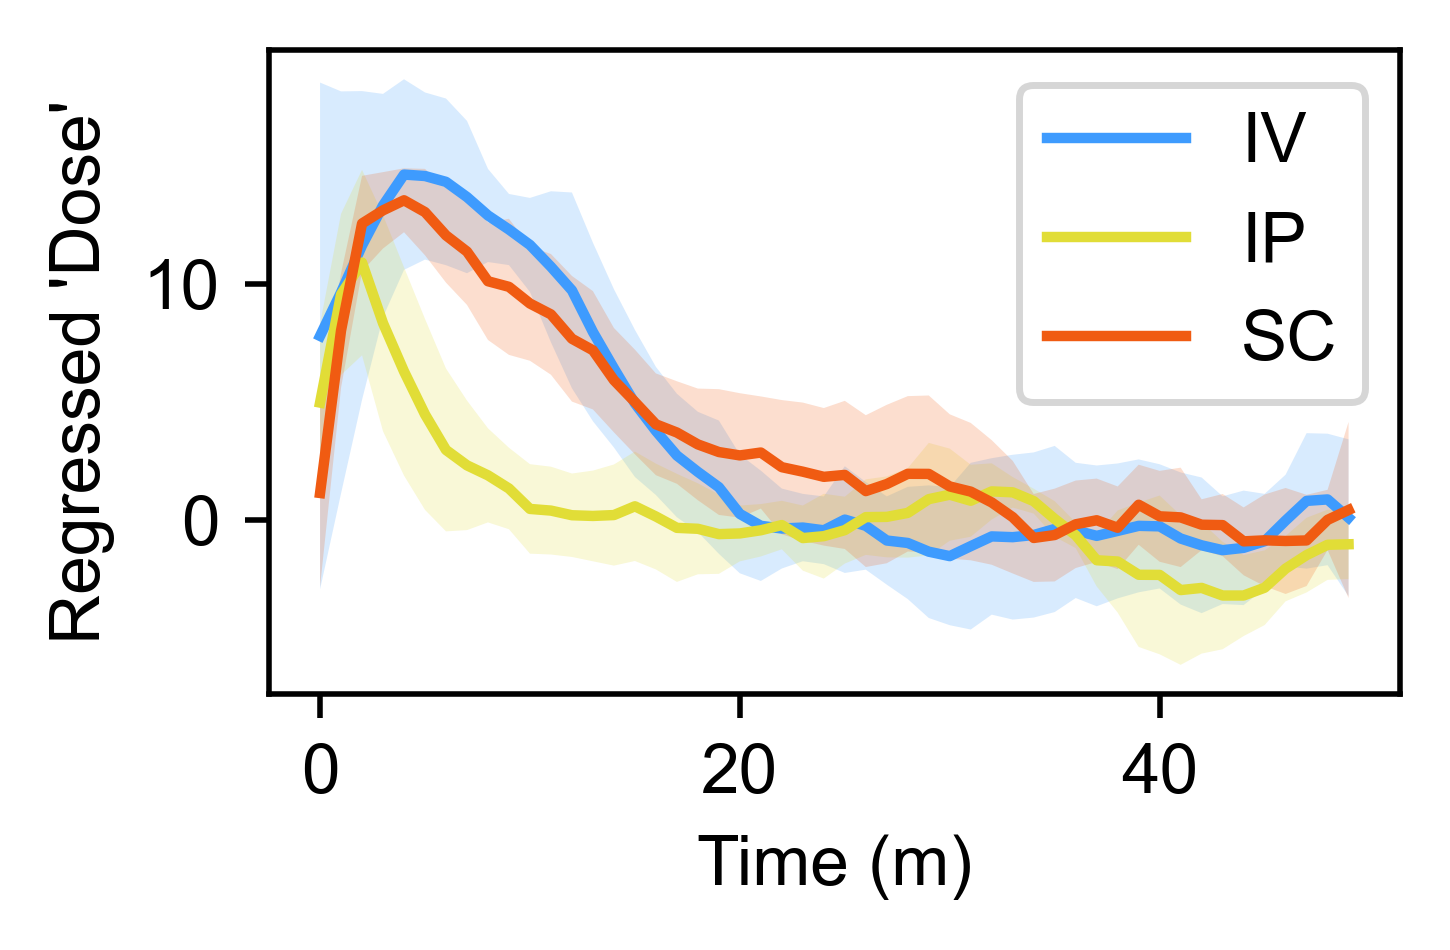

In [281]:
cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]


labels_df = analysis.get_module_labels(config,0,1200,subgroups="all")
all_module_usage = analysis.get_module_usage(config, labels_df)
all_module_usage = all_module_usage.scale()
all_modules = [int(i.split("module")[1]) for i in all_module_usage.to_df().columns if "module" in i]

plt.figure(figsize=(3,2),dpi=500)
group_names = {"k10iv": "IV", "k10ip":"IP","k10sc":"SC"}
group_pk_data = {}
for g,group in enumerate(["k10iv","k10ip","k10sc"]):
    labels_df = analysis.get_module_labels(pk_config,0,60*50,subgroups=[group])
    module_usage = analysis.get_module_usage(pk_config, labels_df,binsize=60)
    usage_density = module_usage.usage_density(convolve=True,window=5)
    dropped = [i for i in all_modules if i not in usage_density[0].index]
    usage_density_scaled = []
    for d in usage_density:
        for drop in dropped:
            d.loc[drop] = np.zeros(usage_density[0].shape[1])
        usage_density_scaled.append(pd.DataFrame(all_module_usage.scaler.transform(d.T).T))
    regressed_traces = []
    for item in usage_density_scaled:
        regressed_traces.append(reg.predict(np.array(item,dtype=float).T))
    
    plt.plot(np.array(usage_density[0].columns)/60,np.mean(regressed_traces,axis=0),color=colors[g],label=group_names[group])
    plt.fill_between(np.array(usage_density[0].columns)/60,np.mean(regressed_traces,axis=0)-np.std(regressed_traces,axis=0),np.mean(regressed_traces,axis=0)+np.std(regressed_traces,axis=0),color=colors[g],alpha=0.2,edgecolor="none")
    group_pk_data[group_names[group]] = regressed_traces
plt.xlabel("Time (m)")
plt.ylabel("Regressed 'Dose'")
plt.legend()
plt.tight_layout()
if save:
    plt.savefig(save_path+f"ROA_regressed_dose.png",dpi=800)

In [254]:
np.arange(0,50,1)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

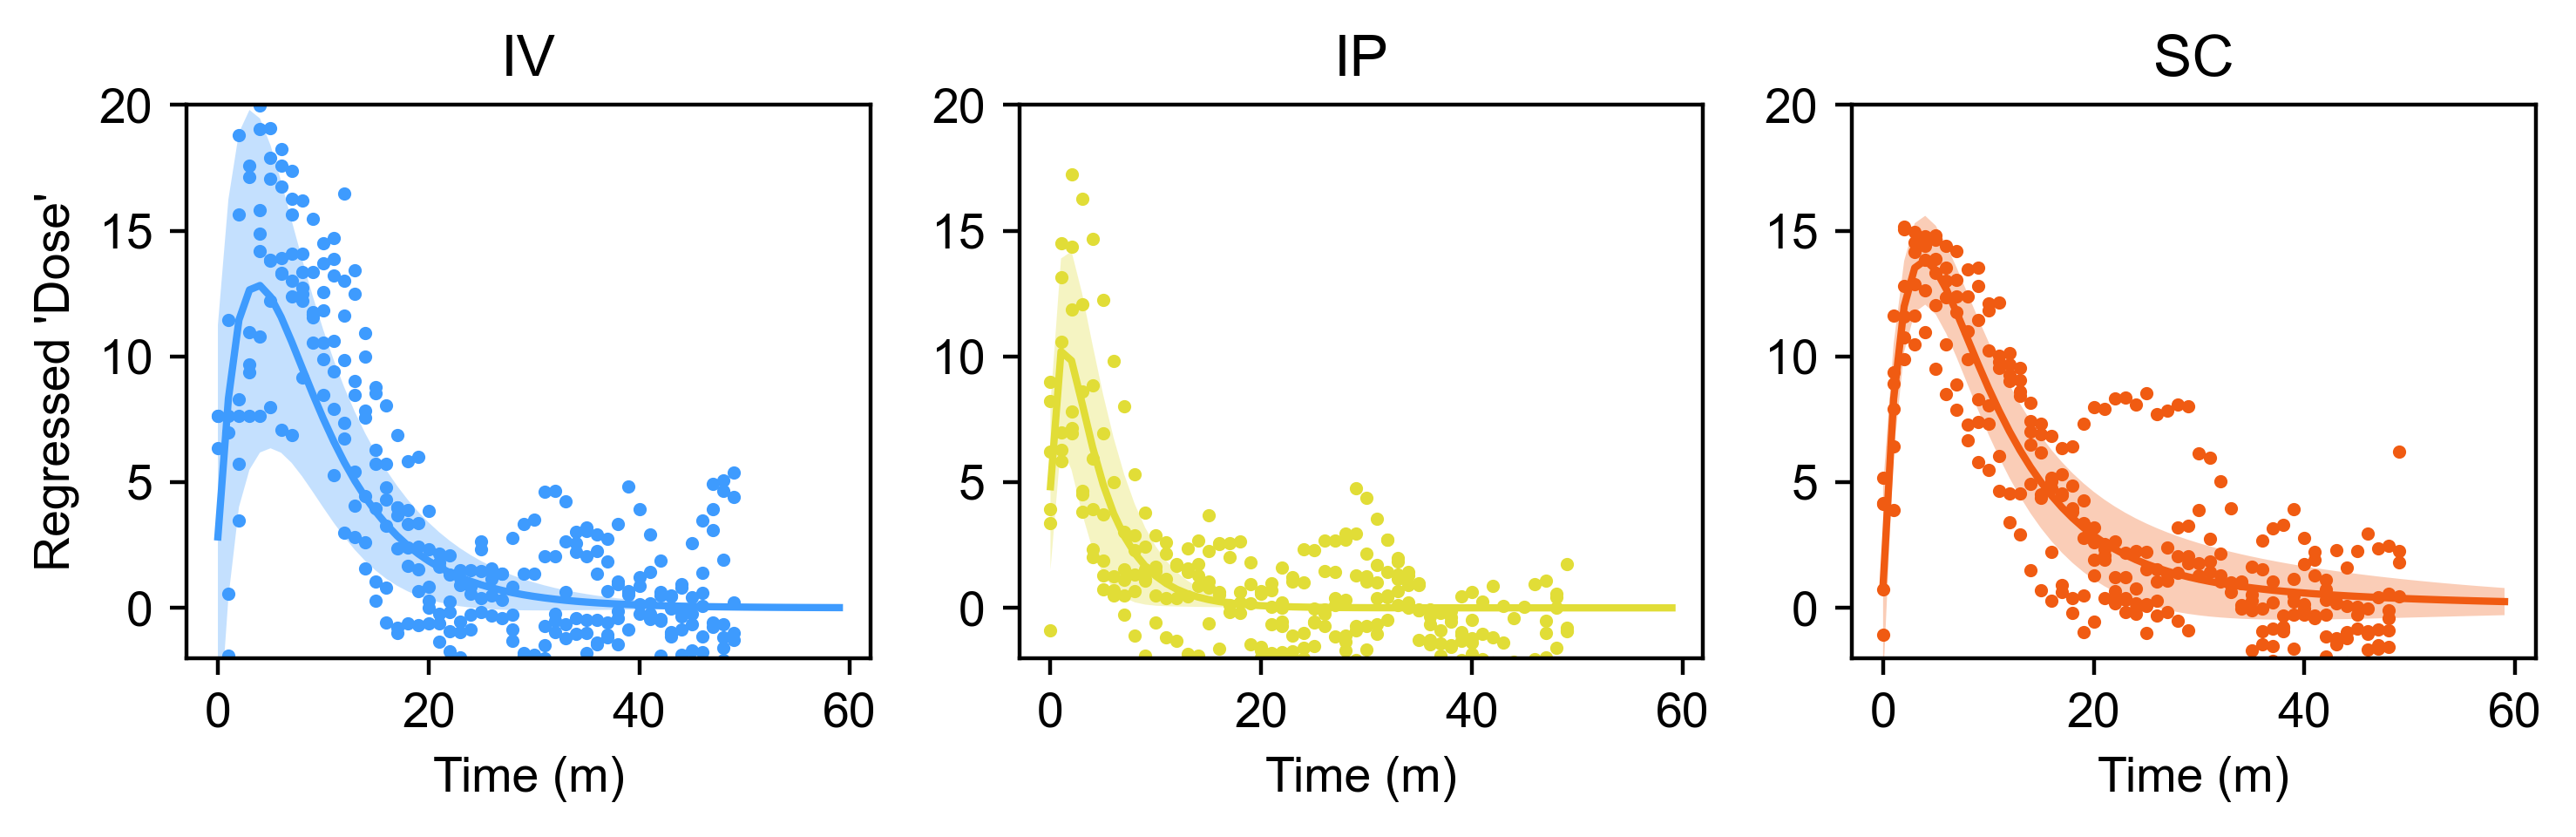

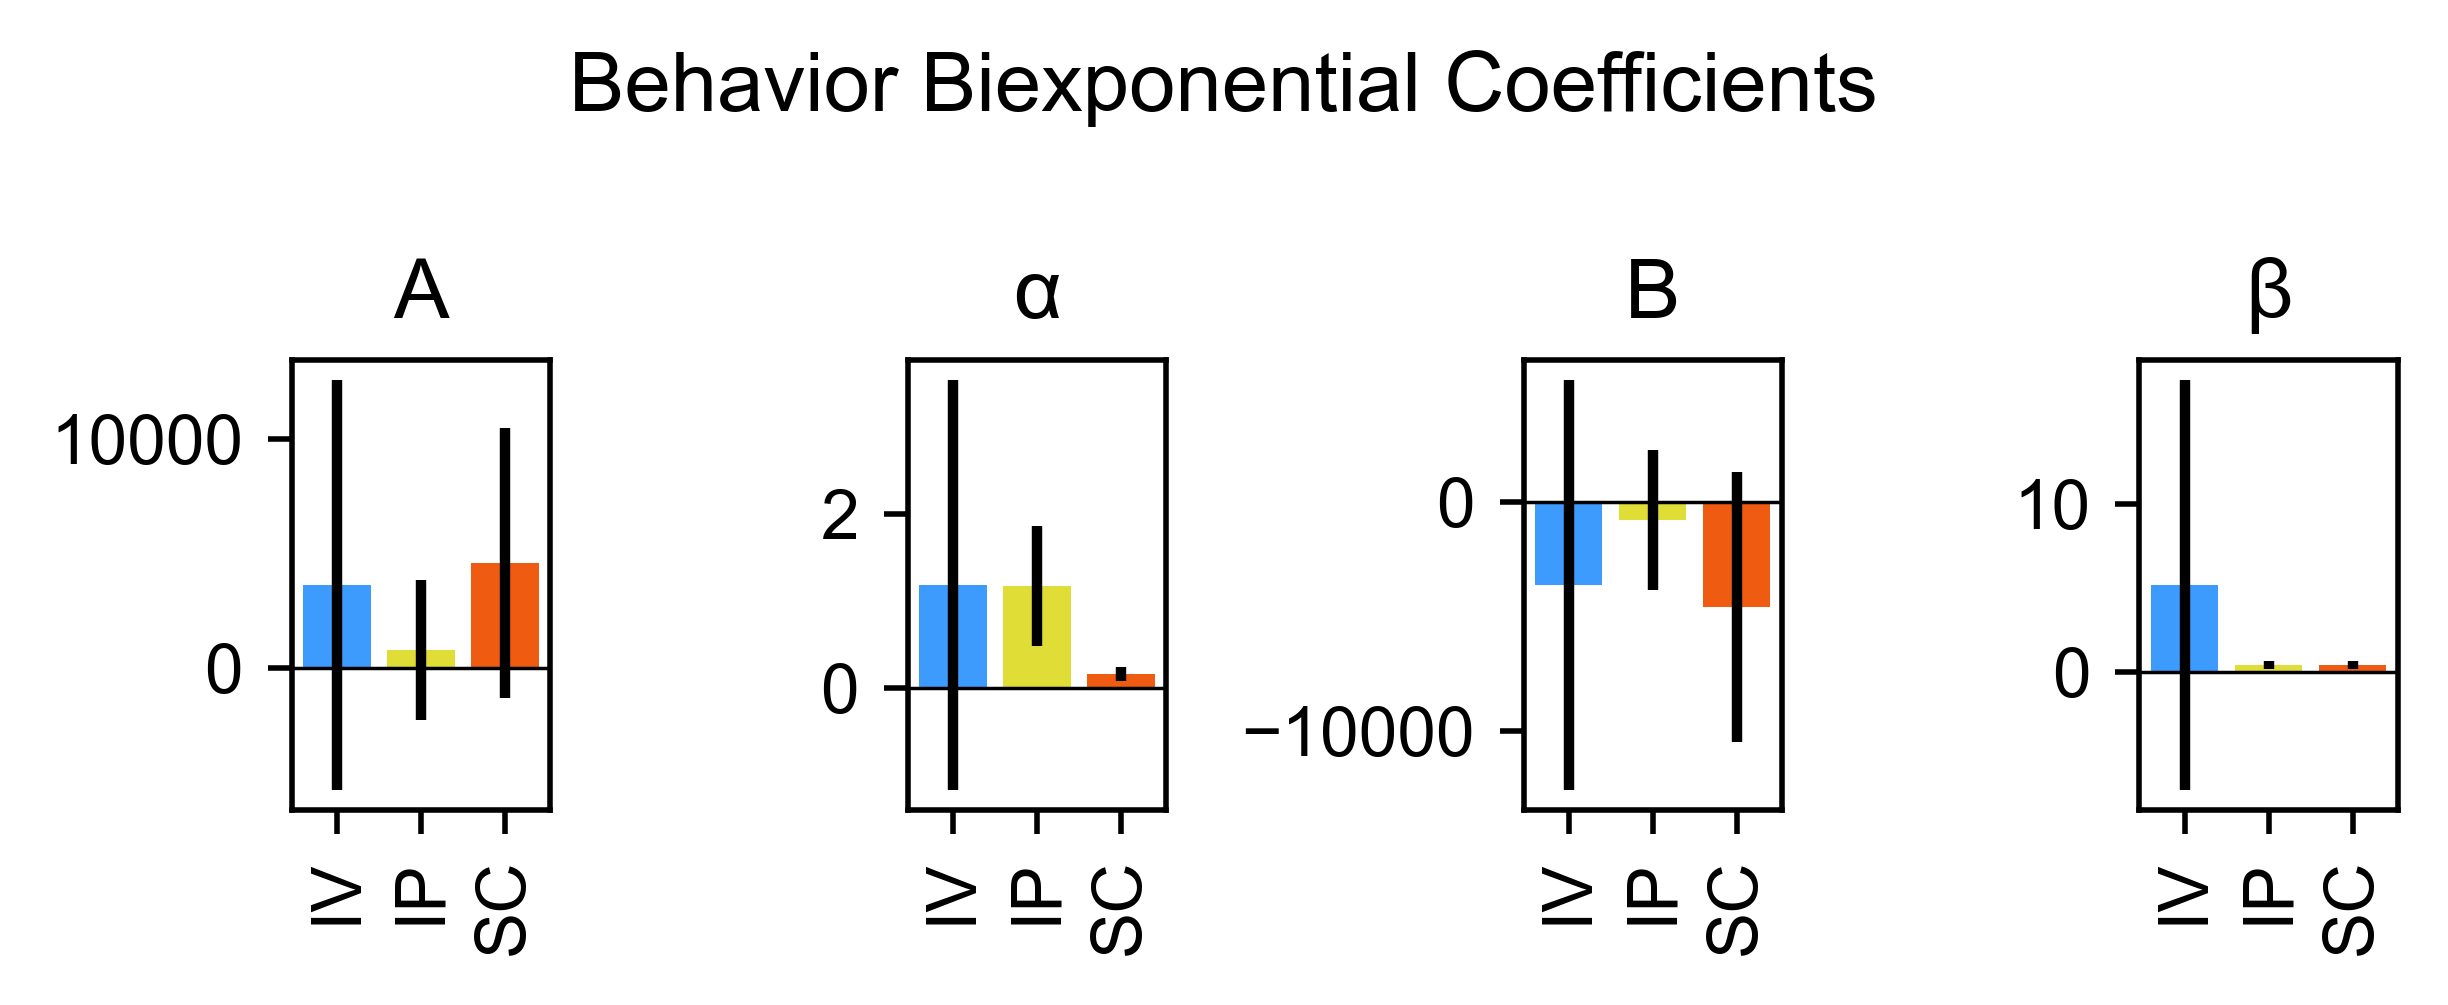

In [273]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))
    

groups=["IV","IP","SC"]

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups):
    fits=[]
    subj=[]
    for i in range(len(group_pk_data[group])):
        try:
            data_i = group_pk_data[group][i]
            if len(data_i)==0:
                continue
            t = np.arange(0,50,1)
            c = group_pk_data[group][i]
            ax[g].scatter(t,c,color=colors[group],s=3)
            fit = fit_to_biexponential(t,c)
            fits.append(fit[0])
            subj.append(group+"_"+str(i))
            #ax[g].plot(t,biexponential(t,*fit[0]))
        except:
            continue
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-2,20])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel("Regressed 'Dose'")
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_ssd_fit.png",dpi=500)


fig, ax = plt.subplots(1,4,figsize=(5,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels,rotation=90)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.suptitle("Behavior Biexponential Coefficients")
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_ssd_fit_params.png",dpi=500)

drop


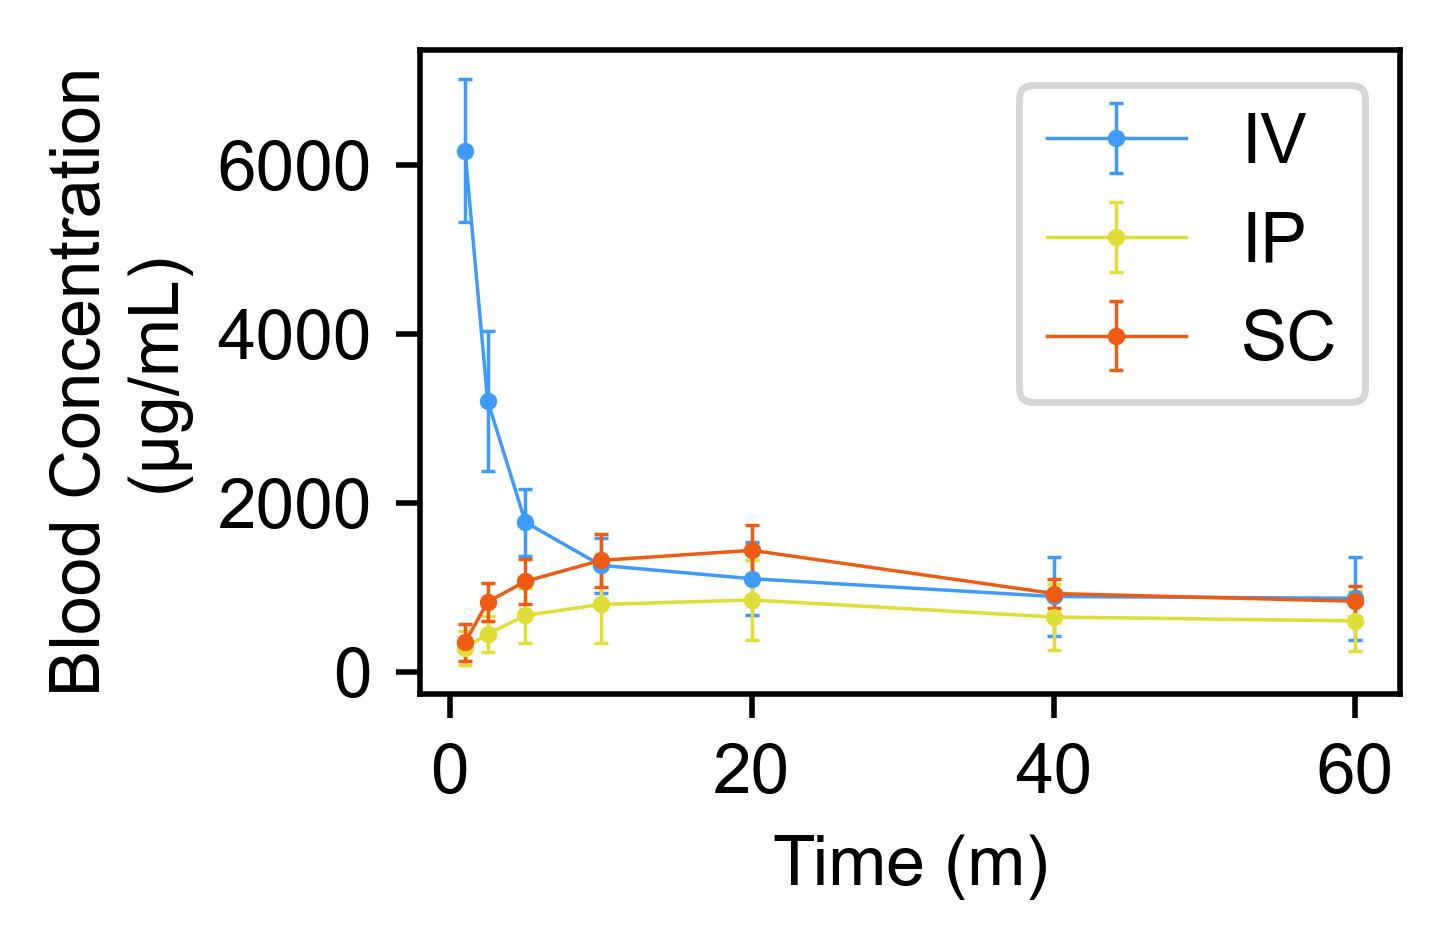

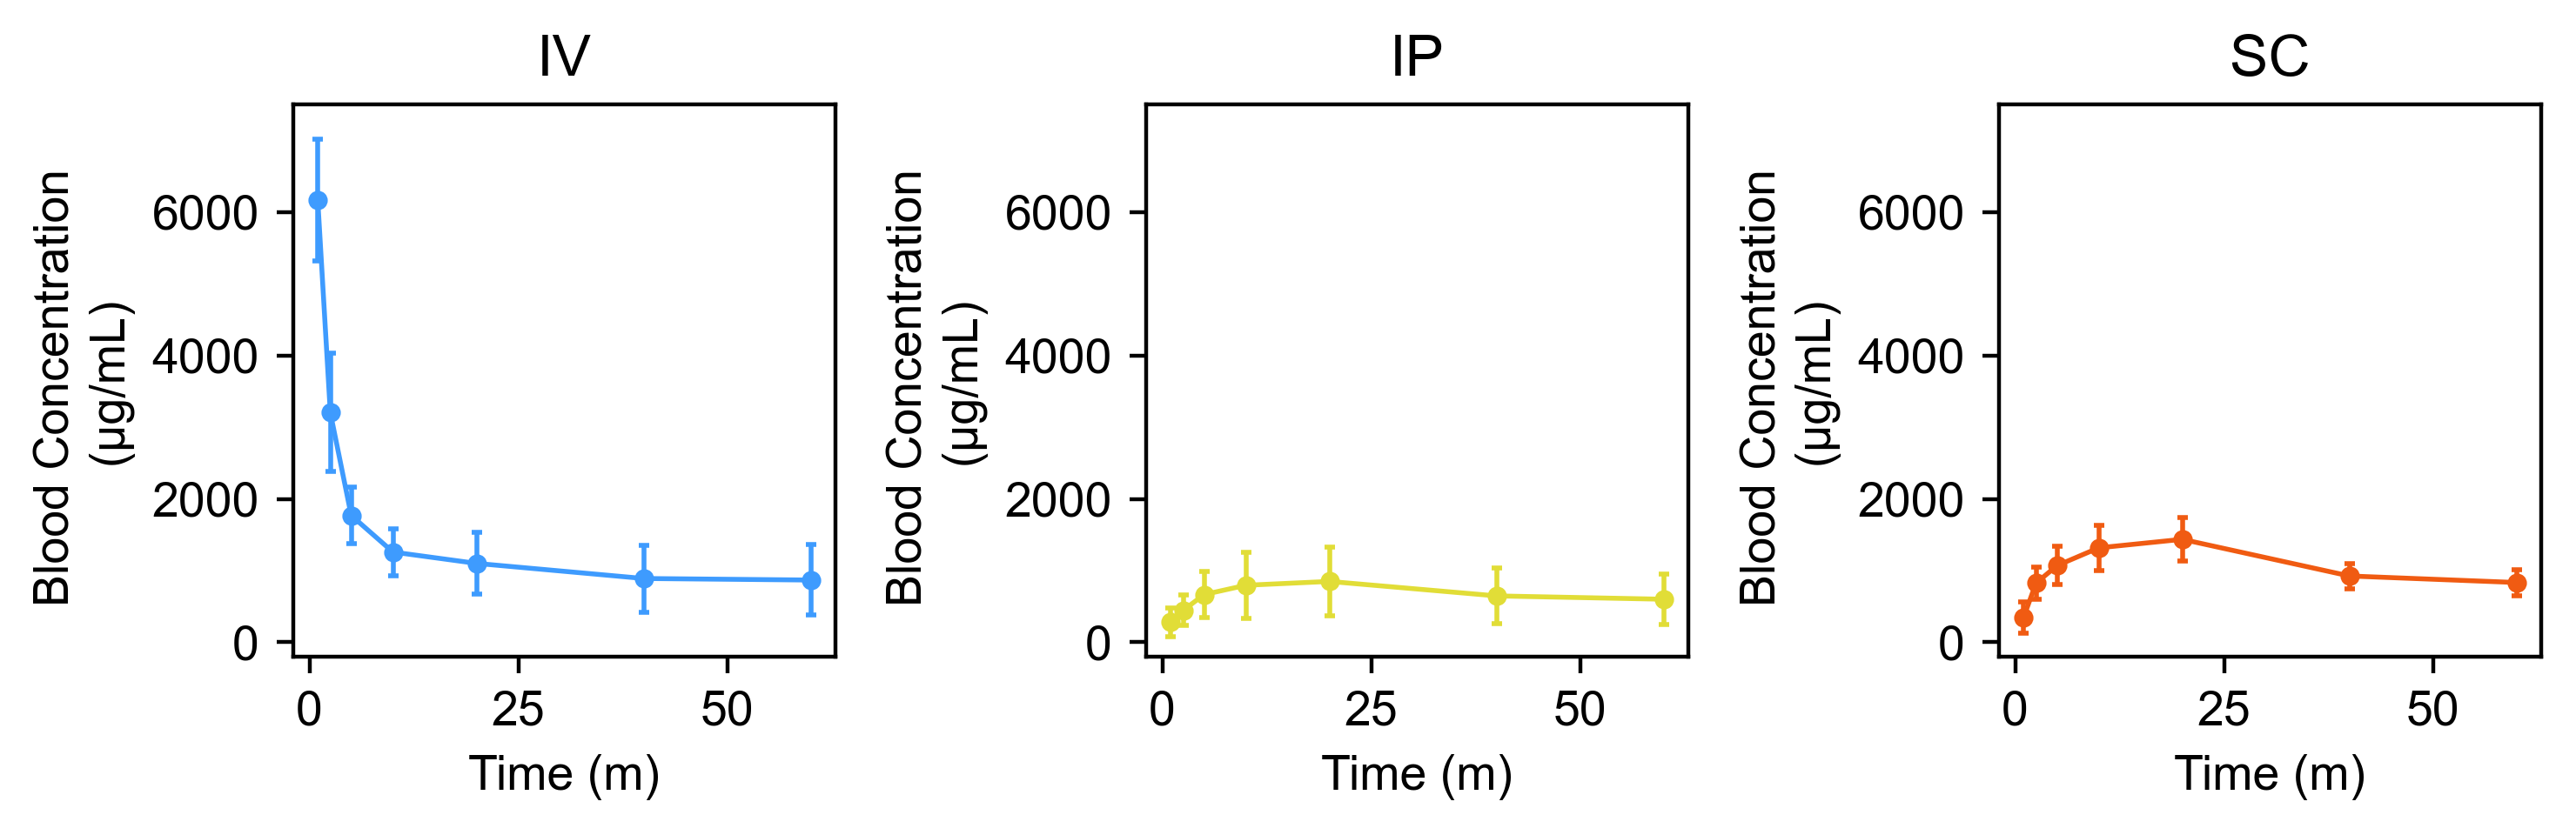

In [274]:
def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    if drops==True:
        # df.at[1.0,"R13"]=np.nan
        # df.at[1.0,"R3"]=np.nan
        # df.at[2.5,"R3"]=np.nan
        # df.at[5.0,"R3"]=np.nan
        # df.at[10.0,"R3"]=np.nan
        # df.at[20.0,"R3"]=np.nan
        # df.at[40.0,"R3"]=np.nan
        # df.at[60.0,"R3"]=np.nan
        df.at[1.0,"R13"]=np.nan
        print("drop")
    df.drop(index=62.0,inplace=True)
    return df

#Load the data
pk_path="/Users/snewbank/Documents/PhD/Data/25-02-06-bloodPKexpt-full/25-02-06_ketblood_ROAs.csv"


IV=["R1","R4","R7","R10","R13","R14","R17"]
SC=["R2","R5","R8","R11","R20"]
IP=["R3","R6","R9","R12","R15","R16","R18","R19"]

cmap=plt.get_cmap("turbo")

drops_TF=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)

#Making the 1-panel plot
plt.figure(figsize=(3,2),dpi=500)

df=df*20

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Blood Concentration \n(μg/mL)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit.png",dpi=500)
    

# Making the 3-panel plot
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Blood Concentration \n(μg/mL)')
    ax[k].set_title(key)
    ax[k].set_ylim([-200,7500])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_panel.png",dpi=500)

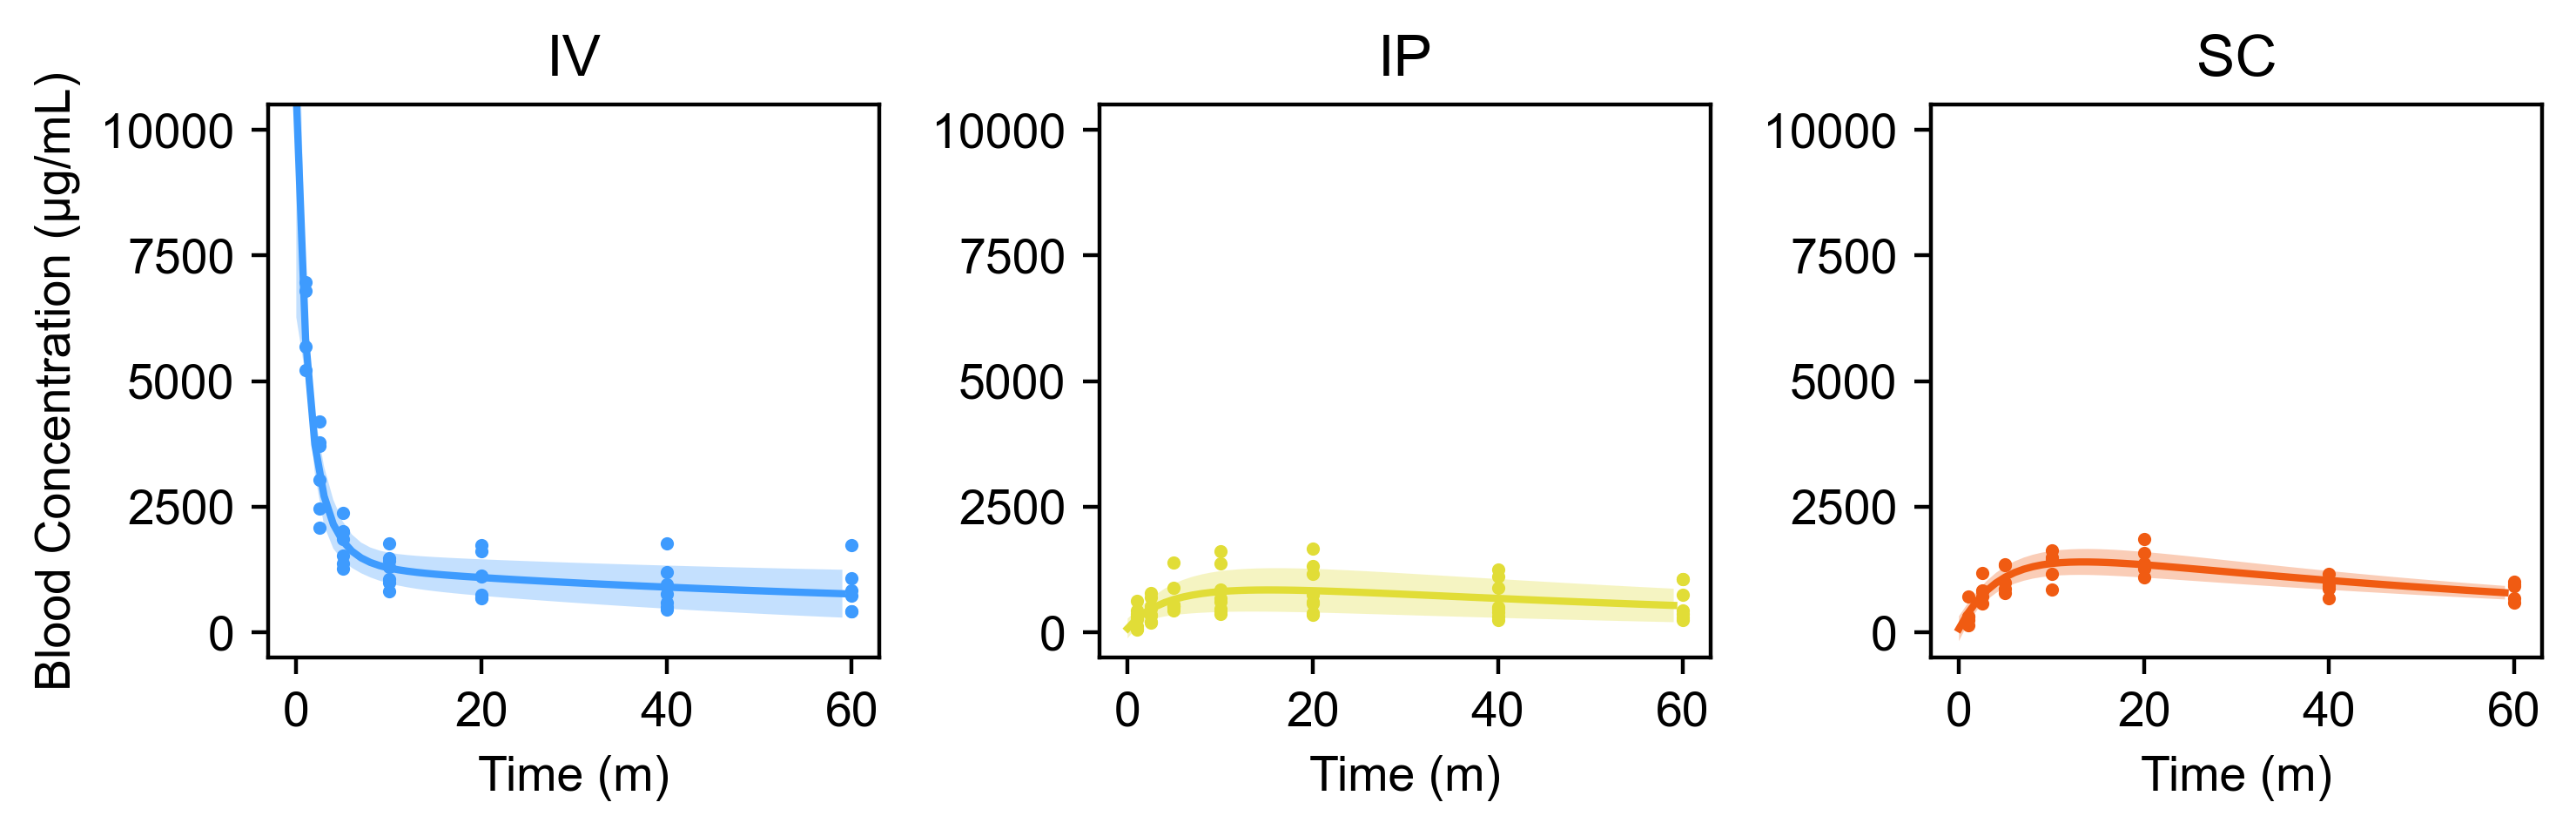

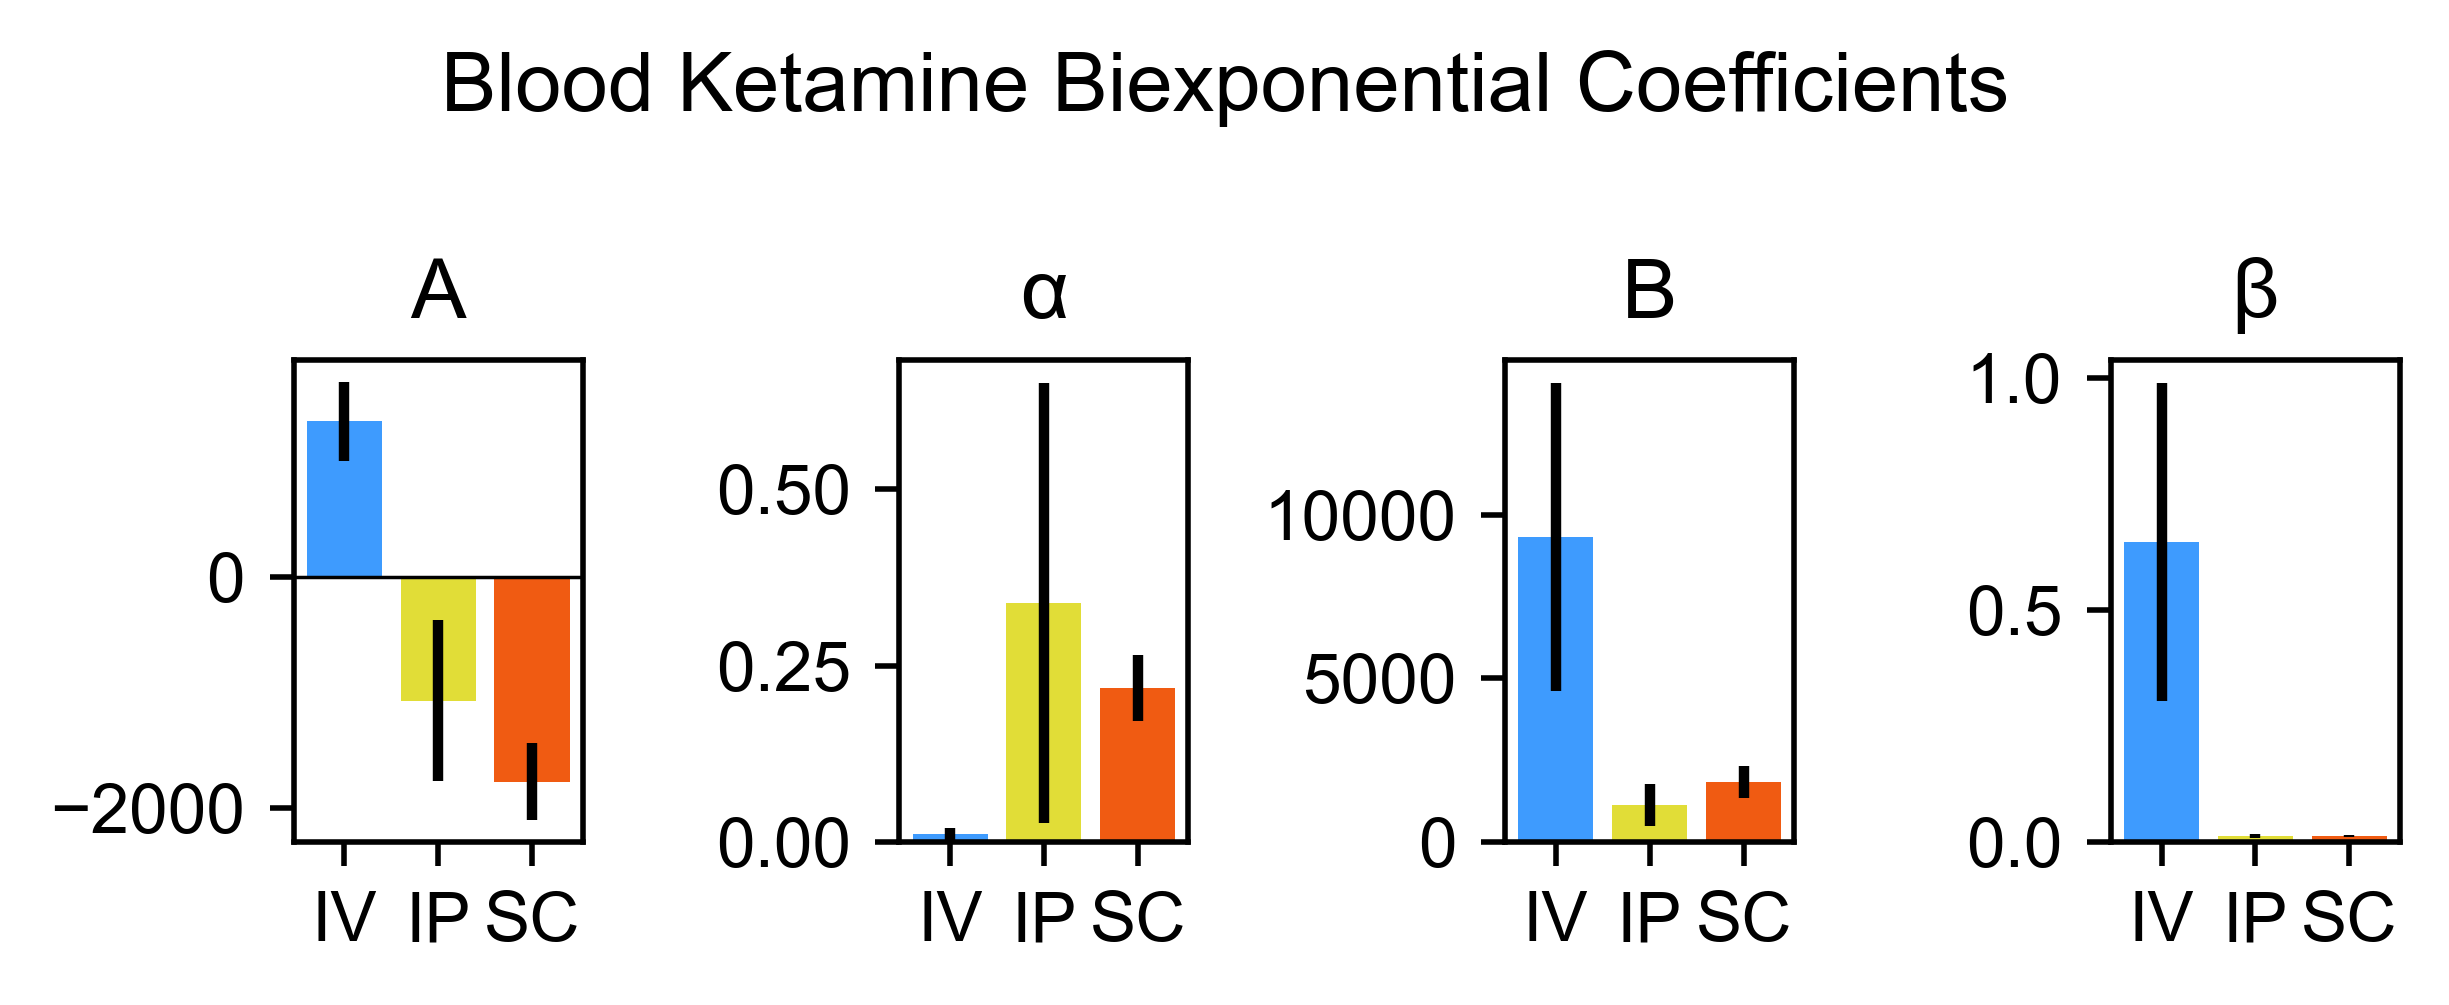

In [275]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))

def fit_to_biexponential(t,c):
    # Set initial "guess"
    p0=np.zeros(4)
    p0[0]=-10*slope([t[0],c[0]],[t[1],c[1]])
    p0[2]=-10*slope([t[np.argmax(c)],c[np.argmax(c)]],[t[-1],c[-1]])
    if np.argmax(c)!=0:
        p0[1] = 0.693/((t[np.argmax(c)]-t[0])/2)
    p0[3] = 0.693/((t[-1]-t[-2])/2)
    
    # Set bounds
    t0_to_peak=t[np.argmax(c)]
    peak_to_tlast=t[-1]-t[np.argmax(c)]
    
    bounds = ([-np.inf,0,-np.inf,0], [np.inf,t0_to_peak,np.inf,peak_to_tlast])
    
    for p,param in enumerate(p0):
        if param<bounds[0][p]:
            p0[p]=bounds[0][p]
        if param>bounds[1][p]:
            p0[p]=bounds[1][p]
    
    fit = optimize.curve_fit(biexponential, t, c, p0=p0, bounds=bounds, maxfev=10000)
    
    return fit

plot_types = ["mean_params","mean_fits"]
plot_type = plot_types[1]

groups={"IV" : IV, "IP" : IP, "SC" : SC}

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups.keys()):
    fits=[]
    subj=[]
    for i in range(len(df[groups[group]].columns)):
        data_i = df[groups[group]][df[groups[group]].columns[i]].dropna()
        if len(data_i)==0:
            continue
        subj.append(group+"_"+df[groups[group]].columns[i])
        t = data_i.index
        c = data_i.to_numpy()
        ax[g].scatter(t,c,color=colors[group],s=3)
        
        fit = fit_to_biexponential(t,c)
        fits.append(fit[0])
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-500,10500])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel("Blood Concentration (μg/mL)")
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_blood_fits.png",dpi=500)

fig, ax = plt.subplots(1,4,figsize=(5,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups.keys()):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.suptitle("Blood Ketamine Biexponential Coefficients")
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_blood_fit_params.png",dpi=500)

drop


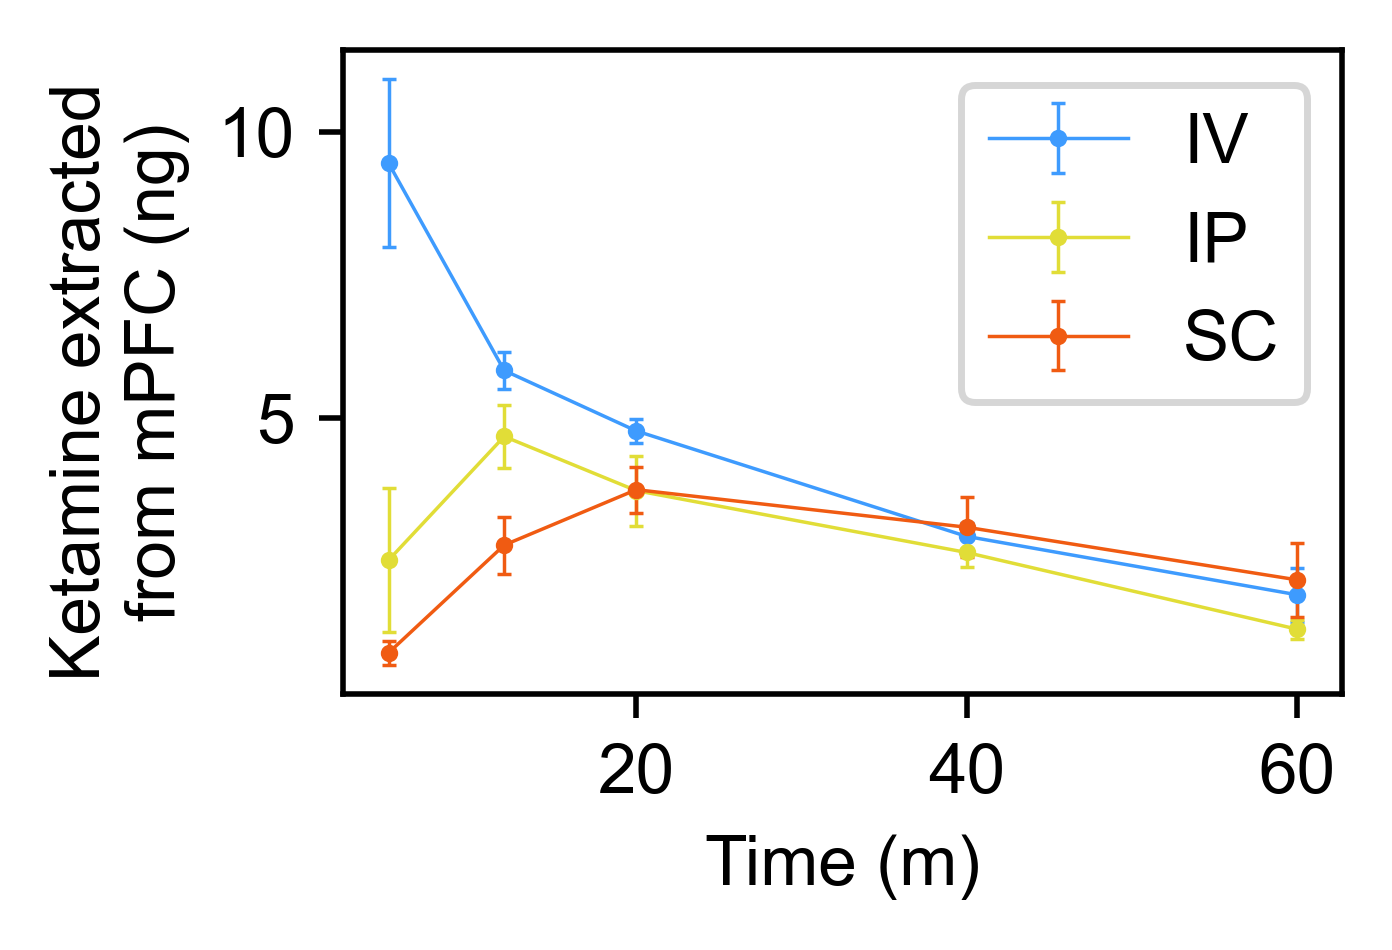

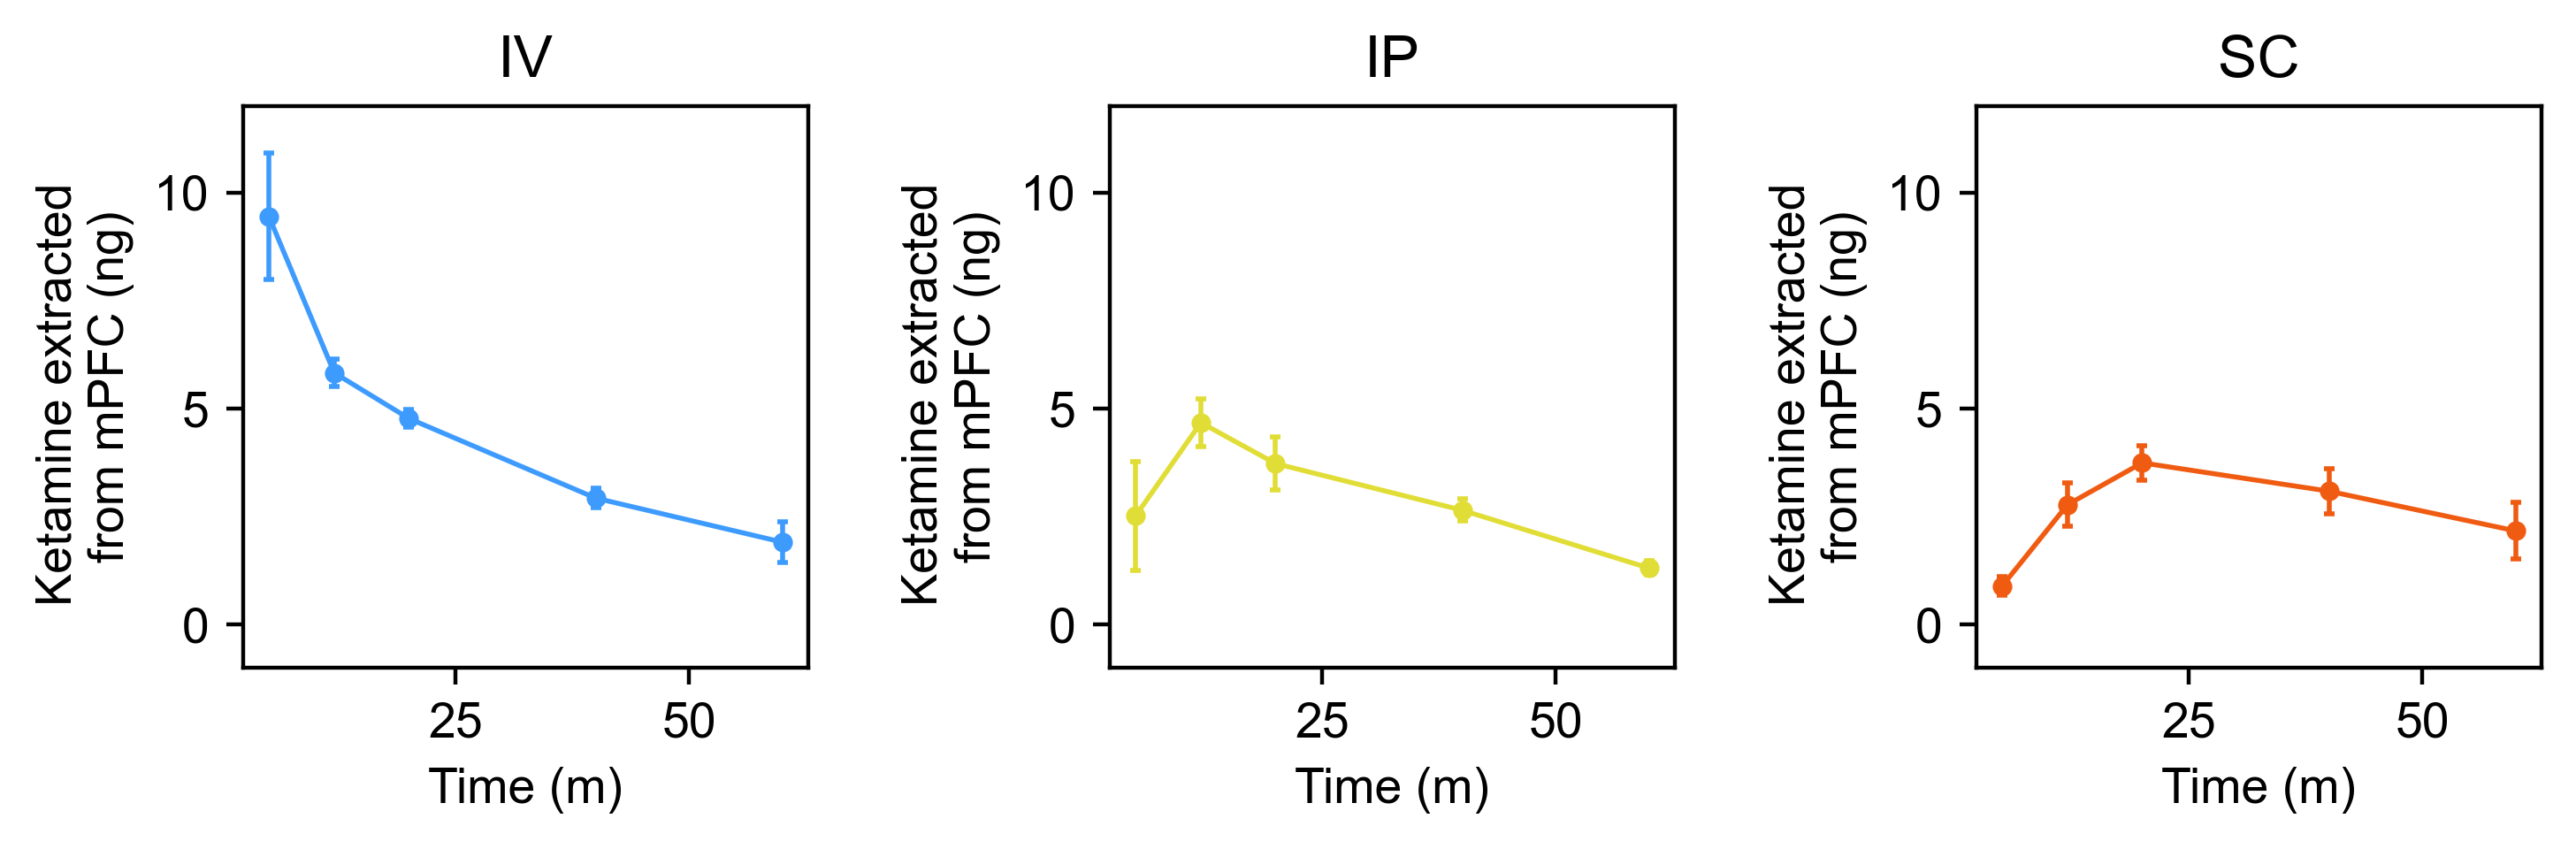

In [276]:
def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    if drops==True:
        # df.at[1.0,"R13"]=np.nan
        # df.at[1.0,"R3"]=np.nan
        # df.at[2.5,"R3"]=np.nan
        # df.at[5.0,"R3"]=np.nan
        # df.at[10.0,"R3"]=np.nan
        # df.at[20.0,"R3"]=np.nan
        # df.at[40.0,"R3"]=np.nan
        # df.at[60.0,"R3"]=np.nan
        #df.at[1.0,"R13"]=np.nan
        print("drop")
        #df.drop(index=62.0,inplace=True)
    return df

#Load the data
pk_path="/Users/snewbank/Documents/PhD/Data/25-03-16_brain_pk_ROAs.csv"

IV=["R1","R3","R5","R7"]
IP=["R6","R8","R10","R12"]
SC=["R2","R4","R9","R11"]

cmap=plt.get_cmap("turbo")

drops_TF=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)

#Making the 1-panel plot
plt.figure(figsize=(3,2),dpi=500)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Ketamine extracted \nfrom mPFC (ng)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_brain_no_fit.png",dpi=500)
    

# Making the 3-panel plot
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Ketamine extracted \nfrom mPFC (ng)')
    ax[k].set_title(key)
    ax[k].set_ylim([-1,12])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_brain_no_fit_panel.png",dpi=500)

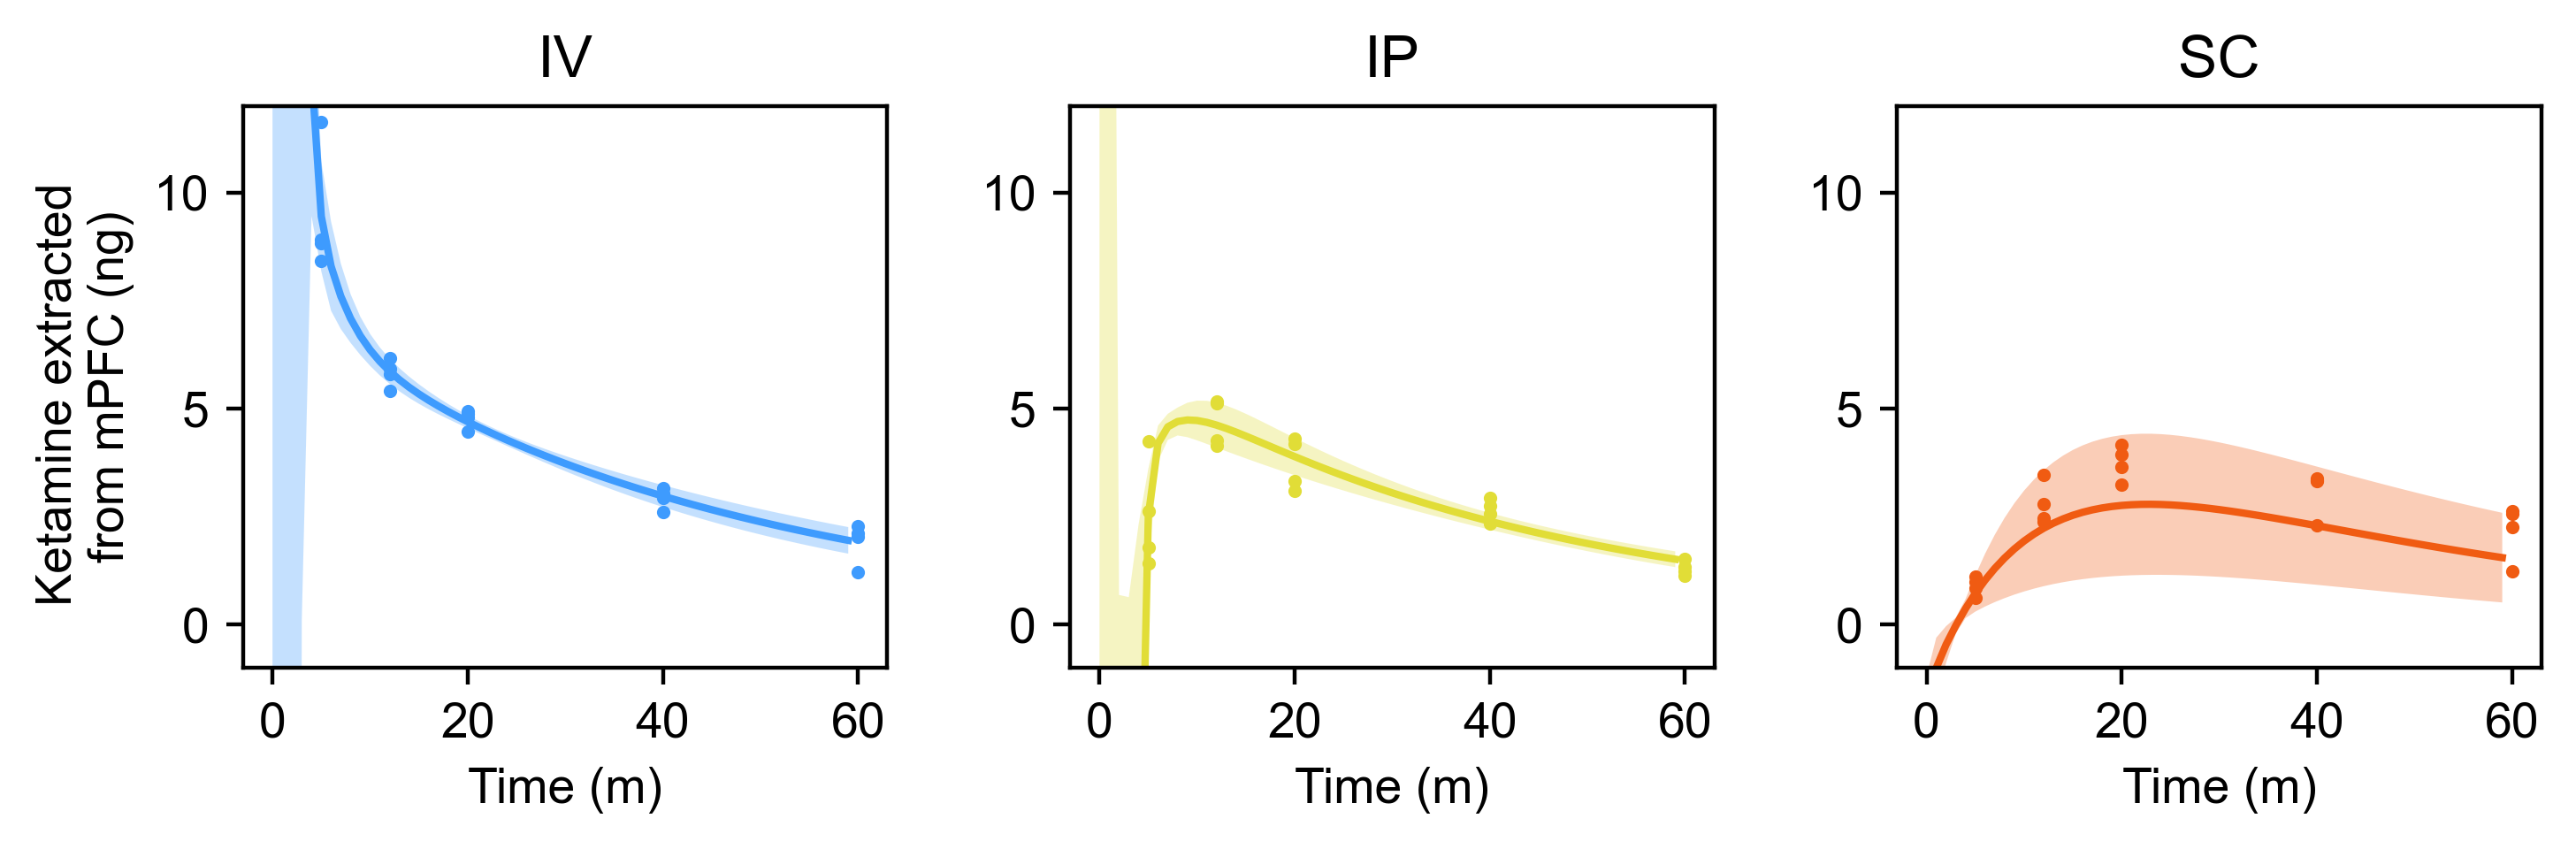

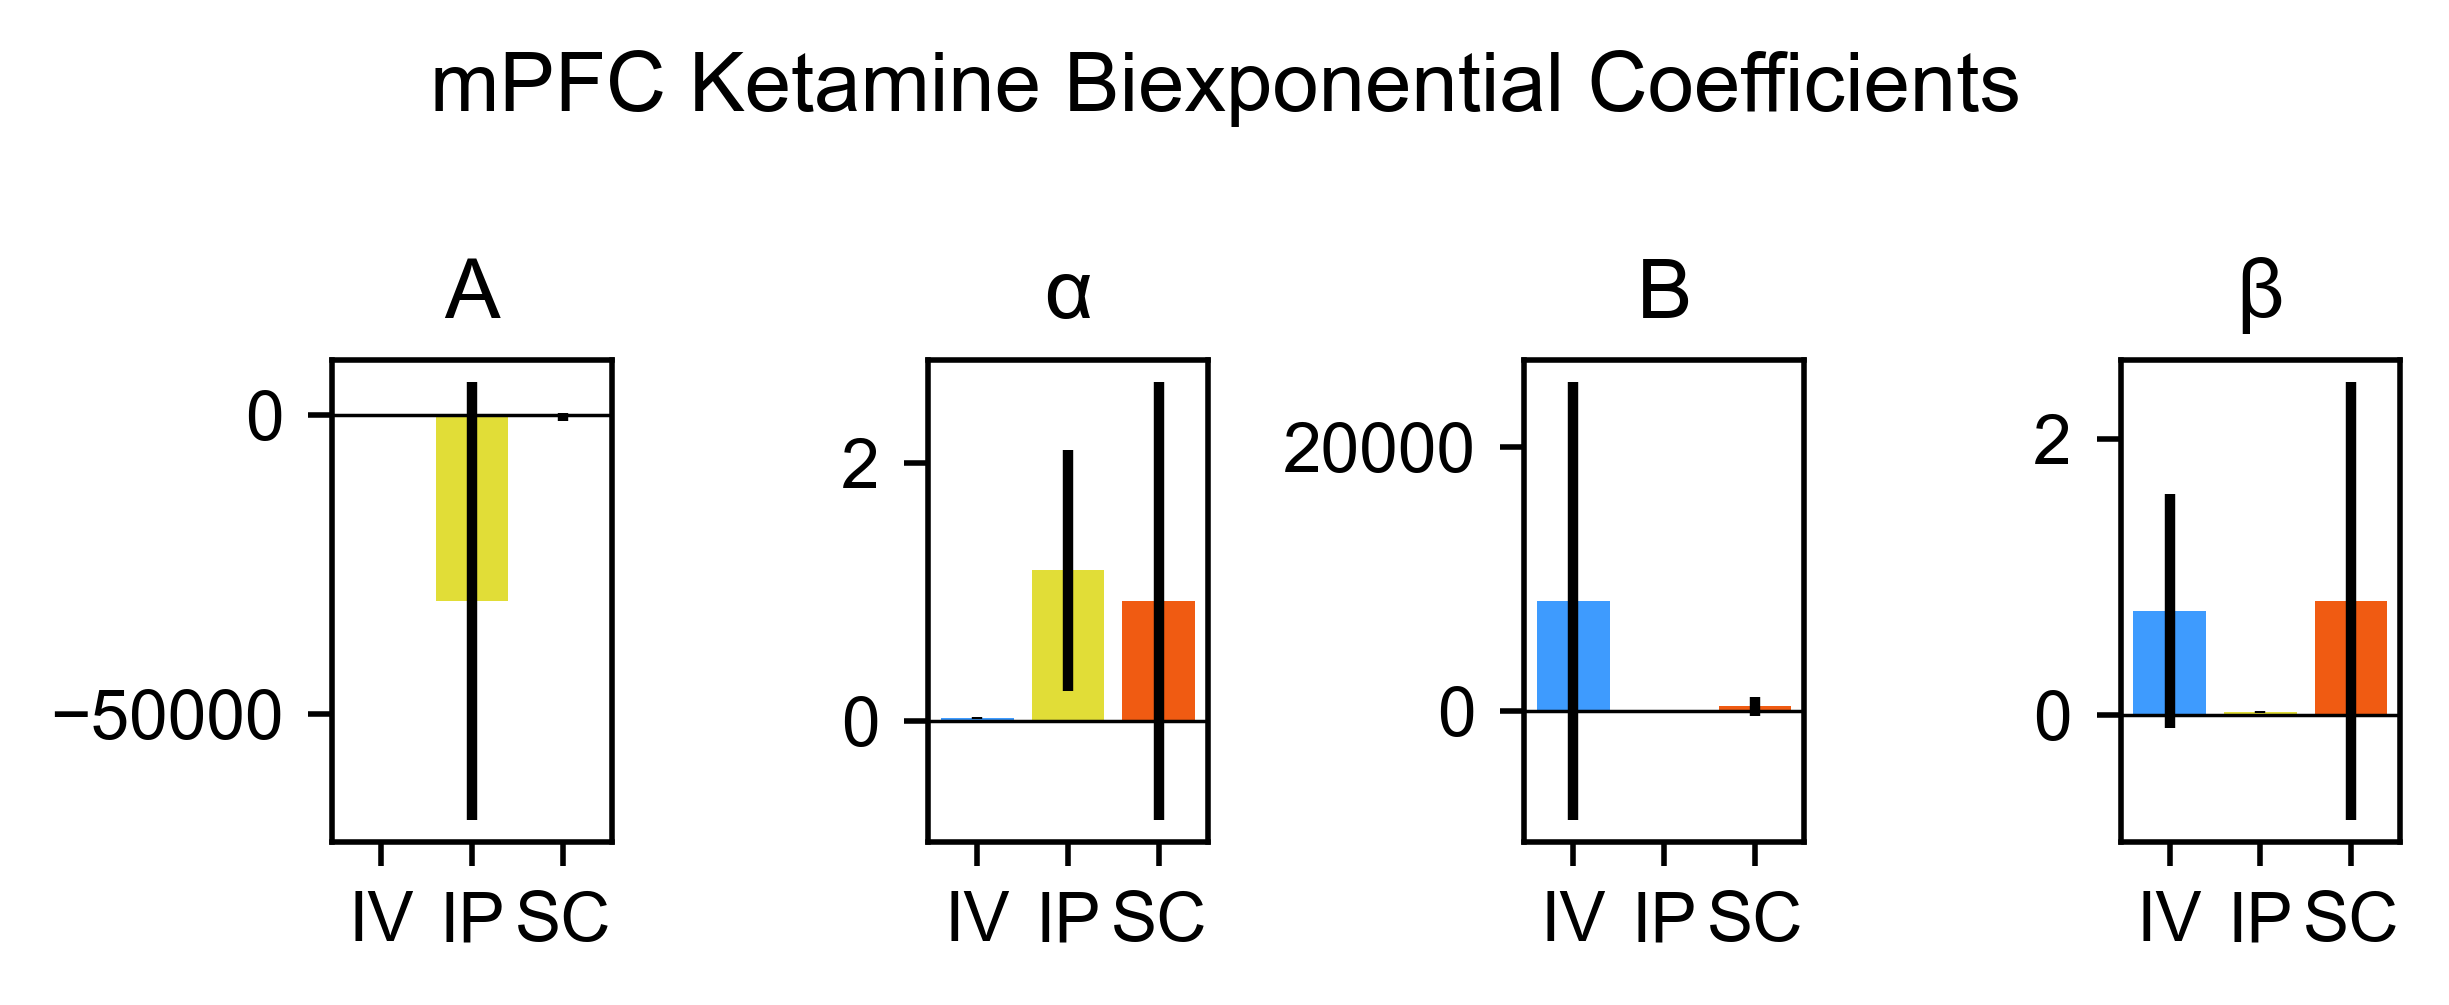

In [277]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))

def fit_to_biexponential(t,c):
    # Set initial "guess"
    p0=np.zeros(4)
    p0[0]=-10*slope([t[0],c[0]],[t[1],c[1]])
    p0[2]=-10*slope([t[np.argmax(c)],c[np.argmax(c)]],[t[-1],c[-1]])
    if np.argmax(c)!=0:
        p0[1] = 0.693/((t[np.argmax(c)]-t[0])/2)
    p0[3] = 0.693/((t[-1]-t[-2])/2)
    
    # Set bounds
    t0_to_peak=t[np.argmax(c)]
    peak_to_tlast=t[-1]-t[np.argmax(c)]
    
    bounds = ([-np.inf,0,-np.inf,0], [np.inf,t0_to_peak,np.inf,peak_to_tlast])
    
    for p,param in enumerate(p0):
        if param<bounds[0][p]:
            p0[p]=bounds[0][p]
        if param>bounds[1][p]:
            p0[p]=bounds[1][p]
    
    fit = optimize.curve_fit(biexponential, t, c, p0=p0, bounds=bounds, maxfev=10000)
    
    return fit

plot_types = ["mean_params","mean_fits"]
plot_type = plot_types[1]

groups={"IV" : IV, "IP" : IP, "SC" : SC}

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups.keys()):
    fits=[]
    subj=[]
    for i in range(len(df[groups[group]].columns)):
        data_i = df[groups[group]][df[groups[group]].columns[i]].dropna()
        if len(data_i)==0:
            continue
        subj.append(group+"_"+df[groups[group]].columns[i])
        t = data_i.index
        c = data_i.to_numpy()
        ax[g].scatter(t,c,color=colors[group],s=3)
        
        fit = fit_to_biexponential(t,c)
        fits.append(fit[0])
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-1,12])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel('Ketamine extracted \nfrom mPFC (ng)')
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_brain_fits.png",dpi=500)

fig, ax = plt.subplots(1,4,figsize=(5,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups.keys()):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.suptitle("mPFC Ketamine Biexponential Coefficients")
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_brain_fit_params.png",dpi=500)

drop


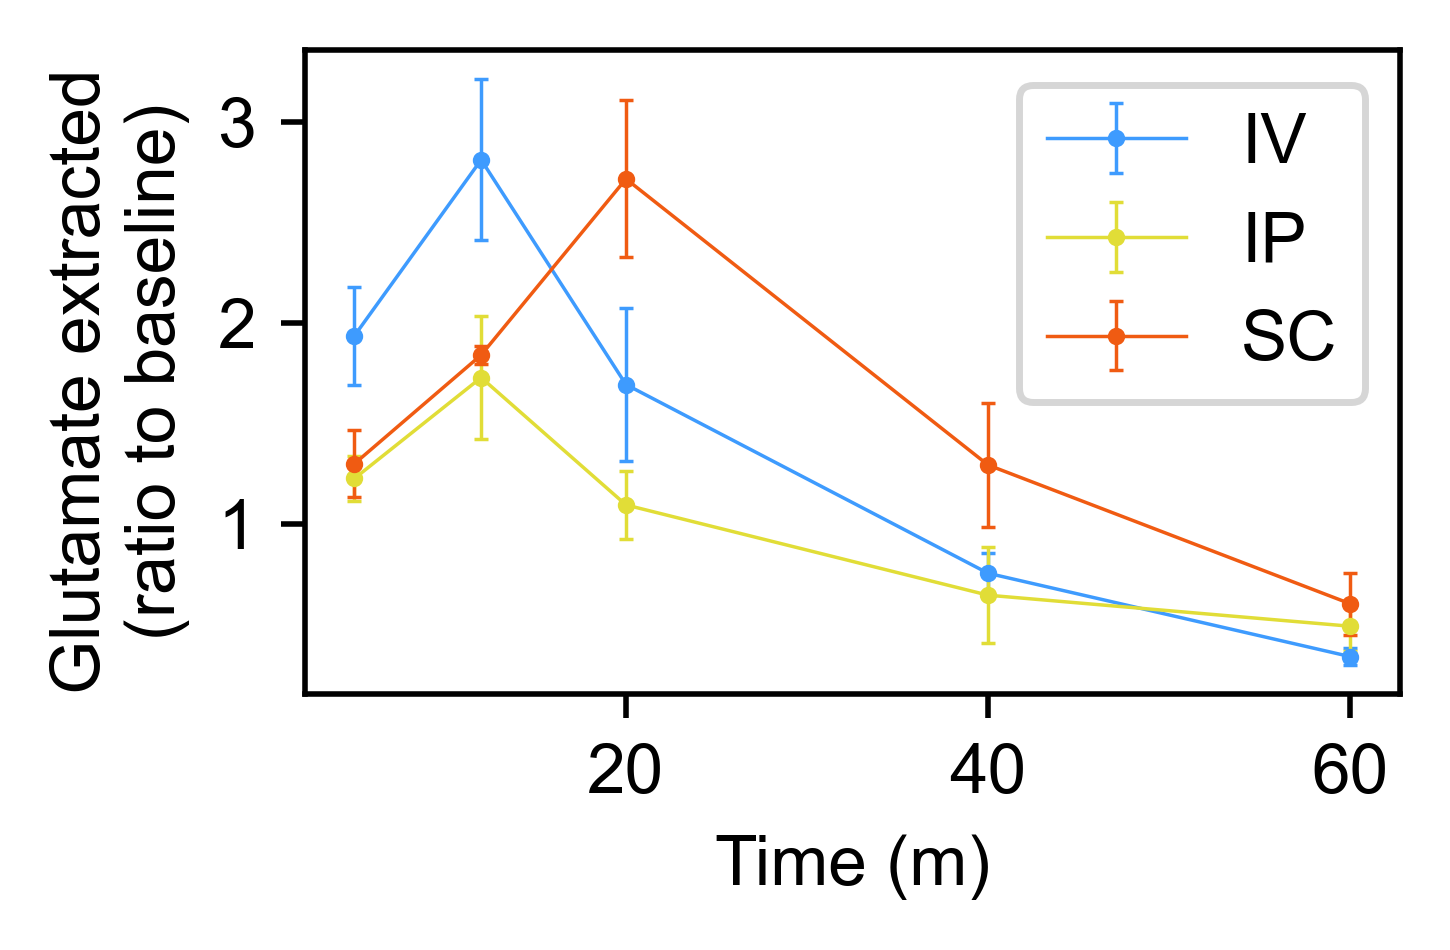

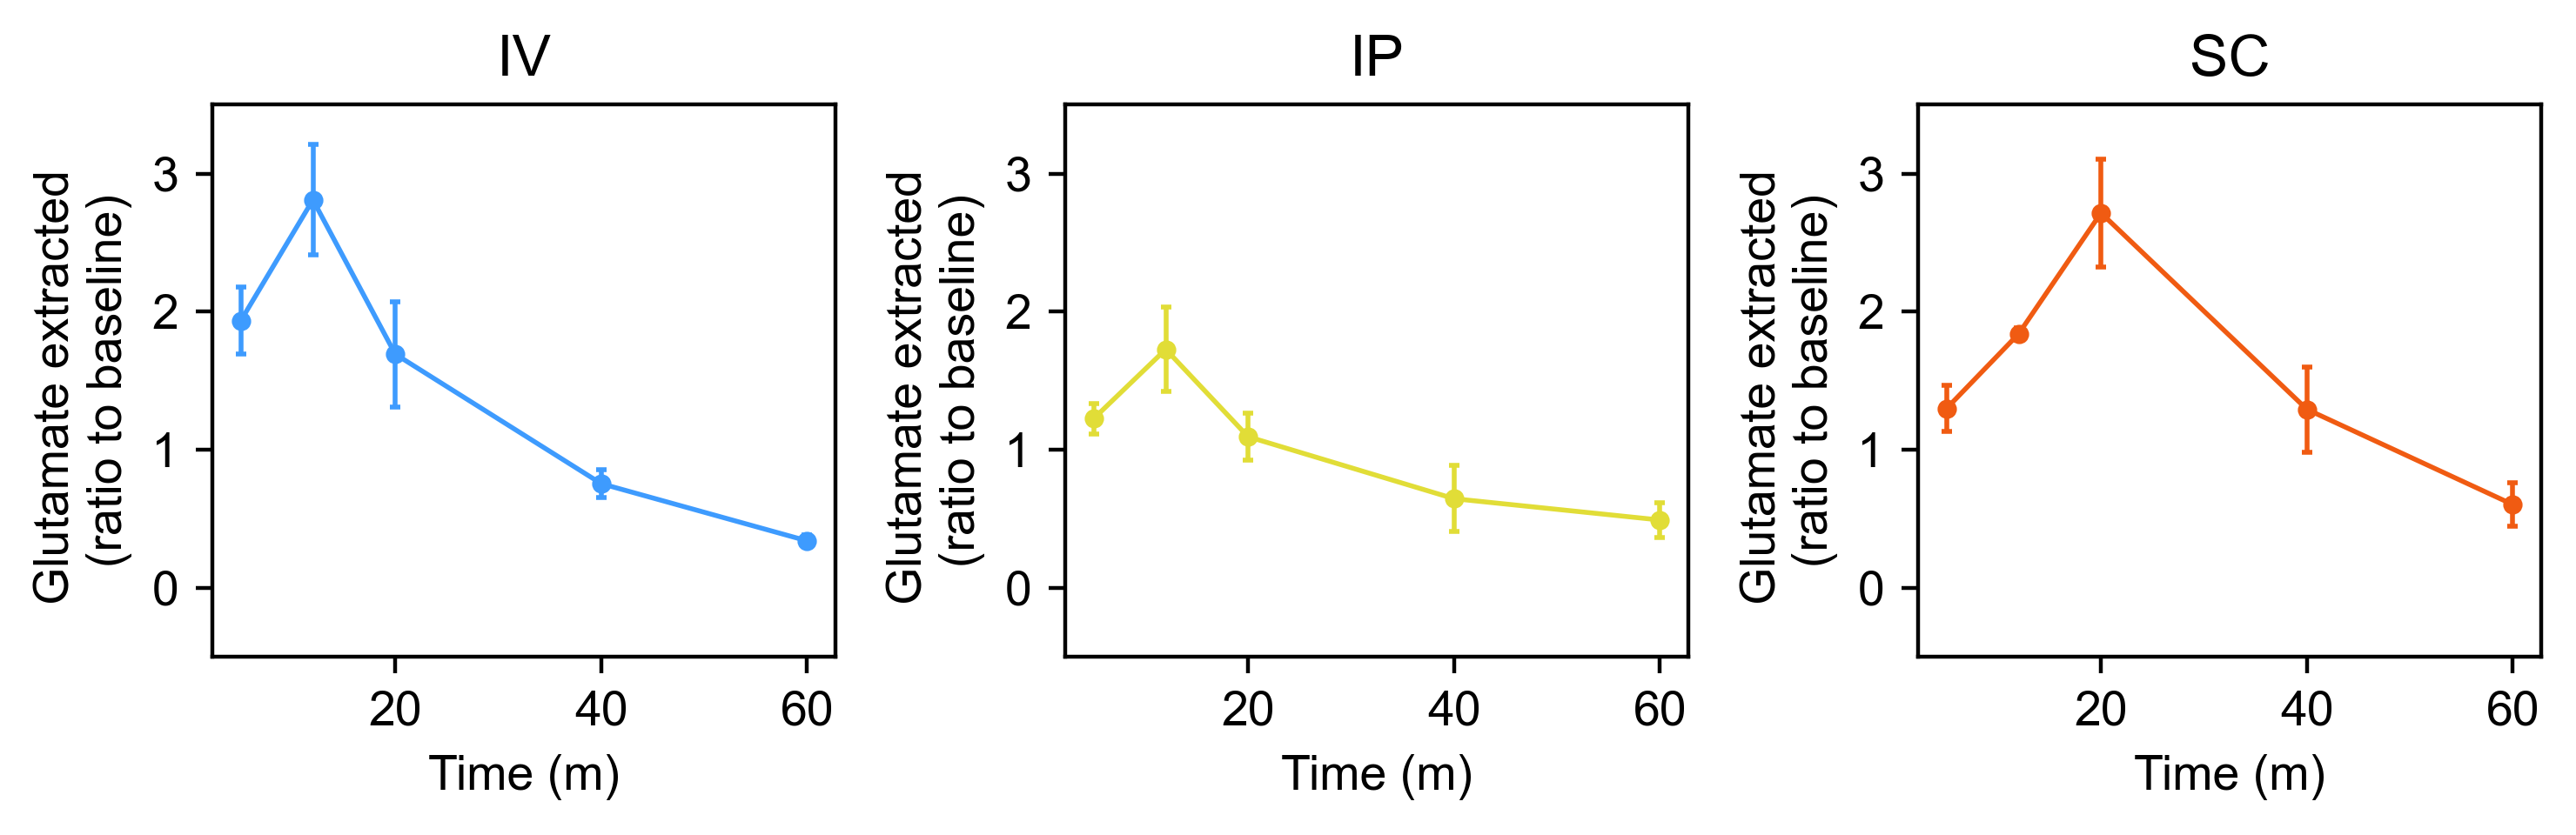

In [278]:
def load_pk(pk_path,drops=True):
    df = pd.read_csv(pk_path,index_col="Time")
    df = df.apply(pd.to_numeric, errors='coerce')
    if drops==True:
        # df.at[1.0,"R13"]=np.nan
        # df.at[1.0,"R3"]=np.nan
        # df.at[2.5,"R3"]=np.nan
        # df.at[5.0,"R3"]=np.nan
        # df.at[10.0,"R3"]=np.nan
        # df.at[20.0,"R3"]=np.nan
        # df.at[40.0,"R3"]=np.nan
        # df.at[60.0,"R3"]=np.nan
        #df.at[1.0,"R13"]=np.nan
        print("drop")
        #df.drop(index=62.0,inplace=True)
    return df

#Load the data
pk_path="/Users/snewbank/Documents/PhD/Data/25-03-16-glutamatebrainpk_ratios.csv"

IV=["R1","R3","R5","R7"]
IP=["R6","R8","R10","R12"]
SC=["R2","R4","R9","R11"]

cmap=plt.get_cmap("turbo")

drops_TF=True

groups={"IV" : IV, "IP" : IP, "SC" : SC}

drops_TF=True
df = load_pk(pk_path,drops=drops_TF)

#Making the 1-panel plot
plt.figure(figsize=(3,2),dpi=500)

df=df

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    plt.plot()
    plt.errorbar(df.index, m, yerr=std, color=colors[k],label=key,linewidth=0.5,capsize=1,markeredgewidth=0.5,markersize=2,marker="o")
    plt.xlabel('Time (m)')
    plt.ylabel('Glutamate extracted \n(ratio to baseline)')
    plt.legend()

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_glutamateratio.png",dpi=500)
    

# Making the 3-panel plot
fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

cmap=plt.get_cmap("turbo")
colors=[cmap([0.2]),cmap([0.6]),cmap([0.8])]

for k, key in enumerate(groups.keys()):
    if k>-1:
        sub_df=df[groups[key]]
        m=sub_df.mean(axis=1)
        std=sub_df.std(axis=1)
    ax[k].plot()
    ax[k].errorbar(df.index, m, yerr=std, color=colors[k],linewidth=1,capsize=1,markeredgewidth=1,markersize=3,marker="o")
    ax[k].set_xlabel('Time (m)')
    ax[k].set_ylabel('Glutamate extracted \n(ratio to baseline)')
    ax[k].set_title(key)
    ax[k].set_ylim([-0.5,3.5])

plt.tight_layout()

if save==True:
    plt.savefig(save_path+"pk_no_fit_panel_glutamateratio.png",dpi=500)

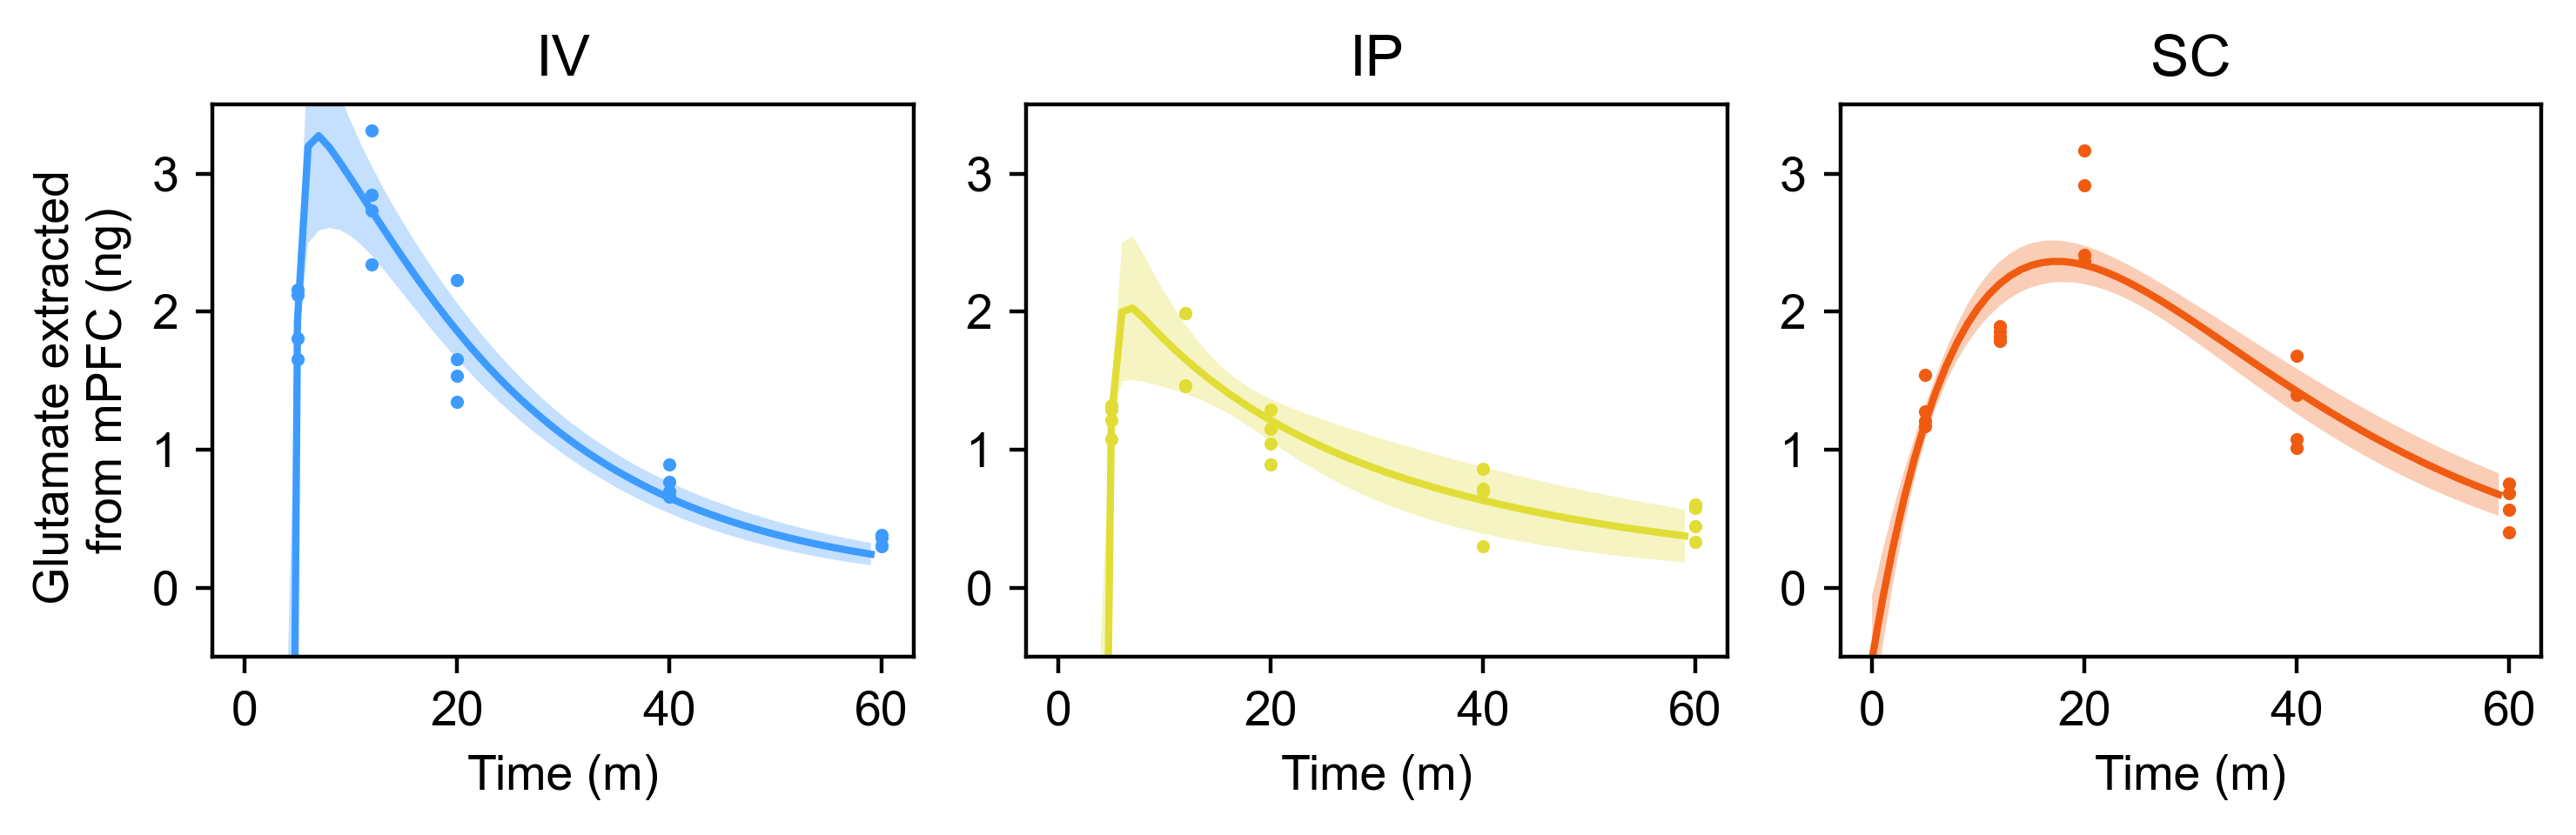

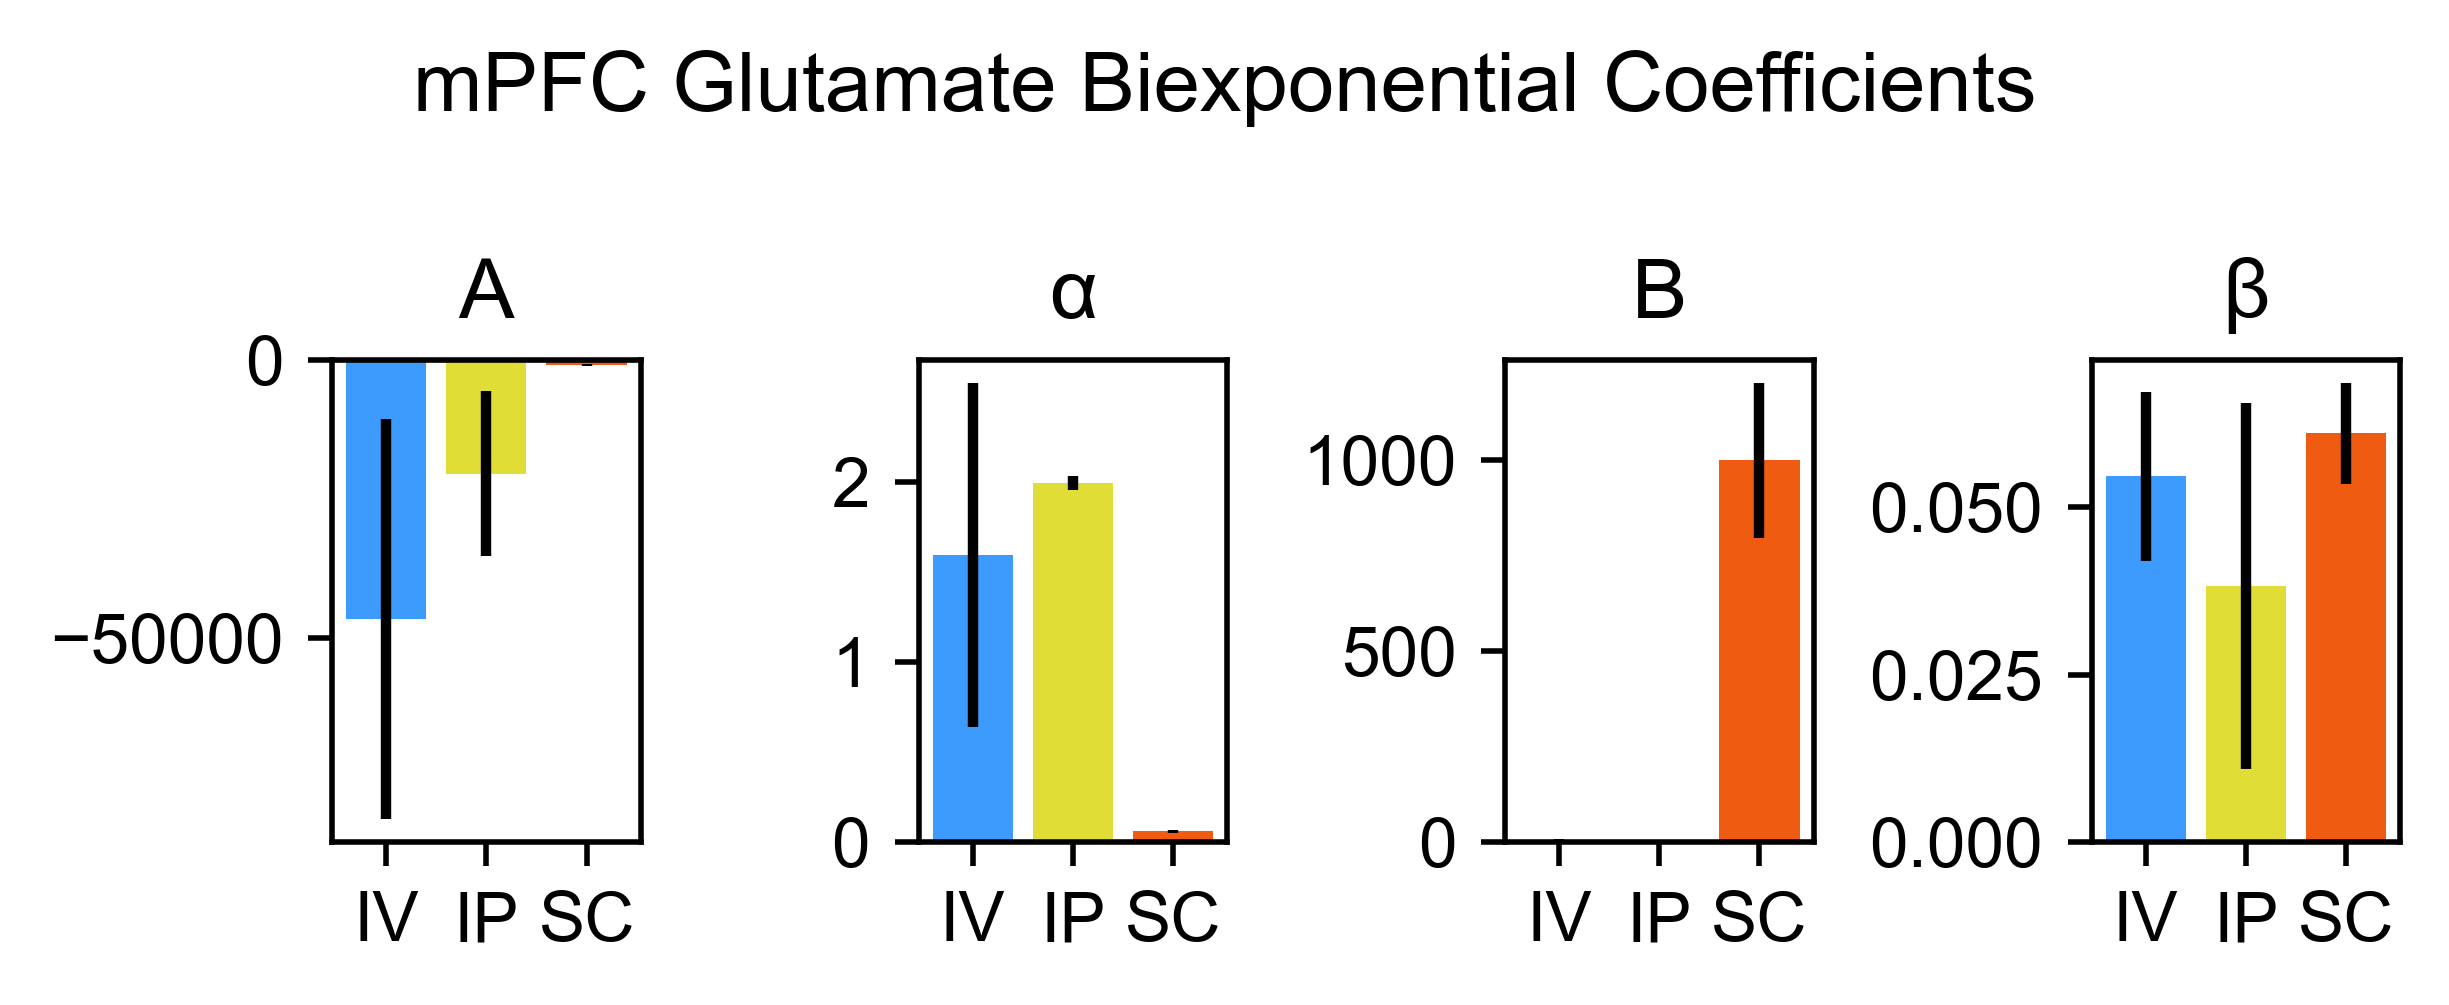

In [279]:
def biexponential(t, a, alpha, b, beta):
    return a * np.exp(-alpha * t) + b * np.exp(-beta * t)

def slope(point1, point2):
    return ((point1[1] - point2[1]) / (point1[0] - point2[0]))

def fit_to_biexponential(t,c):
    # Set initial "guess"
    p0=np.zeros(4)
    p0[0]=-10*slope([t[0],c[0]],[t[1],c[1]])
    p0[2]=-10*slope([t[np.argmax(c)],c[np.argmax(c)]],[t[-1],c[-1]])
    if np.argmax(c)!=0:
        p0[1] = 0.693/((t[np.argmax(c)]-t[0])/2)
    p0[3] = 0.693/((t[-1]-t[-2])/2)
    
    # Set bounds
    t0_to_peak=t[np.argmax(c)]
    peak_to_tlast=t[-1]-t[np.argmax(c)]
    
    bounds = ([-np.inf,0,-np.inf,0], [np.inf,t0_to_peak,np.inf,peak_to_tlast])
    
    for p,param in enumerate(p0):
        if param<bounds[0][p]:
            p0[p]=bounds[0][p]
        if param>bounds[1][p]:
            p0[p]=bounds[1][p]
    
    fit = optimize.curve_fit(biexponential, t, c, p0=p0, bounds=bounds, maxfev=10000)
    
    return fit

plot_types = ["mean_params","mean_fits"]
plot_type = plot_types[1]

groups={"IV" : IV, "IP" : IP, "SC" : SC}

cmap=plt.get_cmap("turbo")
colors={"IV": cmap([0.2]),"IP": cmap([0.6]),"SC": cmap([0.8])}

fig, ax = plt.subplots(1,3,figsize=(7.5,2.5),dpi=400)

all_fits=[]
for g, group in enumerate(groups.keys()):
    fits=[]
    subj=[]
    for i in range(len(df[groups[group]].columns)):
        data_i = df[groups[group]][df[groups[group]].columns[i]].dropna()
        if len(data_i)==0:
            continue
        subj.append(group+"_"+df[groups[group]].columns[i])
        t = data_i.index
        c = data_i.to_numpy()
        ax[g].scatter(t,c,color=colors[group],s=3)
        
        fit = fit_to_biexponential(t,c)
        fits.append(fit[0])
    
    if plot_type=="mean_params":
        fits=np.array(fits)
        mean_fit = np.mean(fits,axis=0)
        sd_fit = np.std(fits,axis=0)
        t=np.arange(0,60,1)
        c_fit_mean=biexponential(t,*mean_fit)
        hi_fit_mean=biexponential(t,*(mean_fit+sd_fit))
        lo_fit_mean=biexponential(t,*(mean_fit-sd_fit))
        ax[g].plot(t,c_fit_mean,color=colors[group])
        ax[g].fill_between(t,lo_fit_mean,hi_fit_mean,color=colors[group],alpha=0.3,edgecolor="none")
    elif plot_type=="mean_fits":
        t=np.arange(0,60,1)
        fit_curves=[]
        for fit in fits:
            fit_curves.append(biexponential(t,*fit))
        mean_fit = np.mean(np.array(fit_curves),axis=0)
        sd_fit = np.std(np.array(fit_curves),axis=0)
        ax[g].plot(t,mean_fit,color=colors[group])
        ax[g].fill_between(t,mean_fit-sd_fit,mean_fit+sd_fit,color=colors[group],alpha=0.3,edgecolor="none")
        fits=np.array(fits)
    ax[g].set_ylim([-0.5,3.5])
    ax[g].set_title(group)
    ax[g].set_xlabel("Time (m)")
    ax[0].set_ylabel('Glutamate extracted \nfrom mPFC (ng)')
    
    all_fits.append(pd.DataFrame({"A":fits[:,0],"α":fits[:,1],"B":fits[:,2],"β":fits[:,3]},index=subj))
plt.tight_layout()
fit_df = pd.concat(all_fits)
if save==True:
    plt.savefig(save_path+"roa_pk_glu_brain_fits.png",dpi=500)

fig, ax = plt.subplots(1,4,figsize=(5,2),dpi=500)

ticks=[]
labels=[]

for g, group in enumerate(groups.keys()):
    inds=[i for i in fit_df.index if i.startswith(group)]
    sub_df=fit_df.loc[inds]
    ticks.append(g)
    labels.append(group)
    for c,coeff in enumerate(fit_df.columns):
        mean=sub_df[coeff].mean()
        std=sub_df[coeff].std()
        ax[c].bar(x=g,height=mean,color=colors[group])
        ax[c].errorbar(g,mean,yerr=std,color="black")
        ax[c].set_title(coeff)

for c in range(len(fit_df.columns)):
    ax[c].set_xticks(ticks)
    ax[c].set_xticklabels(labels)
    ax[c].axhline(0,color="black",linewidth=0.5)
plt.suptitle("mPFC Glutamate Biexponential Coefficients")
plt.tight_layout()
if save==True:
    plt.savefig(save_path+"roa_pk_glu_brain_fit_params.png",dpi=500)

In [65]:
module_usage = analysis.get_module_usage(config, labels_df)
module_transitions = analysis.get_module_transitions(config, labels_df)
module_usage_scaled = module_usage.scale()
module_transitions_scaled = module_transitions.scale()

Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out
Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out
Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out


/Users/snewbank/PycharmProjects/MARIPoSA/utils/plot.py:286: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(figW, figH))


Warning - embedding (embedding=lda) without hold_out
Warning - embedding (embedding=pca) without hold_out


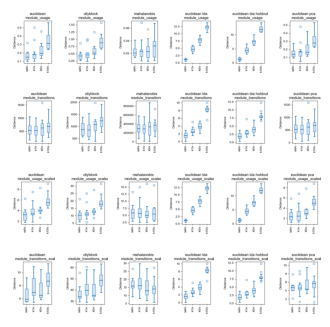

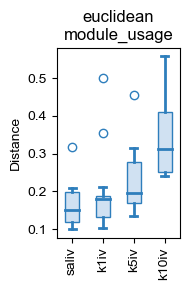

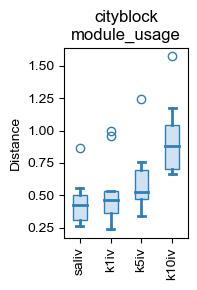

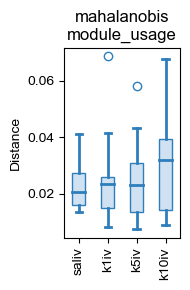

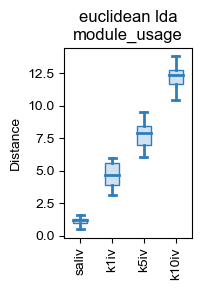

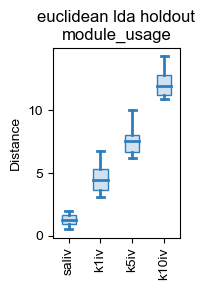

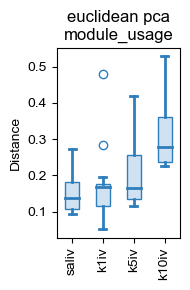

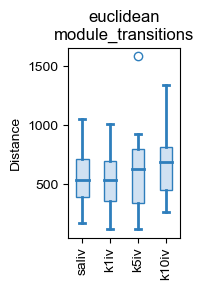

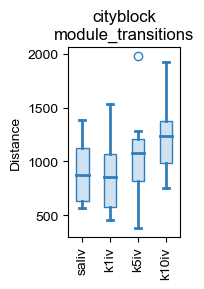

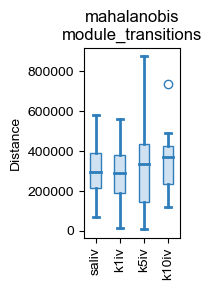

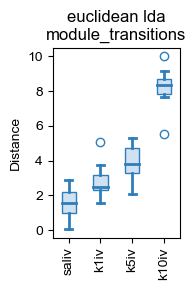

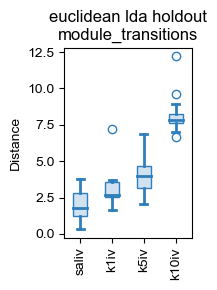

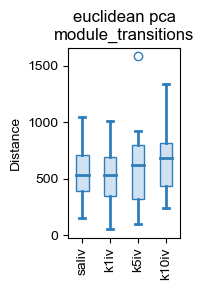

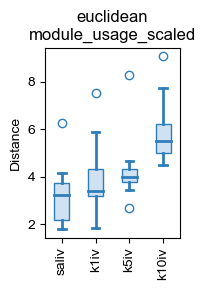

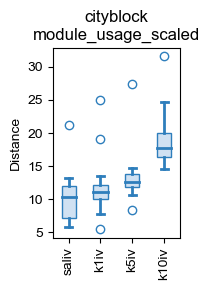

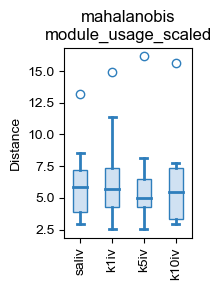

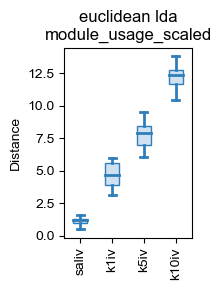

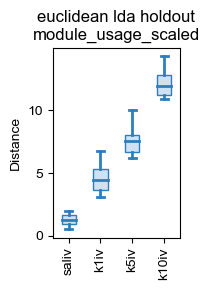

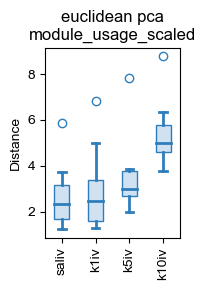

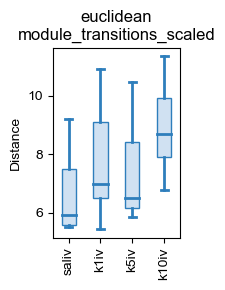

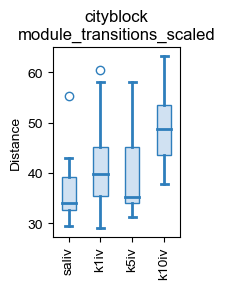

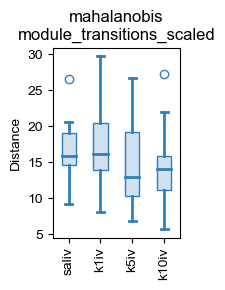

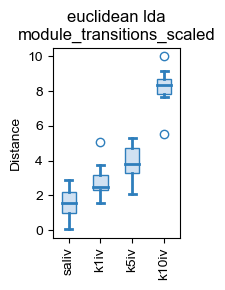

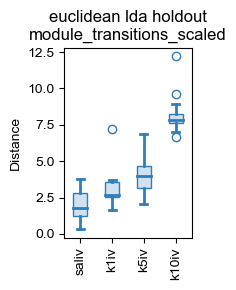

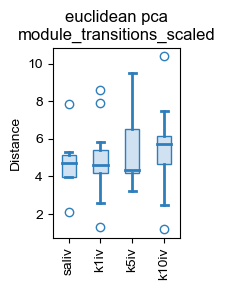

In [66]:
metrics={"module_usage":module_usage,
         "module_transitions":module_transitions,
         "module_usage_scaled":module_usage_scaled,
         "module_transitions_scaled":module_transitions_scaled}

fig_main, main_axes = plt.subplots(len(list(metrics.keys())), 6, figsize=(4, 4))

figW=2
figH=3
for m,metric in enumerate(list(metrics.keys())):
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean\n"+metric,figW=figW,figH=figH)
    im1 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="cityblock",method="centroid")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="cityblock\n"+metric,figW=figW,figH=figH)
    im2 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="mahalanobis",method="centroid")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="mahalanobis\n"+metric,figW=figW,figH=figH)
    im3 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid",embedding="lda")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean lda\n"+metric,figW=figW,figH=figH)
    im4 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid",embedding="lda",hold_out=True)
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean lda holdout\n"+metric,figW=figW,figH=figH)
    im5 = plot.fig_to_array(fig)
    distance_results = analysis.get_distance(metrics[metric],metric="euclidean",method="centroid",embedding="pca")
    fig = plot.plot_distance_results(metrics[metric], distance_results,title="euclidean pca\n"+metric,figW=figW,figH=figH)
    im6 = plot.fig_to_array(fig)
    main_axes[m,0].imshow(im1)
    main_axes[m,1].imshow(im2)
    main_axes[m,2].imshow(im3)
    main_axes[m,3].imshow(im4)
    main_axes[m,4].imshow(im5)
    main_axes[m,5].imshow(im6)
    for n in range(6):
        main_axes[m,n].axis('off')

fig_main.savefig("/Users/snewbank/Desktop/grpmtg/distance.png",dpi=500)

# Drugs

In [162]:
drug_config_path="/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS_drugs.yaml"

#Load config
drug_config = metadata.load_project(drug_config_path)

In [163]:
drug_config["subgroups"].keys()

dict_keys(['saliv', 'k1iv', 'k5iv', 'k10iv', 'k10ip', 'k10sc', 'cocaine', 'mk801', 'nalket', 'halket', 'k5ip', 'k1ip', 'salip', 'k25ip'])

In [33]:
method_acc = {}
method_cmat = {}

subgroups=['k10ip', 'nalket', 'halket', 'k25ip', 'mk801', 'cocaine']
labels_df = analysis.get_module_labels(drug_config, 0, 1200, subgroups = subgroups)
module_usage = analysis.get_module_usage(config, labels_df,binsize=300)
module_usage = module_usage.scale()
module_transitions = analysis.get_module_transitions(config, labels_df)
module_transitions = module_transitions.scale()

for method in ["LogisticRegression","LDA","MLP","NaiveBayes","KNN","RandomForest"]:
    method_acc[method+" usage"], method_cmat[method+" usage"] = analysis.loocv(module_usage,method=method)
    clf = analysis.classify(module_usage,method=method)
    method_acc[method+" tx"], method_cmat[method+" tx"] = analysis.loocv(module_transitions,method=method)
    clf = analysis.classify(module_transitions,method=method)

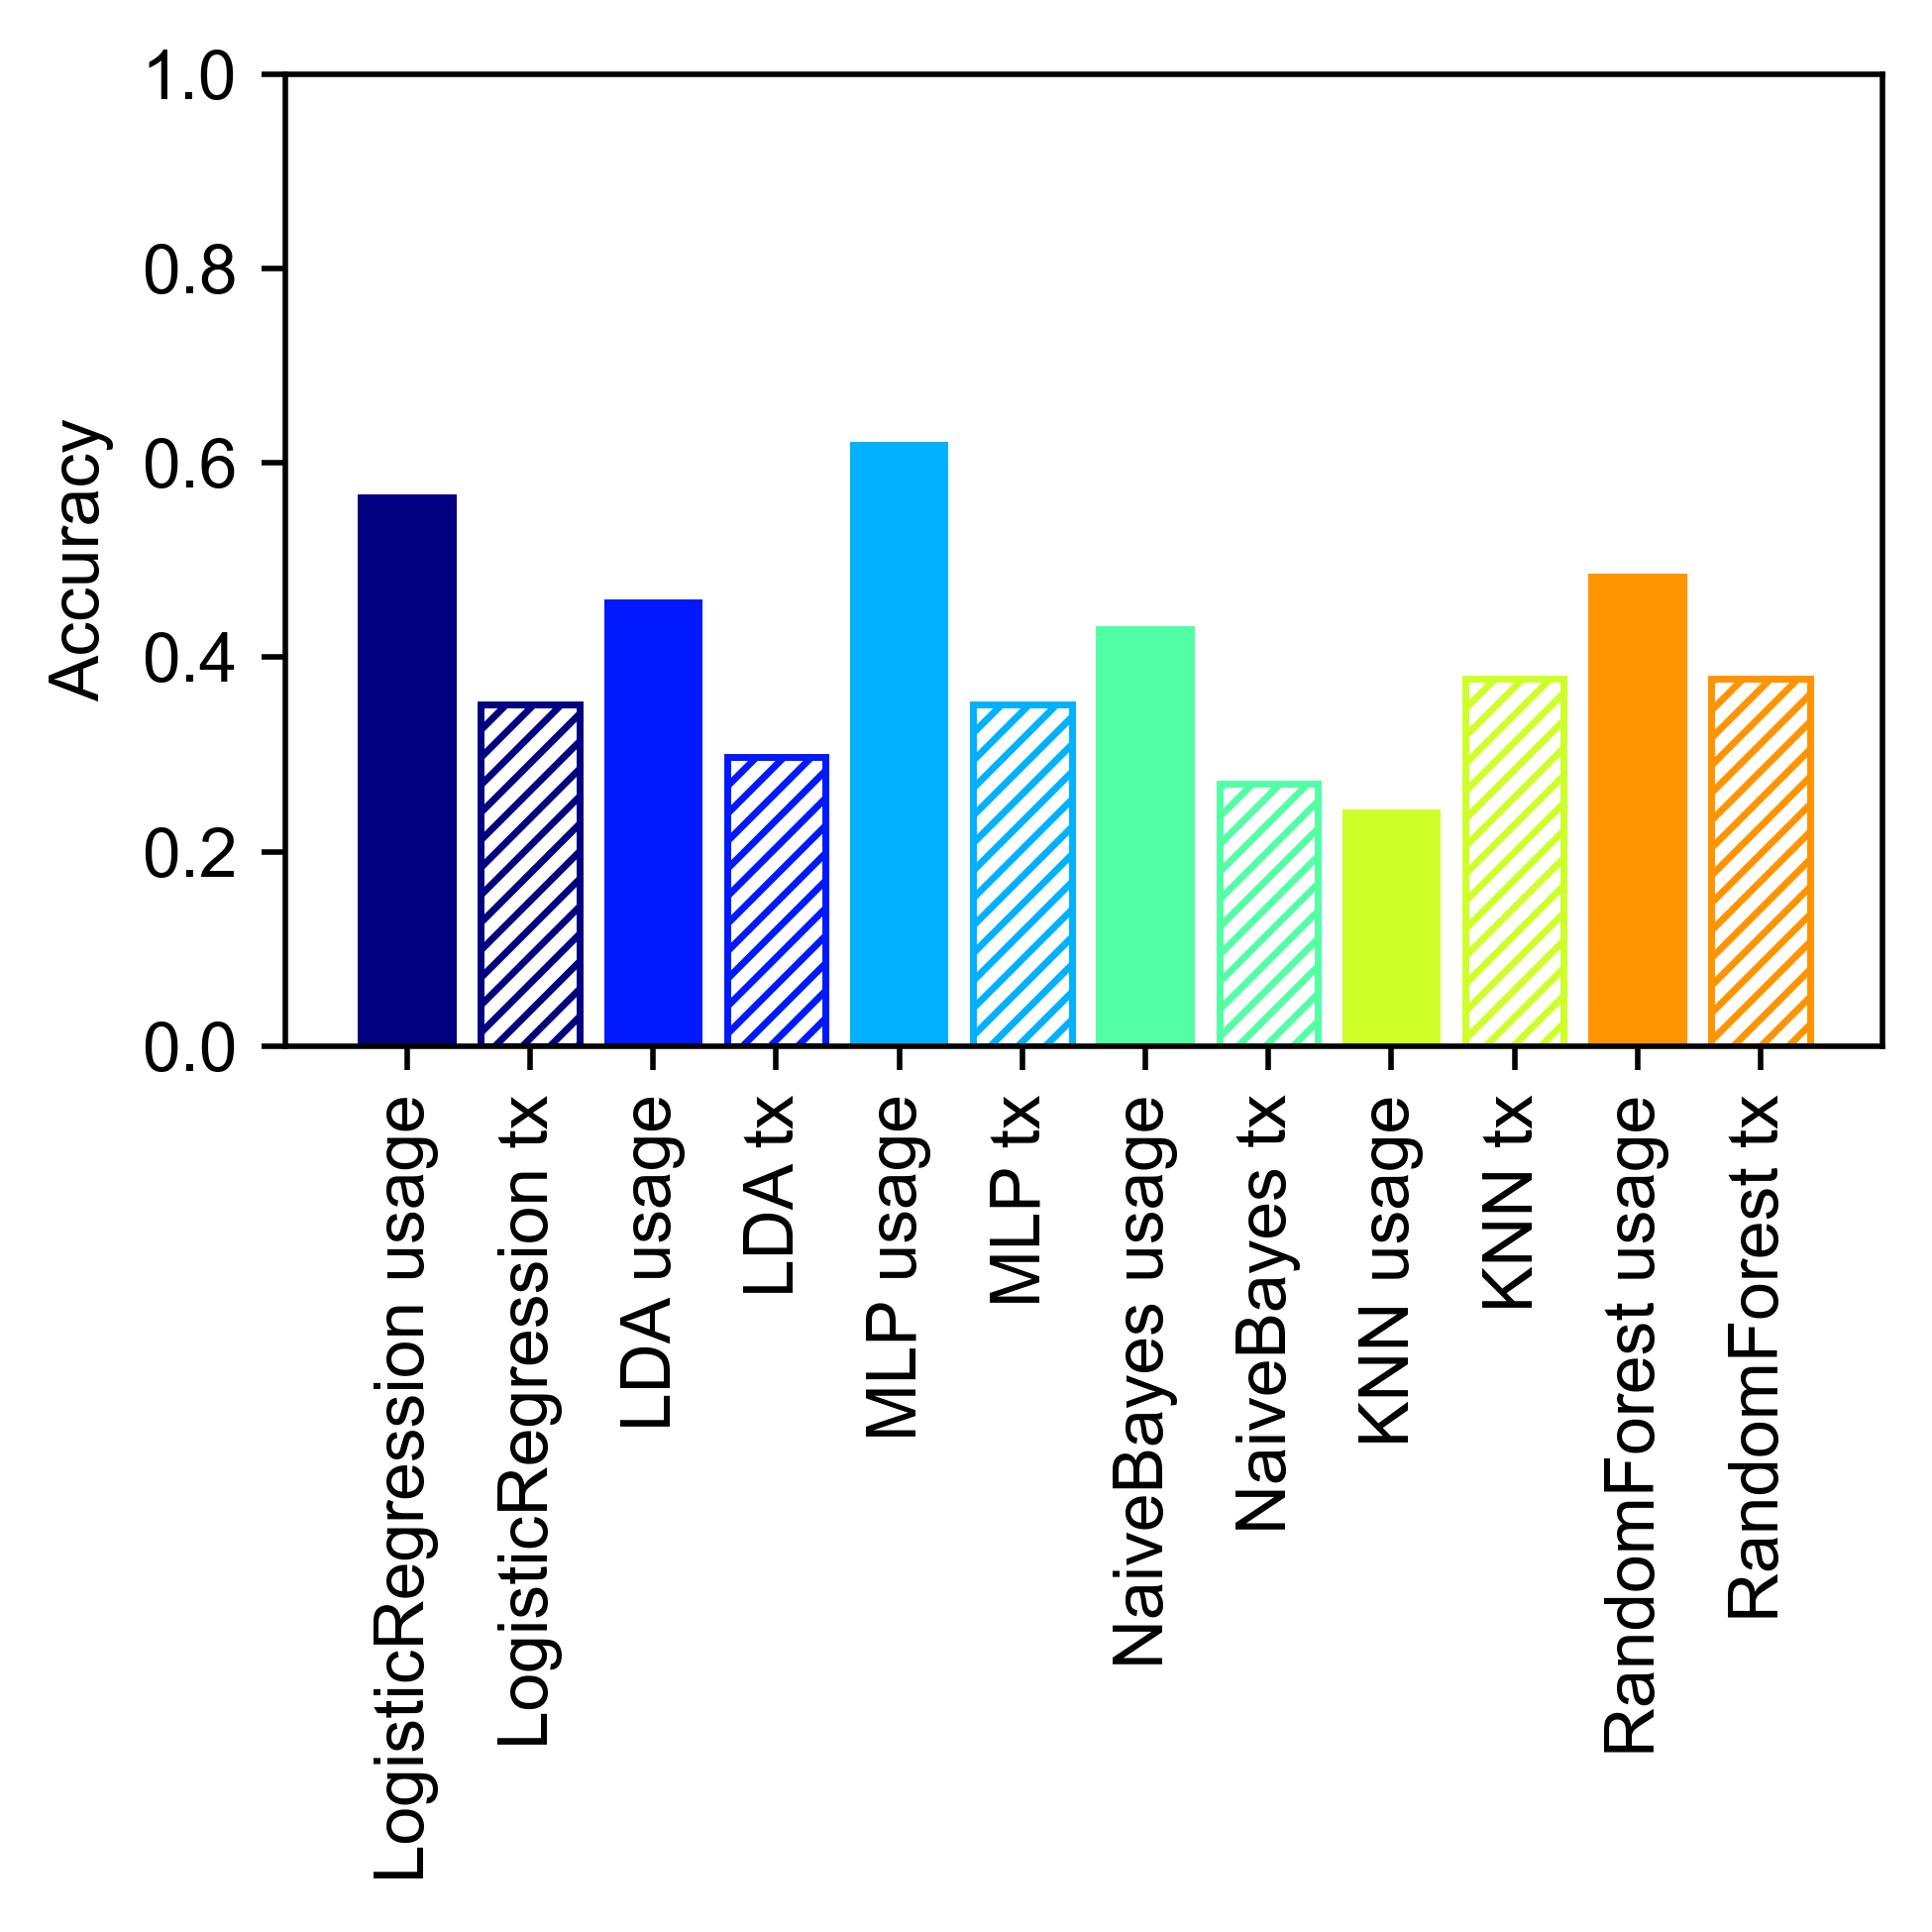

In [34]:
xticks=[]
xticklabels=[]
jet = plt.get_cmap("jet")
colors=[jet([i]) for i in np.arange(0,1,0.15)]
plt.figure(figsize=(4,4),dpi=500)
for k,key in enumerate(list(method_acc.keys())):
    if " usage" in key:
        alpha=0.5
        plt.bar(k,method_acc[key],color=colors[int(np.trunc(k/2))])
    else:
        plt.bar(k,method_acc[key],edgecolor=colors[int(np.trunc(k/2))],color="none",hatch="//////")
    xticks.append(k)
    xticklabels.append(key)
plt.xticks(xticks,labels=xticklabels,rotation=90)
plt.ylabel("Accuracy")
plt.ylim([0,1])
plt.tight_layout()
if save:
    plt.savefig(save_path+"drugs_clf.png")

In [35]:
list(module_usage.group_dict.keys())

['k10ip', 'nalket', 'halket', 'k25ip', 'mk801', 'cocaine']

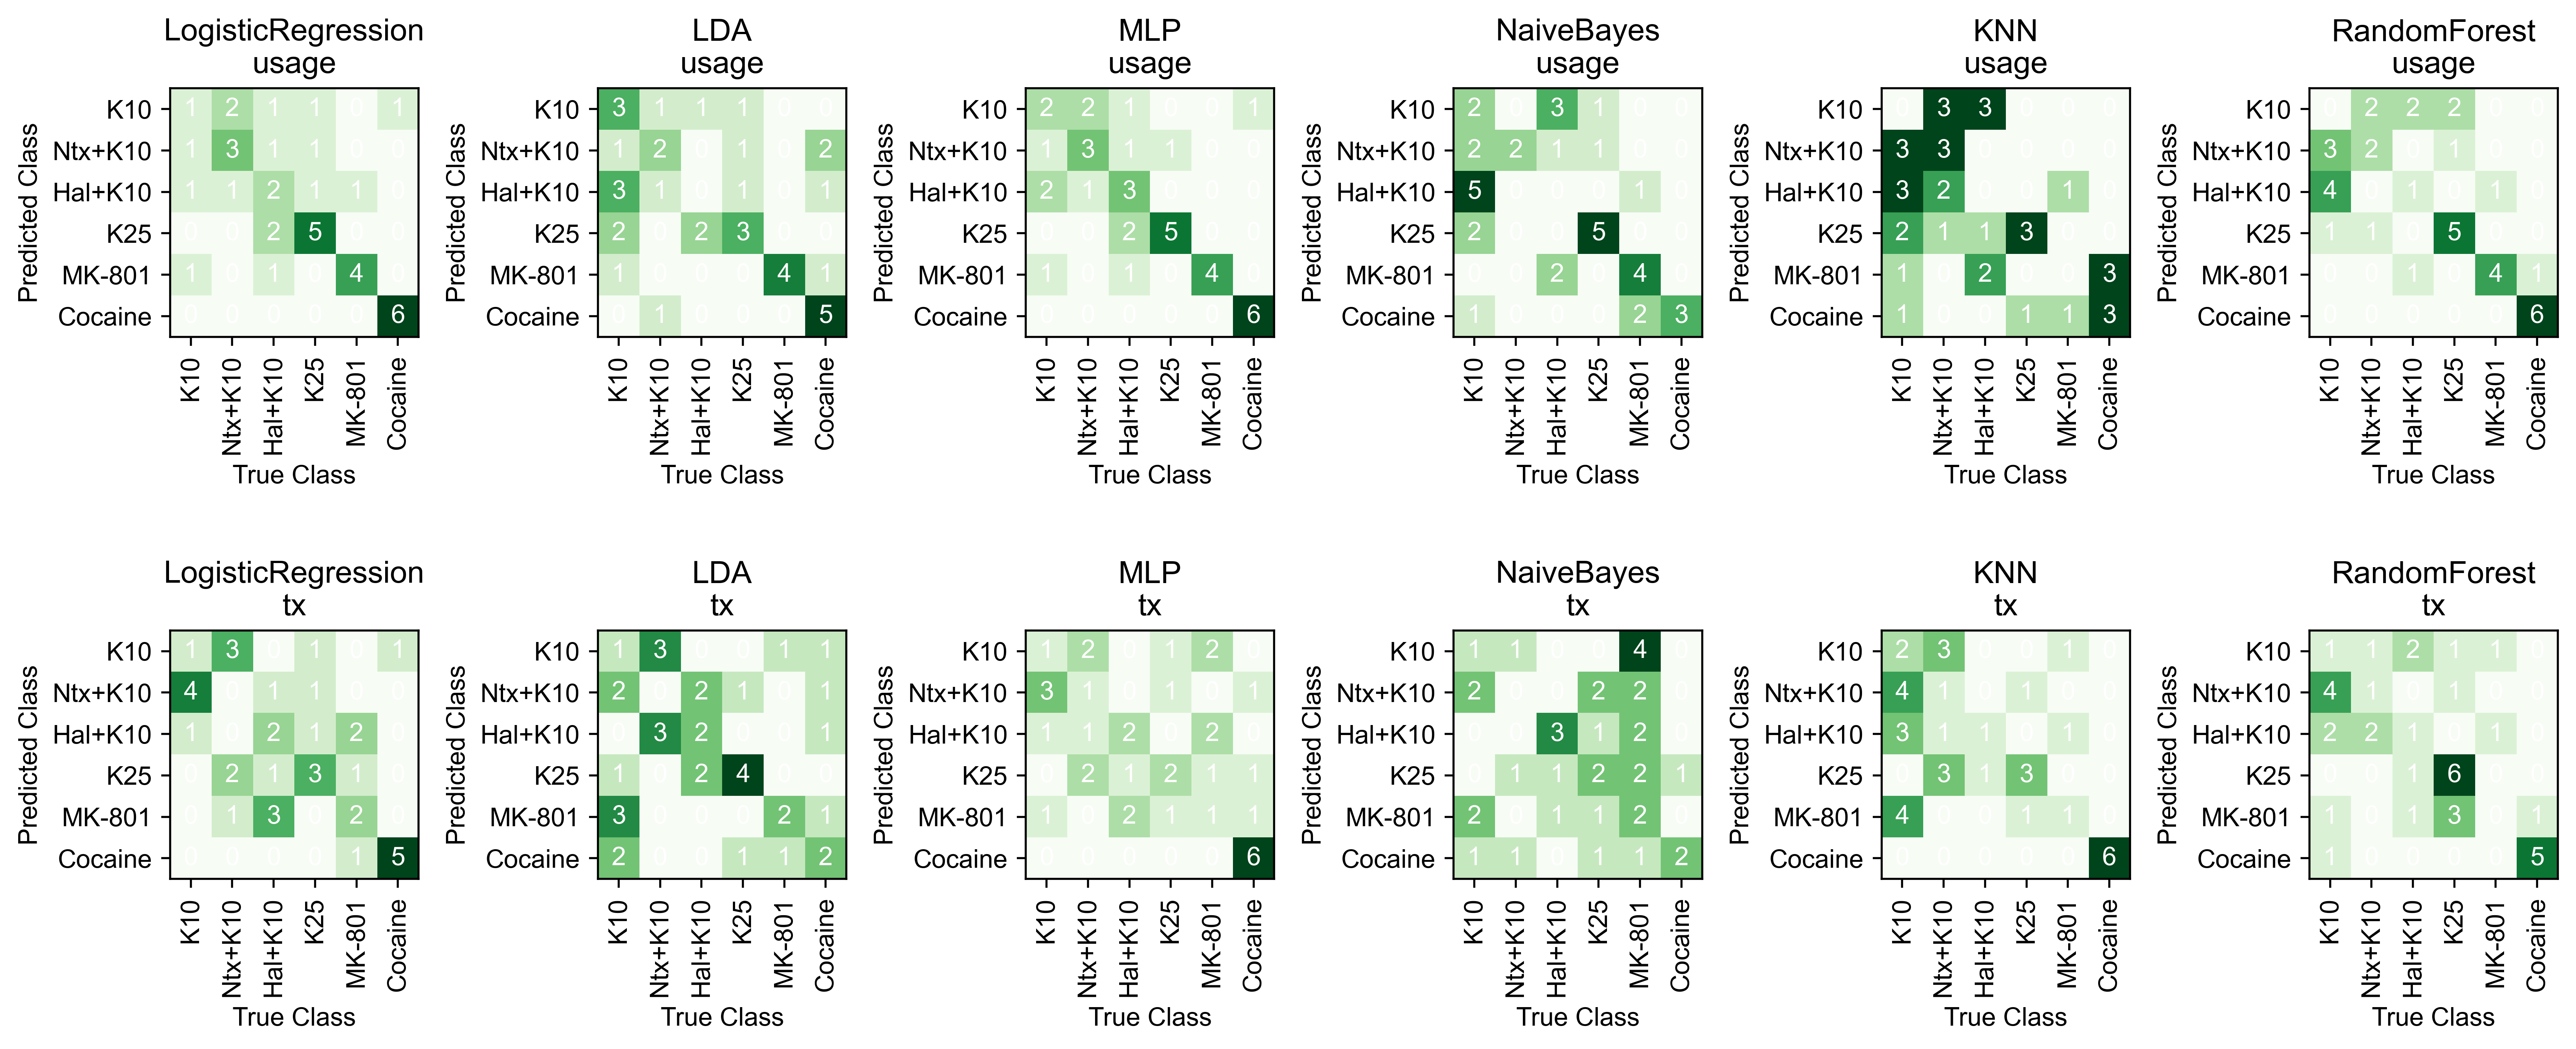

In [48]:
xticks=[]
xticklabels=[]
subgroups=['k10ip', 'nalket', 'halket', 'k25ip', 'mk801', 'cocaine']
alt_labels= {'k10ip':'K10', 'nalket':'Ntx+K10', 'halket':'Hal+K10', 'k25ip':'K25', 'mk801':'MK-801', 'cocaine':'Cocaine'}

fig, ax = plt.subplots(2,6,figsize=(14,6),dpi=500)


for k,key in enumerate(list(method_acc.keys())):
    ax[int(k%2),int(k/2)].imshow(method_cmat[key],cmap="Greens")
    for i in range(method_cmat[key].shape[0]):
        for j in range(method_cmat[key].shape[1]):
            text = ax[int(k%2),int(k/2)].text(j, i, f"{int(method_cmat[key][i, j])}",
                           ha="center", va="center", color="white")
    ax[int(k%2),int(k/2)].set_xticks([i[1] for i in list(module_usage.group_dict.items())],
                                     [alt_labels[i] for i in list(module_usage.group_dict.keys())],rotation=90)
    ax[int(k%2),int(k/2)].set_yticks([i[1] for i in list(module_usage.group_dict.items())],
                                     [alt_labels[i] for i in list(module_usage.group_dict.keys())])
    ax[int(k%2),int(k/2)].set_title("\n".join(key.split(" ")))
    ax[int(k%2),int(k/2)].set_xlabel("True Class")
    ax[int(k%2),int(k/2)].set_ylabel("Predicted Class")
plt.tight_layout()
if save:
    plt.savefig(save_path+"drugs_confmat.png")

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_coc']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalket']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5iv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25']
done with ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25']
done with ['BINARY_bf01_k5.csv', '2023-06-20_16-46-29_bf01_k5']
done with ['BINARY_2023-12-27_14-40-30_bf15_d16.csv', '2023-12-27_14-40-30_bf15_d16']
VAME modules map onto scored behaviors with 'loss' of 0.4585485775567791
Applying 15 remapping rules from config.
1 of 15: Remapping [0] to explore
2 of 

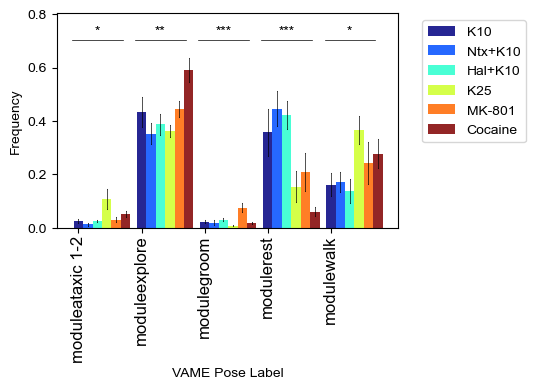

In [171]:
subgroups=['k10ip', 'nalket', 'halket', 'k25ip', 'mk801', 'cocaine']
labels_df = analysis.get_module_labels(drug_config, 0, 1200, subgroups = subgroups)
module_usage = analysis.get_module_usage(drug_config, labels_df)
BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(config)
labels_df = analysis.make_remappings_from_BORIS(config,labels_df = labels_df, BORIS_to_pose_mat=BORIS_to_pose_mat)
module_usage = analysis.get_module_usage(drug_config, labels_df)
#plot.module_usage_sandplot(config, module_usage, BORIS_to_pose_mat = BORIS_to_pose_mat_normalized, convolve=True, long_legend=True)

alt_labels= {'k10ip':'K10', 'nalket':'Ntx+K10', 'halket':'Hal+K10', 'k25ip':'K25', 'mk801':'MK-801', 'cocaine':'Cocaine'}
plot.plot_module_usage(drug_config,module_usage,figW=5.5,figH=4,BORIS_to_pose_mat=BORIS_to_pose_mat_normalized,style="bar_error",plot_stats=True,alt_labels=alt_labels)
if save:
    plt.savefig(save_path+"drugs_usagebar.png",dpi=500)

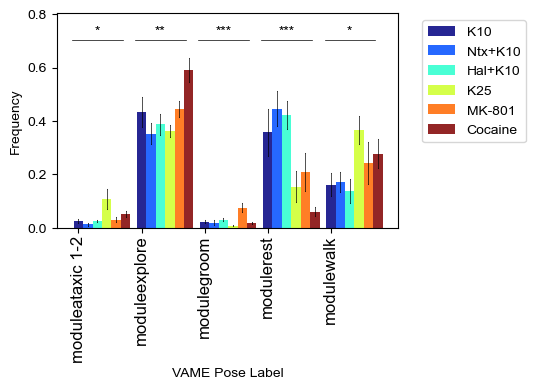

In [167]:
alt_labels= {'k10ip':'K10', 'nalket':'Ntx+K10', 'halket':'Hal+K10', 'k25ip':'K25', 'mk801':'MK-801', 'cocaine':'Cocaine'}
plot.plot_module_usage(drug_config,module_usage,figW=5.5,figH=4,BORIS_to_pose_mat=BORIS_to_pose_mat_normalized,style="bar_error",plot_stats=True,alt_labels=alt_labels)
if save:
    plt.savefig(save_path+"drugs_usagebar.png",dpi=500)

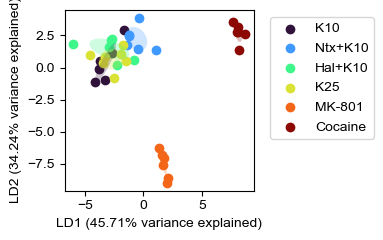

In [47]:
subgroups=['k10ip', 'nalket', 'halket', 'k25ip', 'mk801', 'cocaine']
alt_labels= {'k10ip':'K10', 'nalket':'Ntx+K10', 'halket':'Hal+K10', 'k25ip':'K25', 'mk801':'MK-801', 'cocaine':'Cocaine'}
labels_df = analysis.get_module_labels(drug_config, 0, 1200, subgroups = subgroups)
module_usage = analysis.get_module_usage(drug_config, labels_df,binsize=300)
emb = analysis.embed(module_usage,method="LDA",n_components=2)
fig = plot.plot_embeddings(module_usage, emb, figW=4, figH=2.5, cmap="turbo", alt_legend=alt_labels,legend=True,draw_ellipse=True)
if save:
    plt.savefig(save_path+"drugs_lda.png",dpi=500)

done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_coc']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalket']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5iv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25']
done with ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25']
done with ['BINARY_bf01_k5.csv', '2023-06-20_16-46-29_bf01_k5']
done with ['BINARY_2023-12-27_14-40-30_bf15_d16.csv', '2023-12-27_14-40-30_bf15_d16']
VAME modules map onto scored behaviors with 'loss' of 0.4585485775567791
done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_

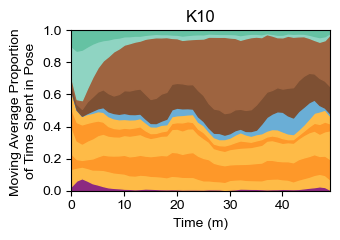

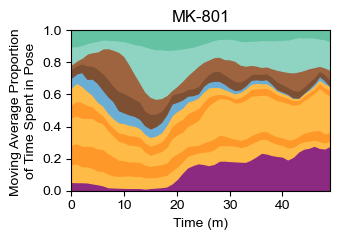

In [71]:
group_names = {"k10ip":"K10","mk801":"MK-801"}
for group in ["k10ip","mk801"]:
    labels_df = analysis.get_module_labels(drug_config,0,60*50,subgroups=[group])
    module_usage = analysis.get_module_usage(drug_config, labels_df,binsize=60)
    BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(drug_config)
    analysis.make_remappings_from_BORIS(drug_config,BORIS_to_pose_mat=BORIS_to_pose_mat)
    plot.module_usage_sandplot(drug_config, module_usage, BORIS_to_pose_mat = BORIS_to_pose_mat_normalized, figW=3.5, figH=2.5, convolve=True, long_legend=True,title=group_names[group])
    if save:
        plt.savefig(save_path+f"drug_sandplot_{group_names[group]}.png",dpi=800)

# Pain

In [323]:
pain_config_path="/Users/snewbank/Behavior/MARIPOSA_test/240904_VAME-full/config_PS_pain.yaml"

#Load config
pain_config = metadata.load_project(pain_config_path)

In [306]:
for key in pain_config["subgroups"].keys():
    if "baseline" in key:
        print(key)
        print(len(pain_config["subgroups"][key]))

baseline_all_sni
41
baseline_shamsal
6
baseline_sni_ketIP
10
baseline_sni_salIP
10
baseline_sni_salIV_FUS
6
baseline_sni_ketIV_FUS
7
baseline_sni_lipkIV_FUS
8


done with ['BINARY_2023-05-09_17-41-11_bf01_nal10k10.csv', '2023-05-09_17-41-11_bf01_nal10k10']
done with ['BINARY_13-39-15_bm01_k25.csv', '2023-05-30_13-39-15_bm01_k25']
done with ['BINARY_2024-05-09_13-38-52_bf33_d15.csv', '2024-05-09_13-38-52_bf33_d15']
done with ['BINARY_1_2023-05-31_12-02-23_bf02_coc.csv', '2023-05-31_12-02-23_bf02_coc']
done with ['BINARY_2023-06-15_19-15-24_bm04_nalket.csv', '2023-06-15_19-15-24_bm04_nalket']
done with ['BINARY_2023-06-15_17-16-18_bm01_k5iv.csv', '2023-06-15_17-16-18_bm01_k5iv']
done with ['BINARY_2023-06-09_18-18-49_bm02_k25.csv', '2023-06-09_18-18-49_bm02_k25']
done with ['BINARY_2023-07-08_15-13-11_bf03_k25.csv', '2023-07-08_15-13-11_bf03_k25']
done with ['BINARY_bf01_k5.csv', '2023-06-20_16-46-29_bf01_k5']
done with ['BINARY_2023-12-27_14-40-30_bf15_d16.csv', '2023-12-27_14-40-30_bf15_d16']
VAME modules map onto scored behaviors with 'loss' of 0.4585485775567791
[]
[]
[]
[]
[]
[]


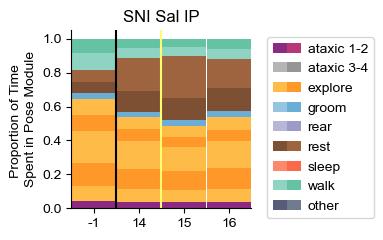

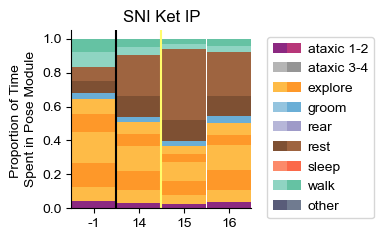

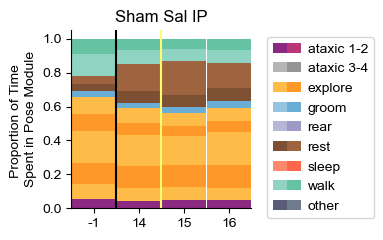

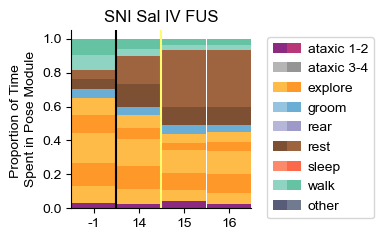

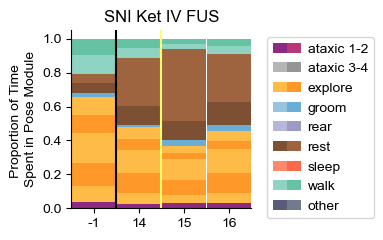

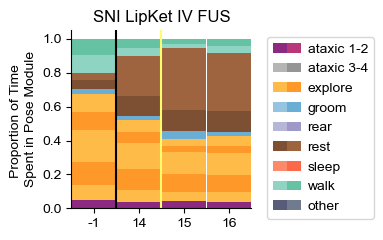

In [326]:
['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal', 
 'baseline_sni_ketIP', 'd1_sni_ketIP', 'd7_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP', 
 'baseline_sni_salIP', 'd1_sni_salIP', 'd7_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP', 
 'baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS', 'baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS', 'baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']

figW=4
figH=2.5
lines=True

BORIS_to_pose_mat, BORIS_to_pose_mat_normalized, loss = analysis.BORIS_to_pose(pain_config)
analysis.make_remappings_from_BORIS(pain_config,BORIS_to_pose_mat=BORIS_to_pose_mat)

groupname="SNI Sal IP"
#group=['baseline_sni_salIP', 'd1_sni_salIP', 'd7_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP']
group=['baseline_sni_salIP', 'd14_sni_salIP', 'd15_sni_salIP', 'd16_sni_salIP']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,14,15,16],long_legend=False)
if lines==True:
    plt.axvline(0.5,color="black")
    plt.axvline(1.5,color="#fffd6b")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)


groupname="SNI Ket IP"
#group=['baseline_sni_ketIP', 'd1_sni_ketIP', 'd7_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP']
group=['baseline_sni_ketIP', 'd14_sni_ketIP', 'd15_sni_ketIP', 'd16_sni_ketIP']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,14,15,16],long_legend=False)
if lines==True:
    plt.axvline(0.5,color="black")
    plt.axvline(1.5,color="#fffd6b")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)


groupname="Sham Sal IP"
#group=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal']
group=['baseline_shamsal', 'd14_shamsal', 'd15_shamsal', 'd16_shamsal']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,14,15,16],long_legend=False)
plt.axvline(0.5,color="black")
plt.axvline(1.5,color="#fffd6b")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)


groupname="SNI Sal IV FUS"
#group=['baseline_sni_salIV_FUS', 'd1_sni_salIV_FUS', 'd7_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS']
group=['baseline_sni_salIV_FUS', 'd14_sni_salIV_FUS', 'd15_sni_salIV_FUS', 'd16_sni_salIV_FUS']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,14,15,16],long_legend=False)
if lines==True:
    plt.axvline(0.5,color="black")
    plt.axvline(1.5,color="#fffd6b")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)


groupname="SNI Ket IV FUS"
#group=['baseline_sni_ketIV_FUS', 'd1_sni_ketIV_FUS', 'd7_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS']
group=['baseline_sni_ketIV_FUS', 'd14_sni_ketIV_FUS', 'd15_sni_ketIV_FUS', 'd16_sni_ketIV_FUS']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,14,15,16],long_legend=False)
if lines==True:
    plt.axvline(0.5,color="black")
    plt.axvline(1.5,color="#fffd6b")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)


groupname="SNI LipKet IV FUS"
#group=['baseline_sni_lipkIV_FUS', 'd1_sni_lipkIV_FUS', 'd7_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
group=['baseline_sni_lipkIV_FUS', 'd14_sni_lipkIV_FUS', 'd15_sni_lipkIV_FUS', 'd16_sni_lipkIV_FUS']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,14,15,16],long_legend=False)
if lines==True:
    plt.axvline(0.5,color="black")
    plt.axvline(1.5,color="#fffd6b")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)


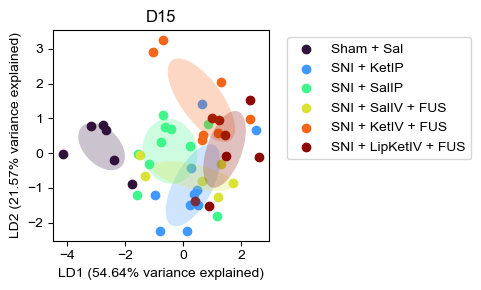

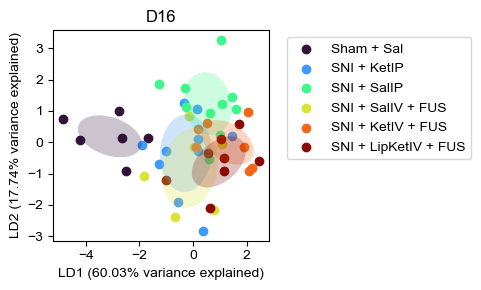

In [341]:
d15 = ['d15_shamsal','d15_sni_ketIP','d15_sni_salIP','d15_sni_salIV_FUS', 'd15_sni_ketIV_FUS','d15_sni_lipkIV_FUS']
d16 = ['d16_shamsal','d16_sni_ketIP','d16_sni_salIP','d16_sni_salIV_FUS', 'd16_sni_ketIV_FUS','d16_sni_lipkIV_FUS']
d15alt = {'d15_shamsal':'Sham + Sal',
          'd15_sni_ketIP':'SNI + KetIP',
          'd15_sni_salIP':'SNI + SalIP',
          'd15_sni_salIV_FUS':'SNI + SalIV + FUS', 
          'd15_sni_ketIV_FUS':'SNI + KetIV + FUS',
          'd15_sni_lipkIV_FUS':'SNI + LipKetIV + FUS'}
d16alt = {'d16_shamsal':'Sham + Sal',
          'd16_sni_ketIP':'SNI + KetIP',
          'd16_sni_salIP':'SNI + SalIP',
          'd16_sni_salIV_FUS':'SNI + SalIV + FUS', 
          'd16_sni_ketIV_FUS':'SNI + KetIV + FUS',
          'd16_sni_lipkIV_FUS':'SNI + LipKetIV + FUS'}
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = d15)
module_usage = analysis.get_module_usage(pain_config, labels_df)
emb = analysis.embed(module_usage,method="LDA",n_components=2)
fig = plot.plot_embeddings(module_usage, emb, figW=5, figH=3, cmap="turbo", title="D15",legend=True,alt_legend=d15alt,draw_ellipse=True)
if save:
    plt.savefig(save_path+"lda_d15.png",dpi=500)

labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = d16)
module_usage = analysis.get_module_usage(pain_config, labels_df)
emb = analysis.embed(module_usage,method="LDA",n_components=2)
fig = plot.plot_embeddings(module_usage, emb, figW=5, figH=3, cmap="turbo", title="D16",alt_legend=d16alt,legend=True,draw_ellipse=True)
if save:
    plt.savefig(save_path+"lda_d16.png",dpi=500)

[]
[]


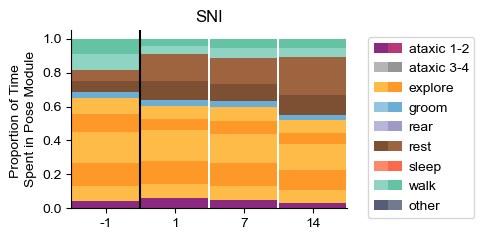

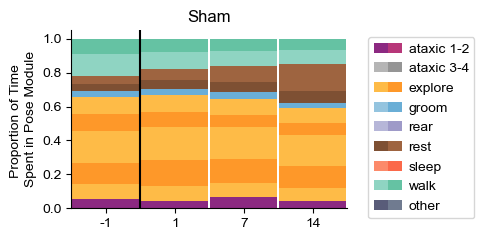

In [325]:
groupname="SNI"
group=['baseline_all_sni', 'd1_all_sni', 'd7_all_sni', 'd14_all_sni']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,1,7,14],long_legend=False)
if lines==True:
    plt.axvline(0.5,color="black")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)


groupname="Sham"
group=['baseline_shamsal', 'd1_shamsal', 'd7_shamsal', 'd14_shamsal']
labels_df = analysis.get_module_labels(pain_config, 0, 1200, subgroups = group)
module_usage = analysis.get_module_usage(pain_config, labels_df)
fig = plot.plot_module_usage(pain_config, module_usage,figW=figW,figH=figH,title=groupname,style="stacked",legend=True,BORIS_to_pose_mat=BORIS_to_pose_mat,alt_xticks=[-1,1,7,14],long_legend=False)
if lines==True:
    plt.axvline(0.5,color="black")
if save == True:
    plt.savefig(save_path+groupname+"_stacked_pose.png",transparent=True, dpi=500)

# Miscellaneous

l2 labels silhouette: 0.0007805100075060036
l2 transitions silhouette: -0.04006526757978038
l1 labels silhouette: 0.002557855039782353
l1 transitions silhouette: -0.05779584457504938
euclidean labels silhouette: 0.0007805100075060036
euclidean transitions silhouette: -0.04006526757978038
cityblock labels silhouette: 0.002557855039782353
cityblock transitions silhouette: -0.05779584457504938
mahalanobis labels silhouette: -0.03198403158371765
mahalanobis transitions ERROR
braycurtis labels silhouette: 0.06865800363317699
braycurtis transitions silhouette: -0.02301520896264466
chebyshev labels silhouette: -0.005466954704291698
chebyshev transitions silhouette: -0.05031079739692687
hamming labels silhouette: 0.0017094017094017033
hamming transitions silhouette: -0.029918505738907773


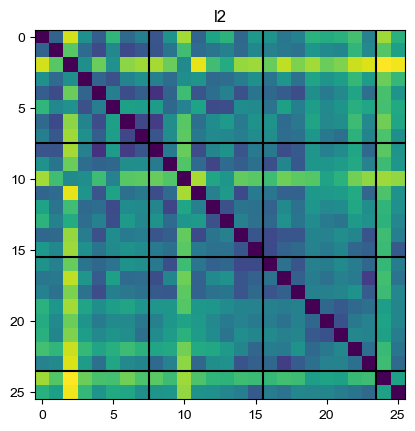

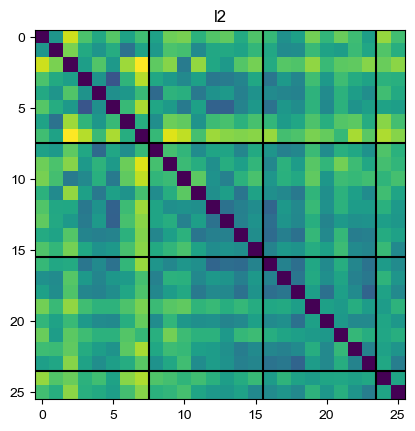

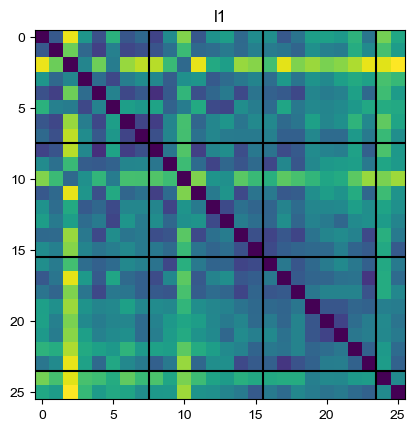

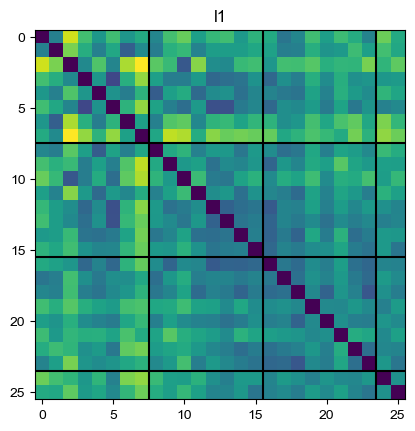

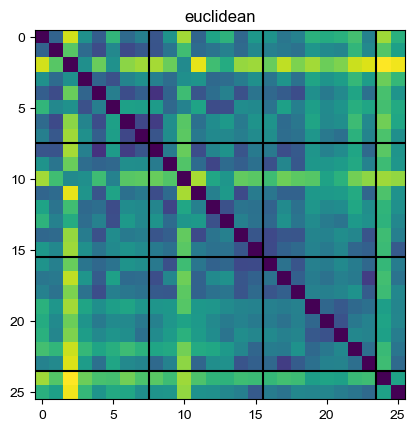

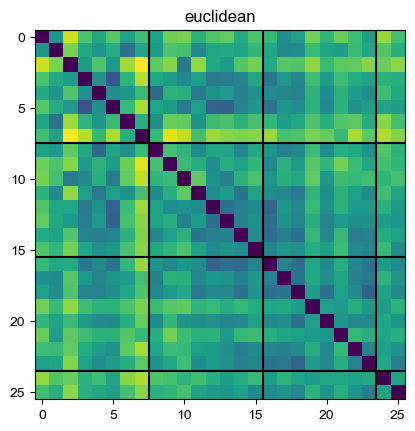

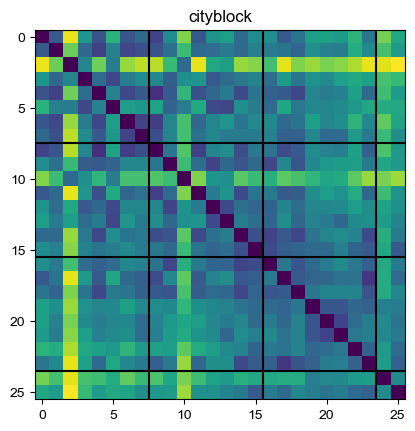

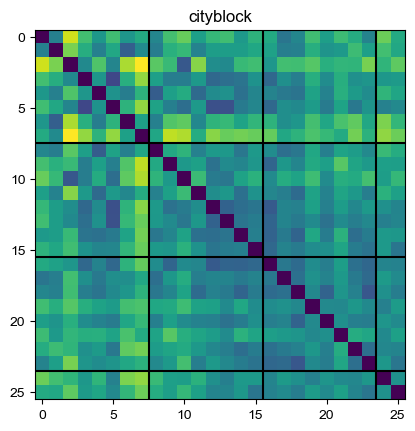

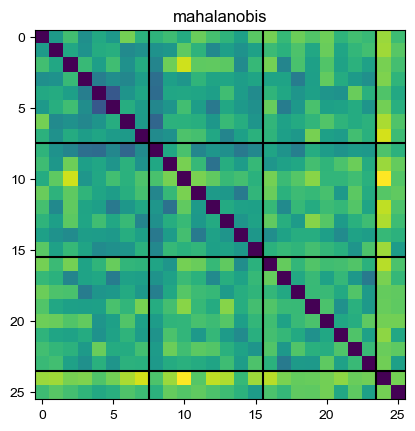

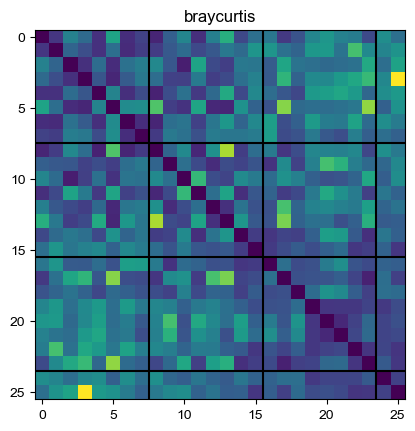

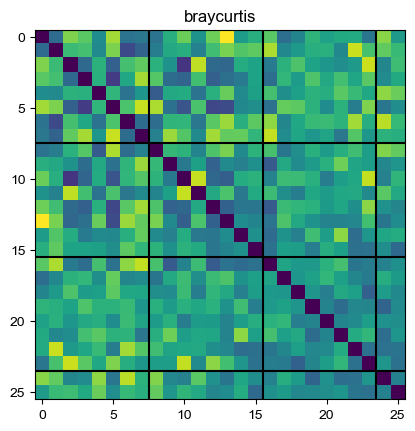

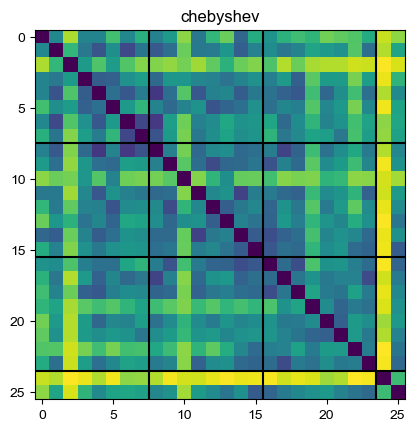

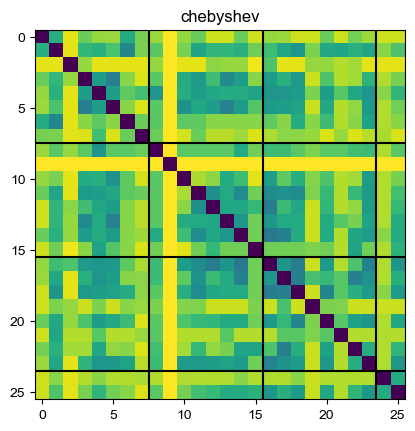

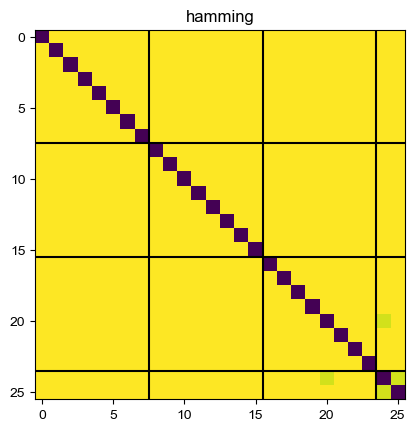

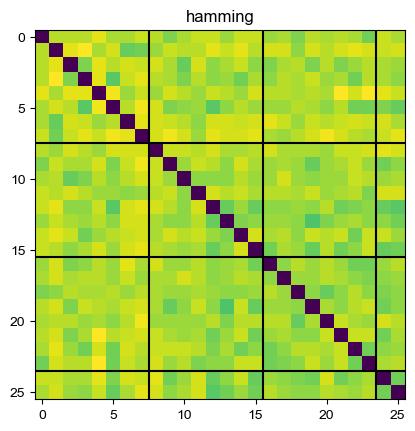

In [310]:

arr = np.array(module_usage.group_labels)
edges = np.where(arr[:-1] != arr[1:])[0]

for metric in ("l2","l1","euclidean","cityblock","mahalanobis","braycurtis","chebyshev","hamming"):
    #try:
    dist_mat = pairwise_distances(module_usage_scaled.label_counts,metric=metric)
    plt.figure()
    plt.imshow(dist_mat)
    for edge in edges:
        plt.axhline(edge+0.5,color="black")
        plt.axvline(edge+0.5,color="black")
    plt.title(metric)
    sc = silhouette_score(dist_mat,module_usage_scaled.group_labels,metric="precomputed")
    print(f'{metric} labels silhouette: {sc}')
    # except:
    #     print(f'{metric} labels ERROR')
    try:
        dist_mat = pairwise_distances(module_transitions_scaled.transition_counts,metric=metric)
        plt.figure()
        plt.imshow(dist_mat)
        for edge in edges:
            plt.axhline(edge+0.5,color="black")
            plt.axvline(edge+0.5,color="black")
        plt.title(metric)   
        sc = silhouette_score(dist_mat,module_transitions_scaled.group_labels,metric="precomputed")
        print(f'{metric} transitions silhouette: {sc}')
    except:
        print(f'{metric} transitions ERROR')

In [88]:
labels_array = np.array(module_usage.group_labels)
dist_arr = np.zeros([4,4])
for i in range(4):
    for j in range(4):
        dist_arr[i,j] = np.mean(dist_mat[labels_array==i,:][:,labels_array==j])

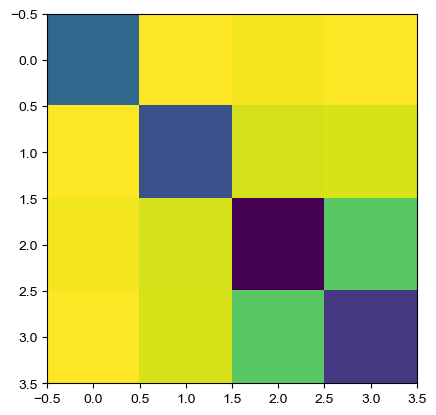

In [90]:
plt.imshow(dist_arr)